
>>> STARTING HYPERPARAMETER OPTIMIZATION FOR NVDA <<<
>>> OPTIMIZATION MODE: SMART GRID (Train once per Window, Backtest many) <<<

[Training Phase] Compiling Agents for Window Size: 40...
Fetching data for: ['SHY', '^VIX', 'NVDA'] (2015-01-01 to 2023-12-31)
Fetching data for: ['SHY', '^VIX', 'NVDA'] (2018-10-01 to 2019-01-01)
Fetching data for: ['SHY', '^VIX', 'NVDA'] (2020-01-01 to 2020-05-01)
Fetching data for: ['SHY', '^VIX', 'NVDA'] (2022-01-01 to 2022-12-31)
[Inference Phase] Testing 20 threshold combinations...
Fetching data for: ['SHY', '^VIX', 'NVDA'] (2021-12-31 to 2023-12-31)
  >>> NEW BEST: 204.14% | Win:40 | {'ADX_THRESHOLD': 15, 'JUMP_THRESHOLD': 2.0}
Fetching data for: ['SHY', '^VIX', 'NVDA'] (2021-12-31 to 2023-12-31)
Fetching data for: ['SHY', '^VIX', 'NVDA'] (2021-12-31 to 2023-12-31)
Fetching data for: ['SHY', '^VIX', 'NVDA'] (2021-12-31 to 2023-12-31)
  >>> NEW BEST: 207.59% | Win:40 | {'ADX_THRESHOLD': 15, 'JUMP_THRESHOLD': 4.5}
Fetching data for: ['SHY', '^VIX', 

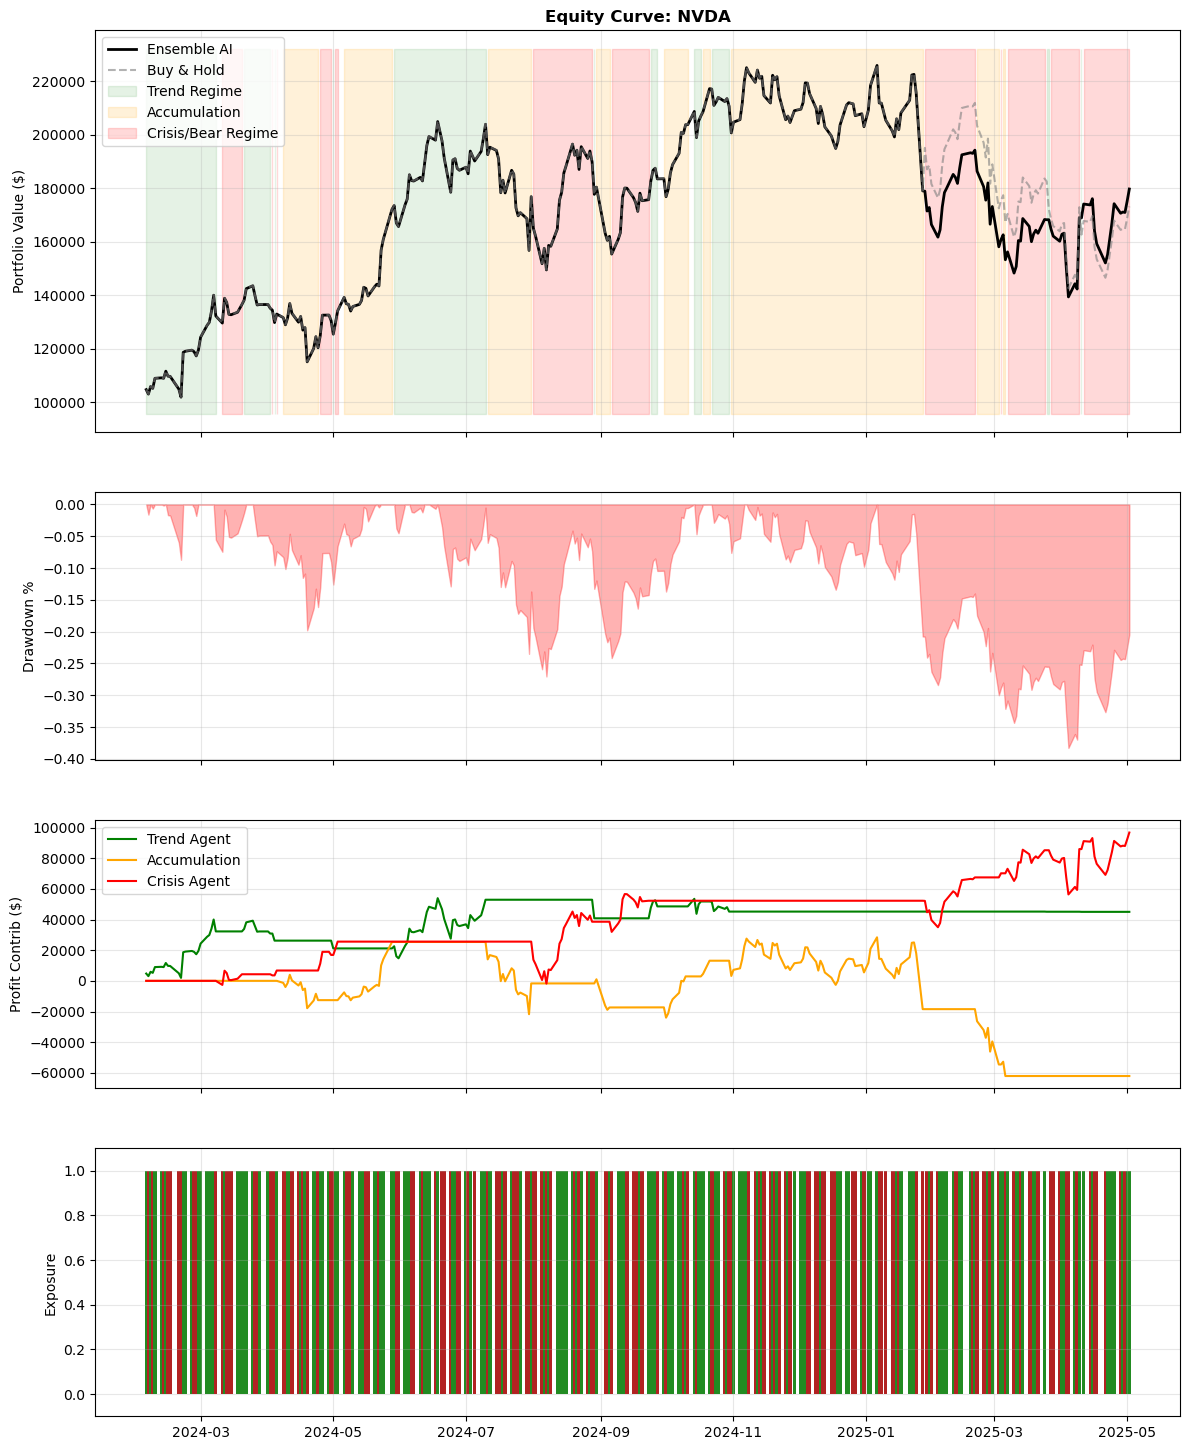

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31",
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), # Volmageddon
        ("2020-01-01", "2020-05-01"), # COVID
        ("2022-01-01", "2022-12-31"), # Bear
    ],
    
    # Hyperparameters (Optimizable)
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # Fixed Params
    "BB_STD": 2.0,
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 64,
    "TRAINING_STEPS": 50000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    "ACTION_SCALER": 5.0,
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / df['tr_s'])
        df['di_minus'] = 100 * (df['dm_s'] / df['tr_s'])
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'])
        df['adx'] = df['dx'].rolling(window).mean()
        
        # Mean Reversion
        sma = df[target].rolling(20).mean()
        std = df[target].rolling(20).std()
        df['bb_width'] = (std * 2 * 2) / sma
        df['pct_b'] = (df[target] - (sma - 2*std)) / (4*std)
        
        # Crisis
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # Volatility
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_pct_b = self.cols.index('pct_b') if 'pct_b' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        
        reward = 0
        if self.mode == 'trend':
            reward = act * ret * 100
            if self.idx_sma != -1:
                sma_dist = self.data[self.current_step, self.idx_sma]
                if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
                elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
                
        elif self.mode == 'accumulation': 
            reward = (act * ret * 100) 
            if act > 0.5: reward += 0.05 * act
            if act < 0: reward -= 0.1 * abs(act)

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01 and act < -0.1: reward *= 2.0 
            elif ret < -0.01 and act > 0.1: reward -= (act * 10.0) 
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print("\n=== 1. TRAINING SPECIALIST AGENTS ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        # 1. Trend
        env_trend = DummyVecEnv([lambda: TradingEnv(trend_data, self.config, mode='trend')])
        env_trend = VecNormalize(env_trend, norm_obs=True, norm_reward=False)
        model_trend = PPO("MlpPolicy", env_trend, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_trend.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['trend'] = model_trend
        self.envs['trend'] = env_trend
        
        # 2. Accumulation
        env_acc = DummyVecEnv([lambda: TradingEnv(trend_data, self.config, mode='accumulation')]) 
        env_acc = VecNormalize(env_acc, norm_obs=True, norm_reward=False)
        model_acc = PPO("MlpPolicy", env_acc, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_acc.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['accumulation'] = model_acc
        self.envs['accumulation'] = env_acc
        
        # 3. Crisis
        crash_data = self.dp.get_crisis_data()
        env_crisis = DummyVecEnv([lambda: TradingEnv(crash_data, self.config, mode='crisis')])
        env_crisis = VecNormalize(env_crisis, norm_obs=True, norm_reward=False)
        model_crisis = PPO("MlpPolicy", env_crisis, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_crisis.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['crisis'] = model_crisis
        self.envs['crisis'] = env_crisis
        
        if verbose: print("=== TRAINING COMPLETE ===\n")

    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        if plot_results: print(f"=== 2. RUNNING BACKTEST ({s_date} to {e_date}) ===")
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return 0.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return 0.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        regime_stats = {
            'trend': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0},
            'accumulation': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0},
            'crisis': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0}
        }
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        idx_pct_b = cols.index('pct_b')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        agent_pnls = {'trend': 0.0, 'accumulation': 0.0, 'crisis': 0.0}
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            
            # --- DYNAMIC THRESHOLDS FROM CONFIG ---
            JUMP_THRESH = self.config['JUMP_THRESHOLD']
            ADX_THRESH = self.config['ADX_THRESHOLD']
            
            is_bullish_jump = (l_stat > JUMP_THRESH)
            is_bearish_jump = (l_stat < -JUMP_THRESH)
            is_extreme_vol = (vol_pct > 0.90)
            is_crash = (sma_dist < -0.10)
            is_bull_trend = (adx > ADX_THRESH) and (di_plus > di_minus)
            is_bear_trend = (adx > ADX_THRESH) and (di_minus > di_plus)
            
            # PRIORITY LOGIC
            if is_bearish_jump:
                regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump:
                regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol or is_crash: 
                regime, active_agent_name = "CRISIS", "crisis"
            elif is_bear_trend:
                regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: 
                regime, active_agent_name = "TREND", "trend"
            else:
                regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            # Exec
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- OVERRIDES ---
            
            if regime == 'JUMP_BULL':
                raw_action = 1.0
            
            if active_agent_name == 'trend' and raw_action < 0:
                raw_action = 0.5 
                
            if active_agent_name == 'accumulation':
                if sma_dist > 0:
                    if raw_action > 0.2: raw_action = 1.0
                    elif raw_action > -0.5: raw_action = 0.5
            
            # Vol Targeting
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.1, 2.0)
            
            # --- DEFENSIVE OVERRIDE (UNLOCKED) ---
            if self.config['LONG_ONLY']:
                # 1. Bearish Jump (Instant Crash) -> Stay Safe
                if regime == 'JUMP_BEAR':
                    scaled_action = 0.0
                
                # 2. Bear Trend (Sustained Drop) -> Check Conviction
                elif regime == 'BEAR_TREND':
                    if raw_action > 0.5:
                        # Allow partial exposure
                        scaled_action = raw_action * self.config['ACTION_SCALER'] * vol_scaler * 0.5 
                    else:
                        scaled_action = 0.0
                
                # 3. Crisis -> Full Control
                elif regime == 'CRISIS':
                    scaled_action = raw_action * self.config['ACTION_SCALER'] * vol_scaler
                
                # 4. Normal
                else:
                    scaled_action = raw_action * self.config['ACTION_SCALER'] * vol_scaler
            else:
                scaled_action = raw_action * self.config['ACTION_SCALER'] * vol_scaler

            if self.config['LONG_ONLY']: scaled_action = np.clip(scaled_action, 0, 10)
            
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (1 + res['Benchmark']).cumprod().iloc[-1] - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            
            print("\n=== AGENT PERFORMANCE BREAKDOWN (vs Benchmark in same period) ===")
            print(f"{'Agent':<12} | {'Days':<6} | {'Agent Ret':<12} | {'Bench Ret':<12} | {'Alpha':<12}")
            print("-" * 65)
            for agent_name, stats in regime_stats.items():
                if stats['days'] > 0:
                    agent_ret = np.exp(stats['log_ret']) - 1
                    bench_ret = np.exp(stats['bench_log_ret']) - 1
                    alpha = agent_ret - bench_ret
                    print(f"{agent_name:<12} | {stats['days']:<6} | {agent_ret:>11.2%} | {bench_ret:>11.2%} | {alpha:>11.2%}")
                else:
                    print(f"{agent_name:<12} | {0:<6} | {'N/A':>11} | {'N/A':>11} | {'0.00%':>11}")
            print("-" * 65)
            
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Ensemble AI', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        
        y_min, y_max = ax0.get_ylim()
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'trend'), color='green', alpha=0.1, label='Trend Regime')
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'accumulation'), color='orange', alpha=0.15, label='Accumulation')
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'crisis'), color='red', alpha=0.15, label='Crisis/Bear Regime')
        ax0.legend(loc='upper left', frameon=True)

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-0.1, self.config['MAX_LEVERAGE']*1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        print(">>> OPTIMIZATION MODE: SMART GRID (Train once per Window, Backtest many) <<<")
        
        # 1. Training Parameters (Requires Retraining PPO)
        training_grid = {
            "WINDOW_SIZE": [40, 60]
        }
        
        # 2. Inference Parameters (Instant Backtest - No Retraining)
        inference_grid = {
            "ADX_THRESHOLD": [15, 20, 25, 35, 45], 
            "JUMP_THRESHOLD": [2.0, 2.5, 3.5, 4.5]
        }
        
        best_ret = -np.inf
        best_config = {} 
        
        # Outer Loop: Architecture (Slow)
        for window in training_grid["WINDOW_SIZE"]:
            print(f"\n[Training Phase] Compiling Agents for Window Size: {window}...")
            
            # Setup Base Config
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end
            base_config['TRAINING_STEPS'] = 10000 
            
            # Train Agents ONCE for this Window Size
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            # Inner Loop: Logic Thresholds (Fast)
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            print(f"[Inference Phase] Testing {len(combinations)} threshold combinations...")
            
            for i, params in enumerate(combinations):
                # Update Manager's Config in-place (No Retraining)
                mgr.config.update(params)
                
                # Set Validation Period
                mgr.config['TEST_START'] = str(int(train_end[:4]) - 1) + train_end[4:]
                mgr.config['TEST_END'] = train_end
                
                # Run Fast Backtest
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = {
                        "WINDOW_SIZE": window,
                        **params
                    }
                    print(f"  >>> NEW BEST: {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    # Safety Defaults for Single Stock
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 
        config['ACTION_SCALER'] = 10.0 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V15 (FINAL) <<<")
    print(f"Config: Window={config['WINDOW_SIZE']}, ADX={config['ADX_THRESHOLD']}, Jump={config['JUMP_THRESHOLD']}")
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["NVDA", "^VIX", "SHY"]
    MY_TARGET = "NVDA"
    START = "2024-02-05" 
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR GOOG <<<
>>> OPTIMIZATION MODE: SMART GRID (Train once per Window, Backtest many) <<<

[Training Phase] Compiling Agents for Window Size: 40...
Fetching data for: ['SHY', 'GOOG', '^VIX'] (2015-01-01 to 2023-12-31)
Fetching data for: ['SHY', 'GOOG', '^VIX'] (2018-10-01 to 2019-01-01)
Fetching data for: ['SHY', 'GOOG', '^VIX'] (2020-01-01 to 2020-05-01)
Fetching data for: ['SHY', 'GOOG', '^VIX'] (2022-01-01 to 2022-12-31)
[Inference Phase] Testing 20 threshold combinations...
Fetching data for: ['SHY', 'GOOG', '^VIX'] (2021-12-31 to 2023-12-31)
  >>> NEW BEST: 13.38% | Win:40 | {'ADX_THRESHOLD': 15, 'JUMP_THRESHOLD': 2.0}
Fetching data for: ['SHY', 'GOOG', '^VIX'] (2021-12-31 to 2023-12-31)
Fetching data for: ['SHY', 'GOOG', '^VIX'] (2021-12-31 to 2023-12-31)
Fetching data for: ['SHY', 'GOOG', '^VIX'] (2021-12-31 to 2023-12-31)
Fetching data for: ['SHY', 'GOOG', '^VIX'] (2021-12-31 to 2023-12-31)
  >>> NEW BEST: 14.18% | Win:40 | {'ADX_THRESH

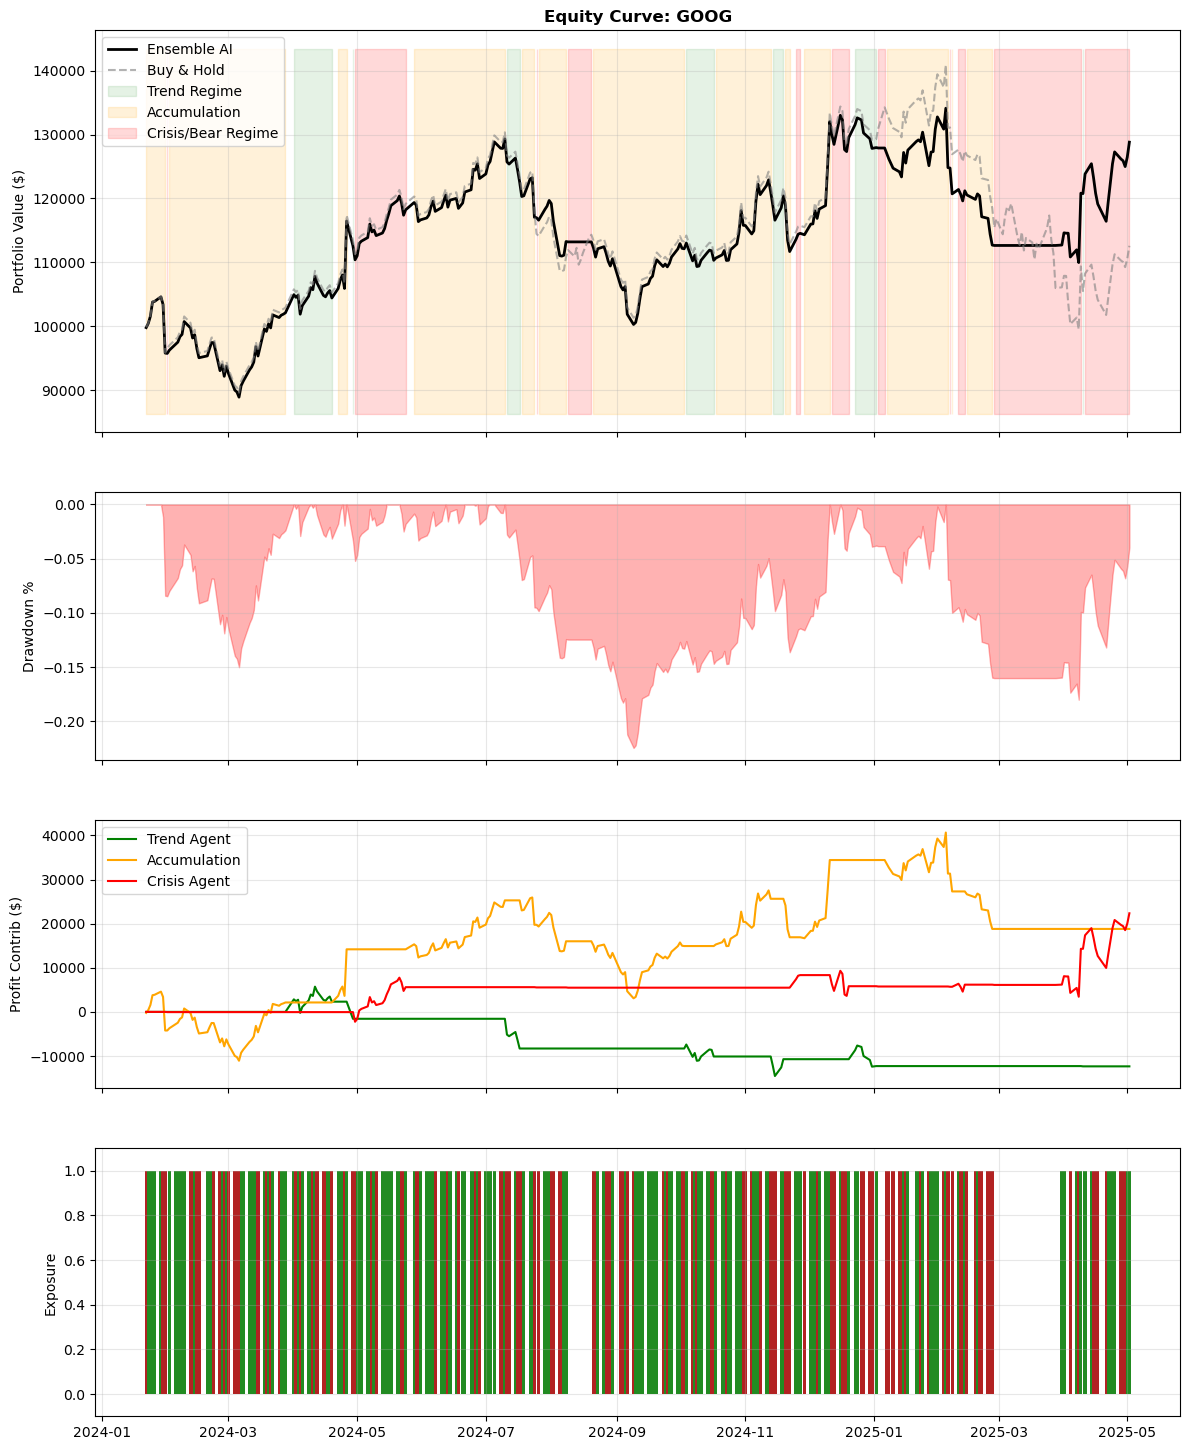

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31",
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), # Volmageddon
        ("2020-01-01", "2020-05-01"), # COVID
        ("2022-01-01", "2022-12-31"), # Bear
    ],
    
    # Hyperparameters (Optimizable)
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # Fixed Params
    "BB_STD": 2.0,
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 64,
    "TRAINING_STEPS": 50000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    "ACTION_SCALER": 5.0,
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / df['tr_s'])
        df['di_minus'] = 100 * (df['dm_s'] / df['tr_s'])
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'])
        df['adx'] = df['dx'].rolling(window).mean()
        
        # Mean Reversion
        sma = df[target].rolling(20).mean()
        std = df[target].rolling(20).std()
        df['bb_width'] = (std * 2 * 2) / sma
        df['pct_b'] = (df[target] - (sma - 2*std)) / (4*std)
        
        # Crisis
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # Volatility
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_pct_b = self.cols.index('pct_b') if 'pct_b' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        
        reward = 0
        if self.mode == 'trend':
            reward = act * ret * 100
            if self.idx_sma != -1:
                sma_dist = self.data[self.current_step, self.idx_sma]
                if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
                elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
                
        elif self.mode == 'accumulation': 
            reward = (act * ret * 100) 
            if act > 0.5: reward += 0.05 * act
            if act < 0: reward -= 0.1 * abs(act)

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01 and act < -0.1: reward *= 2.0 
            elif ret < -0.01 and act > 0.1: reward -= (act * 10.0) 
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print("\n=== 1. TRAINING SPECIALIST AGENTS ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        # 1. Trend
        env_trend = DummyVecEnv([lambda: TradingEnv(trend_data, self.config, mode='trend')])
        env_trend = VecNormalize(env_trend, norm_obs=True, norm_reward=False)
        model_trend = PPO("MlpPolicy", env_trend, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_trend.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['trend'] = model_trend
        self.envs['trend'] = env_trend
        
        # 2. Accumulation
        env_acc = DummyVecEnv([lambda: TradingEnv(trend_data, self.config, mode='accumulation')]) 
        env_acc = VecNormalize(env_acc, norm_obs=True, norm_reward=False)
        model_acc = PPO("MlpPolicy", env_acc, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_acc.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['accumulation'] = model_acc
        self.envs['accumulation'] = env_acc
        
        # 3. Crisis
        crash_data = self.dp.get_crisis_data()
        env_crisis = DummyVecEnv([lambda: TradingEnv(crash_data, self.config, mode='crisis')])
        env_crisis = VecNormalize(env_crisis, norm_obs=True, norm_reward=False)
        model_crisis = PPO("MlpPolicy", env_crisis, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_crisis.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['crisis'] = model_crisis
        self.envs['crisis'] = env_crisis
        
        if verbose: print("=== TRAINING COMPLETE ===\n")

    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        if plot_results: print(f"=== 2. RUNNING BACKTEST ({s_date} to {e_date}) ===")
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return 0.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return 0.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        regime_stats = {
            'trend': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0},
            'accumulation': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0},
            'crisis': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0}
        }
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        idx_pct_b = cols.index('pct_b')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        agent_pnls = {'trend': 0.0, 'accumulation': 0.0, 'crisis': 0.0}
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            
            # --- DYNAMIC THRESHOLDS FROM CONFIG ---
            JUMP_THRESH = self.config['JUMP_THRESHOLD']
            ADX_THRESH = self.config['ADX_THRESHOLD']
            
            is_bullish_jump = (l_stat > JUMP_THRESH)
            is_bearish_jump = (l_stat < -JUMP_THRESH)
            is_extreme_vol = (vol_pct > 0.90)
            is_crash = (sma_dist < -0.10)
            is_bull_trend = (adx > ADX_THRESH) and (di_plus > di_minus)
            is_bear_trend = (adx > ADX_THRESH) and (di_minus > di_plus)
            
            # PRIORITY LOGIC
            if is_bearish_jump:
                regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump:
                regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol or is_crash: 
                regime, active_agent_name = "CRISIS", "crisis"
            elif is_bear_trend:
                regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: 
                regime, active_agent_name = "TREND", "trend"
            else:
                regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            # Exec
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- OVERRIDES ---
            
            if regime == 'JUMP_BULL':
                raw_action = 1.0
            
            if active_agent_name == 'trend' and raw_action < 0:
                raw_action = 0.5 
                
            if active_agent_name == 'accumulation':
                if sma_dist > 0:
                    if raw_action > 0.2: raw_action = 1.0
                    elif raw_action > -0.5: raw_action = 0.5
            
            # Vol Targeting
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.1, 2.0)
            
            # --- DEFENSIVE OVERRIDE (UNLOCKED) ---
            if self.config['LONG_ONLY']:
                # 1. Bearish Jump (Instant Crash) -> Stay Safe
                if regime == 'JUMP_BEAR':
                    scaled_action = 0.0
                
                # 2. Bear Trend (Sustained Drop) -> Check Conviction
                elif regime == 'BEAR_TREND':
                    if raw_action > 0.5:
                        # Allow partial exposure
                        scaled_action = raw_action * self.config['ACTION_SCALER'] * vol_scaler * 0.5 
                    else:
                        scaled_action = 0.0
                
                # 3. Crisis -> Full Control
                elif regime == 'CRISIS':
                    scaled_action = raw_action * self.config['ACTION_SCALER'] * vol_scaler
                
                # 4. Normal
                else:
                    scaled_action = raw_action * self.config['ACTION_SCALER'] * vol_scaler
            else:
                scaled_action = raw_action * self.config['ACTION_SCALER'] * vol_scaler

            if self.config['LONG_ONLY']: scaled_action = np.clip(scaled_action, 0, 10)
            
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (1 + res['Benchmark']).cumprod().iloc[-1] - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            
            print("\n=== AGENT PERFORMANCE BREAKDOWN (vs Benchmark in same period) ===")
            print(f"{'Agent':<12} | {'Days':<6} | {'Agent Ret':<12} | {'Bench Ret':<12} | {'Alpha':<12}")
            print("-" * 65)
            for agent_name, stats in regime_stats.items():
                if stats['days'] > 0:
                    agent_ret = np.exp(stats['log_ret']) - 1
                    bench_ret = np.exp(stats['bench_log_ret']) - 1
                    alpha = agent_ret - bench_ret
                    print(f"{agent_name:<12} | {stats['days']:<6} | {agent_ret:>11.2%} | {bench_ret:>11.2%} | {alpha:>11.2%}")
                else:
                    print(f"{agent_name:<12} | {0:<6} | {'N/A':>11} | {'N/A':>11} | {'0.00%':>11}")
            print("-" * 65)
            
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Ensemble AI', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        
        y_min, y_max = ax0.get_ylim()
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'trend'), color='green', alpha=0.1, label='Trend Regime')
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'accumulation'), color='orange', alpha=0.15, label='Accumulation')
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'crisis'), color='red', alpha=0.15, label='Crisis/Bear Regime')
        ax0.legend(loc='upper left', frameon=True)

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-0.1, self.config['MAX_LEVERAGE']*1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        print(">>> OPTIMIZATION MODE: SMART GRID (Train once per Window, Backtest many) <<<")
        
        # 1. Training Parameters (Requires Retraining PPO)
        training_grid = {
            "WINDOW_SIZE": [40, 60]
        }
        
        # 2. Inference Parameters (Instant Backtest - No Retraining)
        inference_grid = {
            "ADX_THRESHOLD": [15, 20, 25, 35, 45], 
            "JUMP_THRESHOLD": [2.0, 2.5, 3.5, 4.5]
        }
        
        best_ret = -np.inf
        best_config = {} 
        
        # Outer Loop: Architecture (Slow)
        for window in training_grid["WINDOW_SIZE"]:
            print(f"\n[Training Phase] Compiling Agents for Window Size: {window}...")
            
            # Setup Base Config
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end
            base_config['TRAINING_STEPS'] = 10000 
            
            # Train Agents ONCE for this Window Size
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            # Inner Loop: Logic Thresholds (Fast)
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            print(f"[Inference Phase] Testing {len(combinations)} threshold combinations...")
            
            for i, params in enumerate(combinations):
                # Update Manager's Config in-place (No Retraining)
                mgr.config.update(params)
                
                # Set Validation Period
                mgr.config['TEST_START'] = str(int(train_end[:4]) - 1) + train_end[4:]
                mgr.config['TEST_END'] = train_end
                
                # Run Fast Backtest
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = {
                        "WINDOW_SIZE": window,
                        **params
                    }
                    print(f"  >>> NEW BEST: {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    # Safety Defaults for Single Stock
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 
        config['ACTION_SCALER'] = 10.0 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V15 (FINAL) <<<")
    print(f"Config: Window={config['WINDOW_SIZE']}, ADX={config['ADX_THRESHOLD']}, Jump={config['JUMP_THRESHOLD']}")
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["GOOG", "^VIX", "SHY"]
    MY_TARGET = "GOOG"
    START = "2024-01-22"
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)


>>> INITIALIZING TRINITY V7.1 (REVISED) <<<

=== 1. TRAINING SPECIALIST AGENTS (v7.1) ===
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
=== TRAINING COMPLETE ===

=== 2. RUNNING BACKTEST (2024-01-22 to 2025-05-05) | Target: NVDA ===
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2023-01-22 to 2025-05-05)
Date         | Regime       | Active Agent | Raw Act  | Scale Act  | Portfolio  | Bench      | Daily Alpha
------------------------------------------------------------------------------------------------------------------------
2024-02-05   | TREND        | trend        | 1.00     | 1.00       | 116484     | 116542     |        0 bps
2024-03-05   | TREND        | trend        | 1.00     | 1.00       | 144434     | 144506   

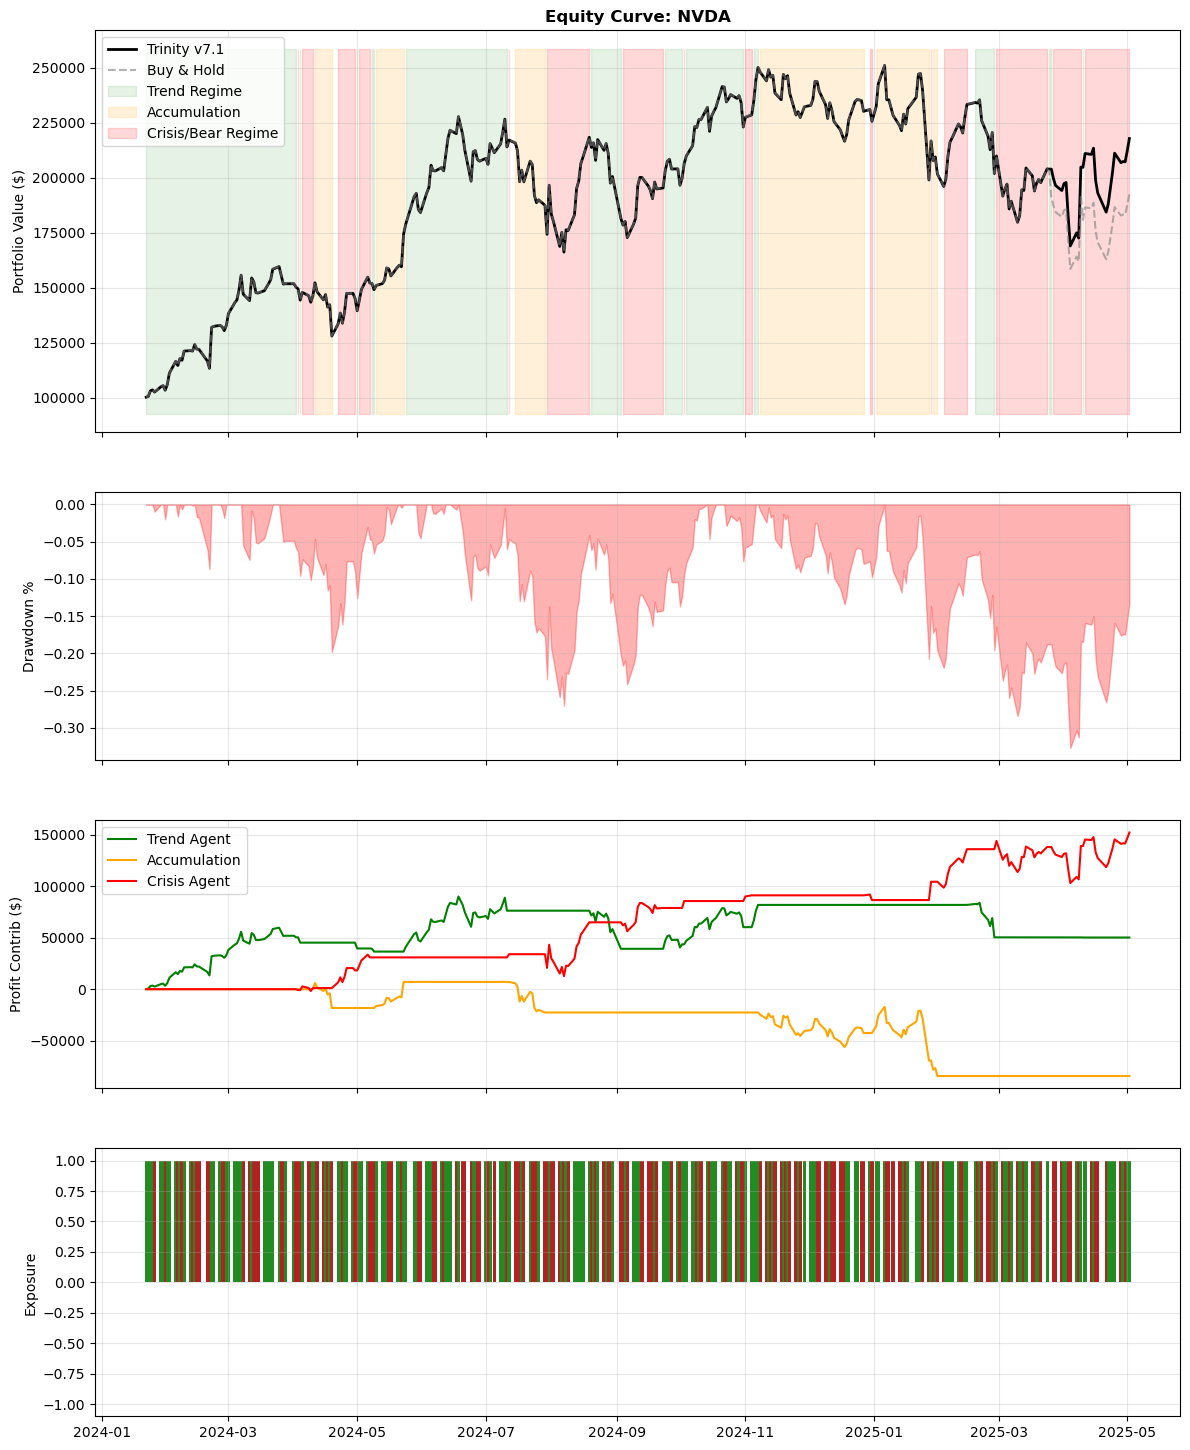

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7 BASE) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31",
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), # Volmageddon
        ("2020-01-01", "2020-05-01"), # COVID
        ("2022-01-01", "2022-12-31"), # Bear
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # Fixed Params
    "BB_STD": 2.0,
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 64,
    "TRAINING_STEPS": 50000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    "ACTION_SCALER": 5.0,
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR (v7 Original) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / df['tr_s'])
        df['di_minus'] = 100 * (df['dm_s'] / df['tr_s'])
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'])
        df['adx'] = df['dx'].rolling(window).mean()
        
        # Mean Reversion
        sma = df[target].rolling(20).mean()
        std = df[target].rolling(20).std()
        df['bb_width'] = (std * 2 * 2) / sma
        df['pct_b'] = (df[target] - (sma - 2*std)) / (4*std)
        
        # Crisis
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # Volatility
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7 Original) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        
        reward = 0
        if self.mode == 'trend':
            reward = act * ret * 100
            if self.idx_sma != -1:
                sma_dist = self.data[self.current_step, self.idx_sma]
                if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
                elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
                
        elif self.mode == 'accumulation': 
            reward = (act * ret * 100) 
            # Fix: Don't reward simple buy & hold in accumulation.
            # Reward reverting logic slightly more.
            if act > 0.5: reward += 0.01 * act
            if act < 0: reward -= 0.05 * abs(act)

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01 and act < -0.1: reward *= 2.0 
            elif ret < -0.01 and act > 0.1: reward -= (act * 10.0) 
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7 Enhanced) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print("\n=== 1. TRAINING SPECIALIST AGENTS (v7.1) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        # 1. Trend
        env_trend = DummyVecEnv([lambda: TradingEnv(trend_data, self.config, mode='trend')])
        env_trend = VecNormalize(env_trend, norm_obs=True, norm_reward=False)
        model_trend = PPO("MlpPolicy", env_trend, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_trend.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['trend'] = model_trend
        self.envs['trend'] = env_trend
        
        # 2. Accumulation
        env_acc = DummyVecEnv([lambda: TradingEnv(trend_data, self.config, mode='accumulation')]) 
        env_acc = VecNormalize(env_acc, norm_obs=True, norm_reward=False)
        model_acc = PPO("MlpPolicy", env_acc, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_acc.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['accumulation'] = model_acc
        self.envs['accumulation'] = env_acc
        
        # 3. Crisis
        crash_data = self.dp.get_crisis_data()
        env_crisis = DummyVecEnv([lambda: TradingEnv(crash_data, self.config, mode='crisis')])
        env_crisis = VecNormalize(env_crisis, norm_obs=True, norm_reward=False)
        model_crisis = PPO("MlpPolicy", env_crisis, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_crisis.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['crisis'] = model_crisis
        self.envs['crisis'] = env_crisis
        
        if verbose: print("=== TRAINING COMPLETE ===\n")

    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        if plot_results: print(f"=== 2. RUNNING BACKTEST ({s_date} to {e_date}) | Target: {self.config['TARGET_ASSET']} ===")
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return 0.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return 0.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        regime_stats = {
            'trend': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0},
            'accumulation': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0},
            'crisis': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0}
        }
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        agent_pnls = {'trend': 0.0, 'accumulation': 0.0, 'crisis': 0.0}
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            
            # --- DYNAMIC THRESHOLDS FROM CONFIG ---
            JUMP_THRESH = self.config['JUMP_THRESHOLD']
            ADX_THRESH = self.config['ADX_THRESHOLD']
            
            is_bullish_jump = (l_stat > JUMP_THRESH)
            is_bearish_jump = (l_stat < -JUMP_THRESH)
            is_extreme_vol = (vol_pct > 0.90)
            is_crash = (sma_dist < -0.10)
            is_bull_trend = (adx > ADX_THRESH) and (di_plus > di_minus)
            is_bear_trend = (adx > ADX_THRESH) and (di_minus > di_plus)
            
            # --- GATING LOGIC (FIXED) ---
            # 1. Jump Logic Override
            if is_bearish_jump:
                regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump:
                regime, active_agent_name = "JUMP_BULL", "trend"
                
            # 2. Crisis Gating (FIX: High Vol + Upside = Trend, High Vol + Downside = Crisis)
            elif (is_extreme_vol and sma_dist < 0) or is_crash: 
                regime, active_agent_name = "CRISIS", "crisis"
                
            # 3. Trend Logic
            elif is_bear_trend:
                regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: 
                regime, active_agent_name = "TREND", "trend"
            else:
                regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            # Exec
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- OVERRIDES (RESTORED & ENHANCED) ---
            
            # Force Aggression on Bull Jump
            if regime == 'JUMP_BULL':
                raw_action = 1.0
            
            # Force Trend Bias
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0: raw_action = 0.5 # Force Long in Bull Trend
                
            # Force Accumulation Limits
            if active_agent_name == 'accumulation':
                if sma_dist > 0:
                    if raw_action > 0.2: raw_action = 1.0 # If slight conviction in bull, go full
                    elif raw_action > -0.5: raw_action = 0.5 # Don't short bull chop too hard
            
            # Vol Targeting
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.1, 2.0)
            
            scaled_action = raw_action * self.config['ACTION_SCALER'] * vol_scaler
            
            # Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            
            print("\n=== AGENT PERFORMANCE BREAKDOWN (vs Benchmark in same period) ===")
            print(f"{'Agent':<12} | {'Days':<6} | {'Agent Ret':<12} | {'Bench Ret':<12} | {'Alpha':<12}")
            print("-" * 65)
            for agent_name, stats in regime_stats.items():
                if stats['days'] > 0:
                    agent_ret = np.exp(stats['log_ret']) - 1
                    bench_ret = np.exp(stats['bench_log_ret']) - 1
                    alpha = agent_ret - bench_ret
                    print(f"{agent_name:<12} | {stats['days']:<6} | {agent_ret:>11.2%} | {bench_ret:>11.2%} | {alpha:>11.2%}")
                else:
                    print(f"{agent_name:<12} | {0:<6} | {'N/A':>11} | {'N/A':>11} | {'0.00%':>11}")
            print("-" * 65)
            
            self.plot_dashboard(res, benchmark_equity)
            
        return total_ret
    
    def plot_dashboard(self, res, final_bench):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        # Recalculate Bench Equity curve for plotting
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.1', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        
        y_min, y_max = ax0.get_ylim()
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'trend'), color='green', alpha=0.1, label='Trend Regime')
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'accumulation'), color='orange', alpha=0.15, label='Accumulation')
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'crisis'), color='red', alpha=0.15, label='Crisis/Bear Regime')
        ax0.legend(loc='upper left', frameon=True)

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        print(">>> OPTIMIZATION MODE: SMART GRID (Train once per Window, Backtest many) <<<")
        
        training_grid = { "WINDOW_SIZE": [60] } # Simplified for speed
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    # Safety Defaults
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 
        config['ACTION_SCALER'] = 5.0 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.1 (REVISED) <<<")
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["NVDA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "NVDA"
    START = "2024-01-22"
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=False)


>>> INITIALIZING TRINITY V7.1 (REVISED) <<<

=== 1. TRAINING SPECIALIST AGENTS (v7.1) ===
Fetching data for: ['^VIX', 'SHY', 'GOOG', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['^VIX', 'SHY', 'GOOG', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['^VIX', 'SHY', 'GOOG', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['^VIX', 'SHY', 'GOOG', 'QQQ'] (2022-01-01 to 2022-12-31)
=== TRAINING COMPLETE ===

=== 2. RUNNING BACKTEST (2024-01-22 to 2025-05-05) | Target: GOOG ===
Fetching data for: ['^VIX', 'SHY', 'GOOG', 'QQQ'] (2023-01-22 to 2025-05-05)
Date         | Regime       | Active Agent | Raw Act  | Scale Act  | Portfolio  | Bench      | Daily Alpha
------------------------------------------------------------------------------------------------------------------------
2024-02-05   | BEAR_TREND   | crisis       | 0.23     | 1.00       | 97896      | 97946      |        0 bps
2024-03-05   | BEAR_TREND   | crisis       | 0.25     | 1.00       | 90467      | 90410    

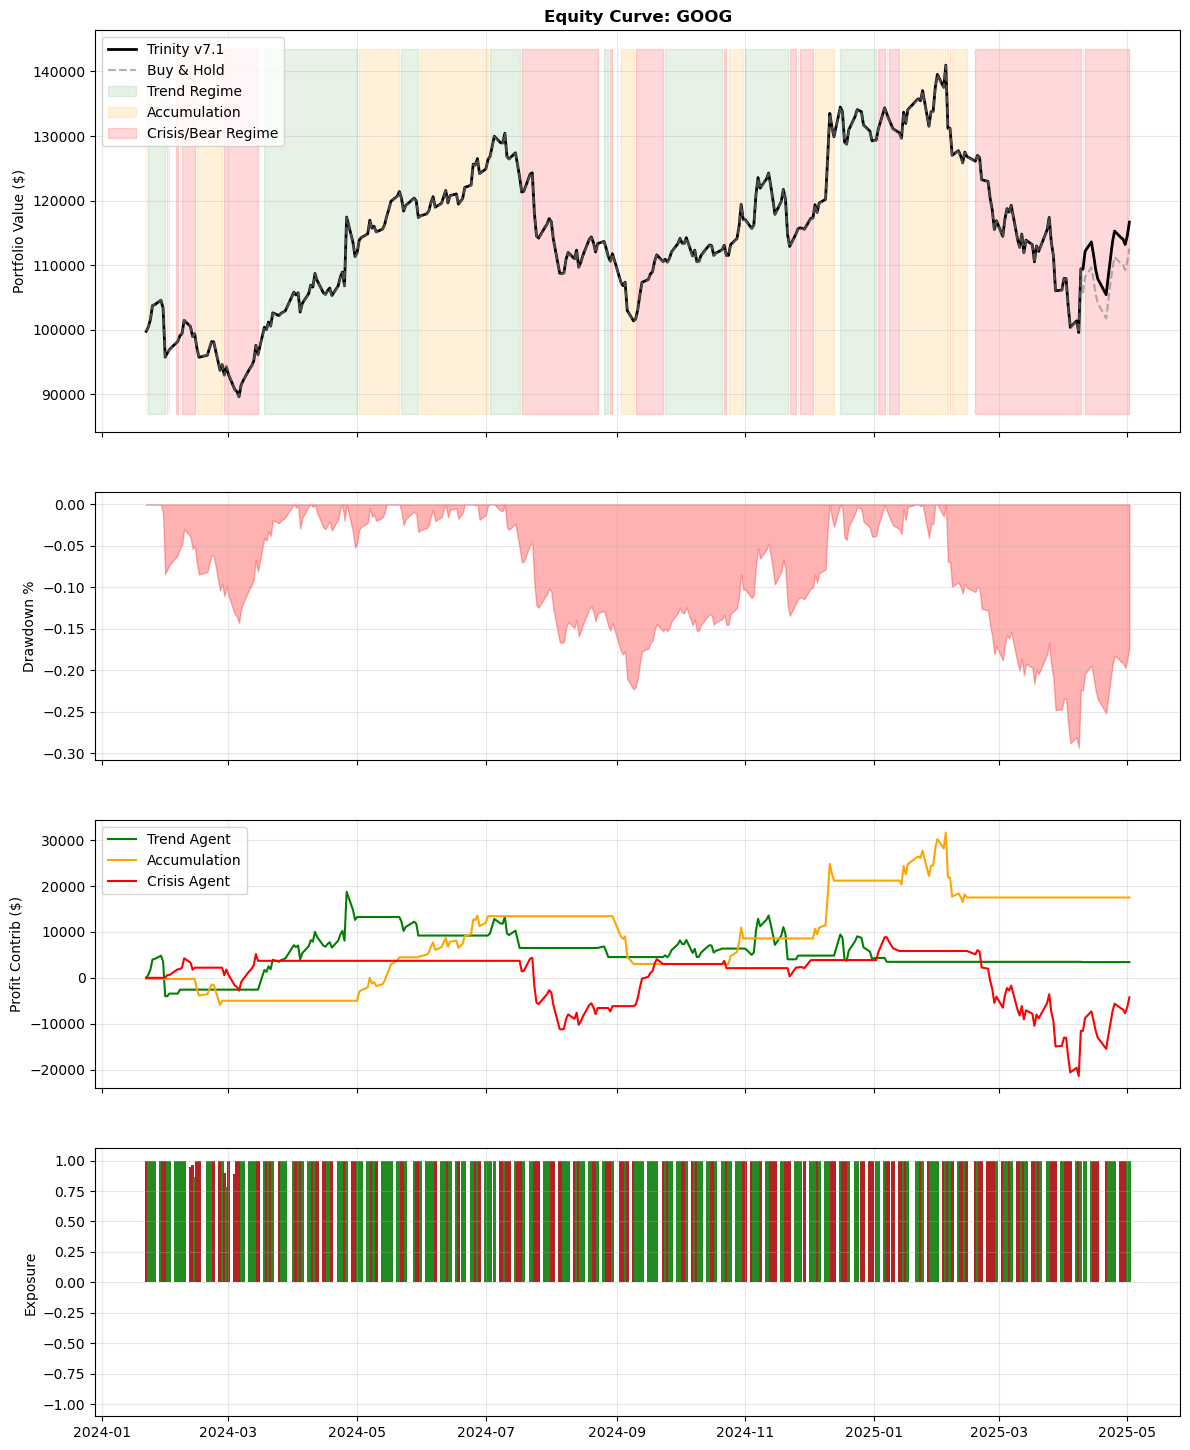

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7 BASE) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31",
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), # Volmageddon
        ("2020-01-01", "2020-05-01"), # COVID
        ("2022-01-01", "2022-12-31"), # Bear
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # Fixed Params
    "BB_STD": 2.0,
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 64,
    "TRAINING_STEPS": 50000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    "ACTION_SCALER": 5.0,
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR (v7 Original) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / df['tr_s'])
        df['di_minus'] = 100 * (df['dm_s'] / df['tr_s'])
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'])
        df['adx'] = df['dx'].rolling(window).mean()
        
        # Mean Reversion
        sma = df[target].rolling(20).mean()
        std = df[target].rolling(20).std()
        df['bb_width'] = (std * 2 * 2) / sma
        df['pct_b'] = (df[target] - (sma - 2*std)) / (4*std)
        
        # Crisis
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # Volatility
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7 Original) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        
        reward = 0
        if self.mode == 'trend':
            reward = act * ret * 100
            if self.idx_sma != -1:
                sma_dist = self.data[self.current_step, self.idx_sma]
                if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
                elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
                
        elif self.mode == 'accumulation': 
            reward = (act * ret * 100) 
            # Fix: Don't reward simple buy & hold in accumulation.
            # Reward reverting logic slightly more.
            if act > 0.5: reward += 0.01 * act
            if act < 0: reward -= 0.05 * abs(act)

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01 and act < -0.1: reward *= 2.0 
            elif ret < -0.01 and act > 0.1: reward -= (act * 10.0) 
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7 Enhanced) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print("\n=== 1. TRAINING SPECIALIST AGENTS (v7.1) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        # 1. Trend
        env_trend = DummyVecEnv([lambda: TradingEnv(trend_data, self.config, mode='trend')])
        env_trend = VecNormalize(env_trend, norm_obs=True, norm_reward=False)
        model_trend = PPO("MlpPolicy", env_trend, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_trend.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['trend'] = model_trend
        self.envs['trend'] = env_trend
        
        # 2. Accumulation
        env_acc = DummyVecEnv([lambda: TradingEnv(trend_data, self.config, mode='accumulation')]) 
        env_acc = VecNormalize(env_acc, norm_obs=True, norm_reward=False)
        model_acc = PPO("MlpPolicy", env_acc, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_acc.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['accumulation'] = model_acc
        self.envs['accumulation'] = env_acc
        
        # 3. Crisis
        crash_data = self.dp.get_crisis_data()
        env_crisis = DummyVecEnv([lambda: TradingEnv(crash_data, self.config, mode='crisis')])
        env_crisis = VecNormalize(env_crisis, norm_obs=True, norm_reward=False)
        model_crisis = PPO("MlpPolicy", env_crisis, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_crisis.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['crisis'] = model_crisis
        self.envs['crisis'] = env_crisis
        
        if verbose: print("=== TRAINING COMPLETE ===\n")

    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        if plot_results: print(f"=== 2. RUNNING BACKTEST ({s_date} to {e_date}) | Target: {self.config['TARGET_ASSET']} ===")
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return 0.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return 0.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        regime_stats = {
            'trend': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0},
            'accumulation': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0},
            'crisis': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0}
        }
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        agent_pnls = {'trend': 0.0, 'accumulation': 0.0, 'crisis': 0.0}
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            
            # --- DYNAMIC THRESHOLDS FROM CONFIG ---
            JUMP_THRESH = self.config['JUMP_THRESHOLD']
            ADX_THRESH = self.config['ADX_THRESHOLD']
            
            is_bullish_jump = (l_stat > JUMP_THRESH)
            is_bearish_jump = (l_stat < -JUMP_THRESH)
            is_extreme_vol = (vol_pct > 0.90)
            is_crash = (sma_dist < -0.10)
            is_bull_trend = (adx > ADX_THRESH) and (di_plus > di_minus)
            is_bear_trend = (adx > ADX_THRESH) and (di_minus > di_plus)
            
            # --- GATING LOGIC (FIXED) ---
            # 1. Jump Logic Override
            if is_bearish_jump:
                regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump:
                regime, active_agent_name = "JUMP_BULL", "trend"
                
            # 2. Crisis Gating (FIX: High Vol + Upside = Trend, High Vol + Downside = Crisis)
            elif (is_extreme_vol and sma_dist < 0) or is_crash: 
                regime, active_agent_name = "CRISIS", "crisis"
                
            # 3. Trend Logic
            elif is_bear_trend:
                regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: 
                regime, active_agent_name = "TREND", "trend"
            else:
                regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            # Exec
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- OVERRIDES (RESTORED & ENHANCED) ---
            
            # Force Aggression on Bull Jump
            if regime == 'JUMP_BULL':
                raw_action = 1.0
            
            # Force Trend Bias
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0: raw_action = 0.5 # Force Long in Bull Trend
                
            # Force Accumulation Limits
            if active_agent_name == 'accumulation':
                if sma_dist > 0:
                    if raw_action > 0.2: raw_action = 1.0 # If slight conviction in bull, go full
                    elif raw_action > -0.5: raw_action = 0.5 # Don't short bull chop too hard
            
            # Vol Targeting
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.1, 2.0)
            
            scaled_action = raw_action * self.config['ACTION_SCALER'] * vol_scaler
            
            # Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            
            print("\n=== AGENT PERFORMANCE BREAKDOWN (vs Benchmark in same period) ===")
            print(f"{'Agent':<12} | {'Days':<6} | {'Agent Ret':<12} | {'Bench Ret':<12} | {'Alpha':<12}")
            print("-" * 65)
            for agent_name, stats in regime_stats.items():
                if stats['days'] > 0:
                    agent_ret = np.exp(stats['log_ret']) - 1
                    bench_ret = np.exp(stats['bench_log_ret']) - 1
                    alpha = agent_ret - bench_ret
                    print(f"{agent_name:<12} | {stats['days']:<6} | {agent_ret:>11.2%} | {bench_ret:>11.2%} | {alpha:>11.2%}")
                else:
                    print(f"{agent_name:<12} | {0:<6} | {'N/A':>11} | {'N/A':>11} | {'0.00%':>11}")
            print("-" * 65)
            
            self.plot_dashboard(res, benchmark_equity)
            
        return total_ret
    
    def plot_dashboard(self, res, final_bench):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        # Recalculate Bench Equity curve for plotting
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.1', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        
        y_min, y_max = ax0.get_ylim()
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'trend'), color='green', alpha=0.1, label='Trend Regime')
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'accumulation'), color='orange', alpha=0.15, label='Accumulation')
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'crisis'), color='red', alpha=0.15, label='Crisis/Bear Regime')
        ax0.legend(loc='upper left', frameon=True)

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        print(">>> OPTIMIZATION MODE: SMART GRID (Train once per Window, Backtest many) <<<")
        
        training_grid = { "WINDOW_SIZE": [60] } # Simplified for speed
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    # Safety Defaults
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 
        config['ACTION_SCALER'] = 5.0 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.1 (REVISED) <<<")
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["GOOG", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "GOOG"
    START = "2024-01-22"
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=False)


>>> INITIALIZING TRINITY V7.1 (REVISED) <<<

=== 1. TRAINING SPECIALIST AGENTS (v7.1) ===
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
=== TRAINING COMPLETE ===

=== 2. RUNNING BACKTEST (2024-12-12 to 2025-12-12) | Target: TSLA ===
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2023-12-13 to 2025-12-12)
Date         | Regime       | Active Agent | Raw Act  | Scale Act  | Portfolio  | Bench      | Daily Alpha
------------------------------------------------------------------------------------------------------------------------
2024-12-26   | TREND        | trend        | 0.38     | 1.00       | 106858     | 106912     |        0 bps
2025-01-28   | ACCUMULATION | accumulation | 1.00     | 1.00       | 93671      | 93719    

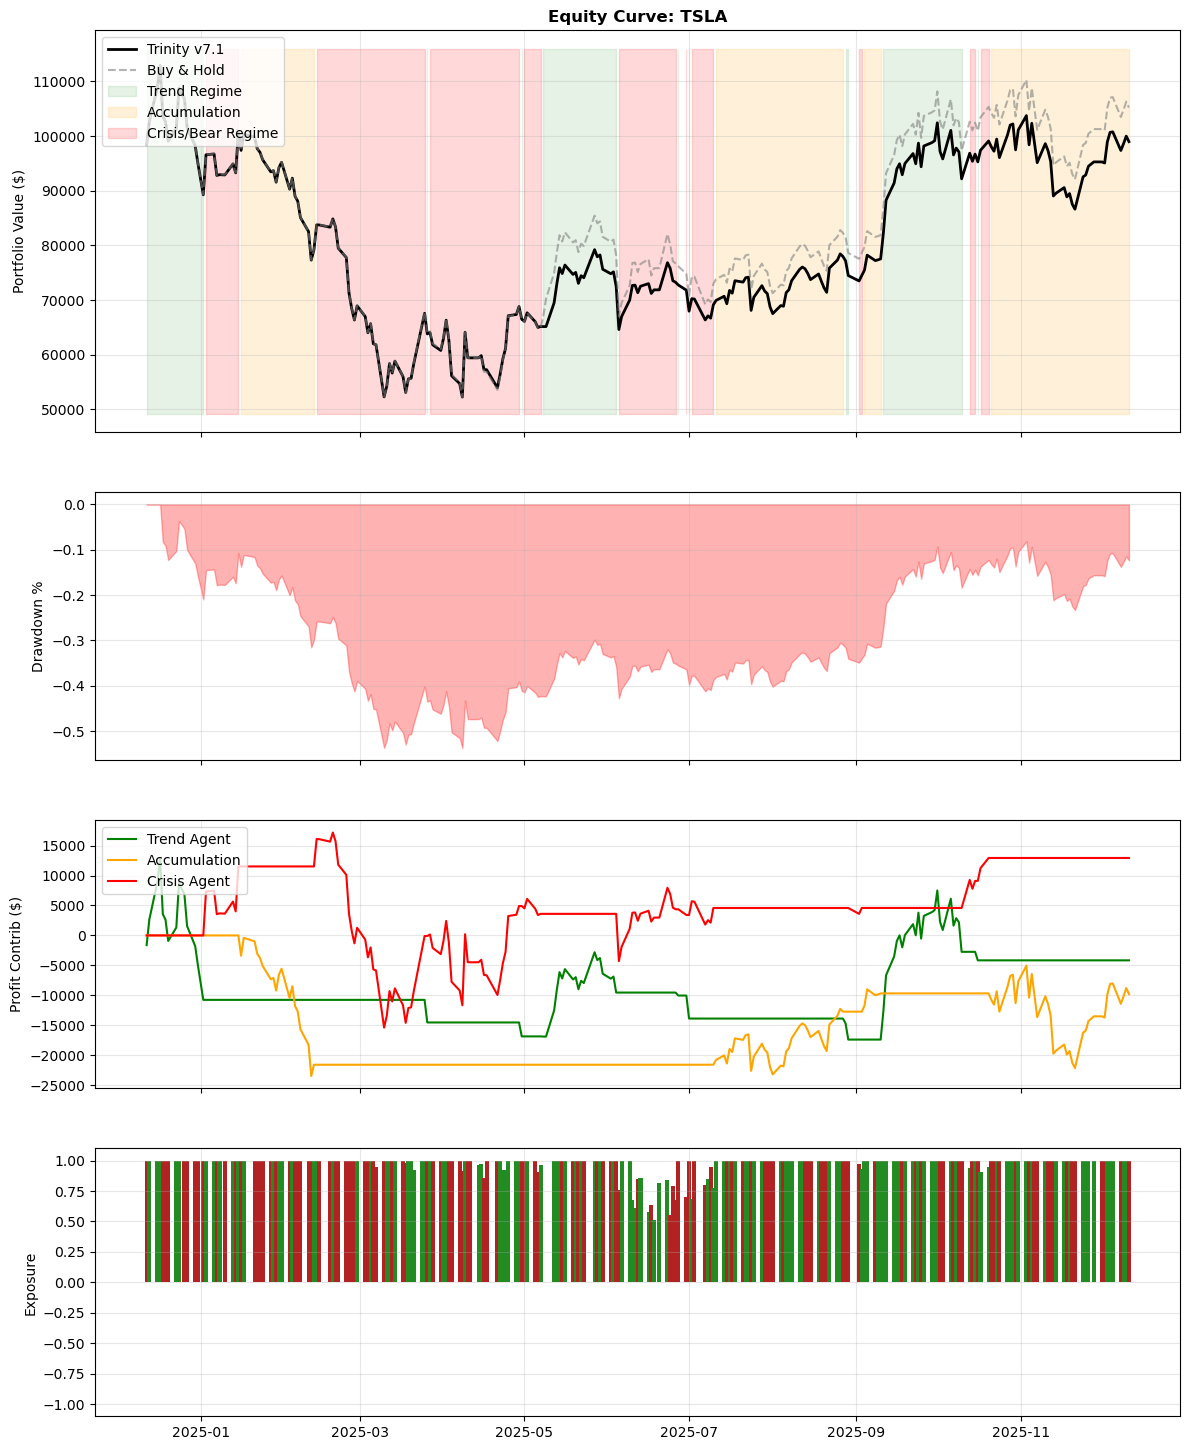

In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7 BASE) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31",
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), # Volmageddon
        ("2020-01-01", "2020-05-01"), # COVID
        ("2022-01-01", "2022-12-31"), # Bear
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # Fixed Params
    "BB_STD": 2.0,
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 64,
    "TRAINING_STEPS": 50000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    "ACTION_SCALER": 5.0,
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR (v7 Original) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / df['tr_s'])
        df['di_minus'] = 100 * (df['dm_s'] / df['tr_s'])
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'])
        df['adx'] = df['dx'].rolling(window).mean()
        
        # Mean Reversion
        sma = df[target].rolling(20).mean()
        std = df[target].rolling(20).std()
        df['bb_width'] = (std * 2 * 2) / sma
        df['pct_b'] = (df[target] - (sma - 2*std)) / (4*std)
        
        # Crisis
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # Volatility
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7 Original) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        
        reward = 0
        if self.mode == 'trend':
            reward = act * ret * 100
            if self.idx_sma != -1:
                sma_dist = self.data[self.current_step, self.idx_sma]
                if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
                elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
                
        elif self.mode == 'accumulation': 
            reward = (act * ret * 100) 
            # Fix: Don't reward simple buy & hold in accumulation.
            # Reward reverting logic slightly more.
            if act > 0.5: reward += 0.01 * act
            if act < 0: reward -= 0.05 * abs(act)

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01 and act < -0.1: reward *= 2.0 
            elif ret < -0.01 and act > 0.1: reward -= (act * 10.0) 
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7 Enhanced) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print("\n=== 1. TRAINING SPECIALIST AGENTS (v7.1) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        # 1. Trend
        env_trend = DummyVecEnv([lambda: TradingEnv(trend_data, self.config, mode='trend')])
        env_trend = VecNormalize(env_trend, norm_obs=True, norm_reward=False)
        model_trend = PPO("MlpPolicy", env_trend, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_trend.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['trend'] = model_trend
        self.envs['trend'] = env_trend
        
        # 2. Accumulation
        env_acc = DummyVecEnv([lambda: TradingEnv(trend_data, self.config, mode='accumulation')]) 
        env_acc = VecNormalize(env_acc, norm_obs=True, norm_reward=False)
        model_acc = PPO("MlpPolicy", env_acc, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_acc.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['accumulation'] = model_acc
        self.envs['accumulation'] = env_acc
        
        # 3. Crisis
        crash_data = self.dp.get_crisis_data()
        env_crisis = DummyVecEnv([lambda: TradingEnv(crash_data, self.config, mode='crisis')])
        env_crisis = VecNormalize(env_crisis, norm_obs=True, norm_reward=False)
        model_crisis = PPO("MlpPolicy", env_crisis, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_crisis.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['crisis'] = model_crisis
        self.envs['crisis'] = env_crisis
        
        if verbose: print("=== TRAINING COMPLETE ===\n")

    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        if plot_results: print(f"=== 2. RUNNING BACKTEST ({s_date} to {e_date}) | Target: {self.config['TARGET_ASSET']} ===")
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return 0.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return 0.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        regime_stats = {
            'trend': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0},
            'accumulation': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0},
            'crisis': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0}
        }
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        agent_pnls = {'trend': 0.0, 'accumulation': 0.0, 'crisis': 0.0}
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            
            # --- DYNAMIC THRESHOLDS FROM CONFIG ---
            JUMP_THRESH = self.config['JUMP_THRESHOLD']
            ADX_THRESH = self.config['ADX_THRESHOLD']
            
            is_bullish_jump = (l_stat > JUMP_THRESH)
            is_bearish_jump = (l_stat < -JUMP_THRESH)
            is_extreme_vol = (vol_pct > 0.90)
            is_crash = (sma_dist < -0.10)
            is_bull_trend = (adx > ADX_THRESH) and (di_plus > di_minus)
            is_bear_trend = (adx > ADX_THRESH) and (di_minus > di_plus)
            
            # --- GATING LOGIC (FIXED) ---
            # 1. Jump Logic Override
            if is_bearish_jump:
                regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump:
                regime, active_agent_name = "JUMP_BULL", "trend"
                
            # 2. Crisis Gating (FIX: High Vol + Upside = Trend, High Vol + Downside = Crisis)
            elif (is_extreme_vol and sma_dist < 0) or is_crash: 
                regime, active_agent_name = "CRISIS", "crisis"
                
            # 3. Trend Logic
            elif is_bear_trend:
                regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: 
                regime, active_agent_name = "TREND", "trend"
            else:
                regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            # Exec
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- OVERRIDES (RESTORED & ENHANCED) ---
            
            # Force Aggression on Bull Jump
            if regime == 'JUMP_BULL':
                raw_action = 1.0
            
            # Force Trend Bias
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0: raw_action = 0.5 # Force Long in Bull Trend
                
            # Force Accumulation Limits
            if active_agent_name == 'accumulation':
                if sma_dist > 0:
                    if raw_action > 0.2: raw_action = 1.0 # If slight conviction in bull, go full
                    elif raw_action > -0.5: raw_action = 0.5 # Don't short bull chop too hard
            
            # Vol Targeting
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.1, 2.0)
            
            scaled_action = raw_action * self.config['ACTION_SCALER'] * vol_scaler
            
            # Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            
            print("\n=== AGENT PERFORMANCE BREAKDOWN (vs Benchmark in same period) ===")
            print(f"{'Agent':<12} | {'Days':<6} | {'Agent Ret':<12} | {'Bench Ret':<12} | {'Alpha':<12}")
            print("-" * 65)
            for agent_name, stats in regime_stats.items():
                if stats['days'] > 0:
                    agent_ret = np.exp(stats['log_ret']) - 1
                    bench_ret = np.exp(stats['bench_log_ret']) - 1
                    alpha = agent_ret - bench_ret
                    print(f"{agent_name:<12} | {stats['days']:<6} | {agent_ret:>11.2%} | {bench_ret:>11.2%} | {alpha:>11.2%}")
                else:
                    print(f"{agent_name:<12} | {0:<6} | {'N/A':>11} | {'N/A':>11} | {'0.00%':>11}")
            print("-" * 65)
            
            self.plot_dashboard(res, benchmark_equity)
            
        return total_ret
    
    def plot_dashboard(self, res, final_bench):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        # Recalculate Bench Equity curve for plotting
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.1', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        
        y_min, y_max = ax0.get_ylim()
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'trend'), color='green', alpha=0.1, label='Trend Regime')
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'accumulation'), color='orange', alpha=0.15, label='Accumulation')
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'crisis'), color='red', alpha=0.15, label='Crisis/Bear Regime')
        ax0.legend(loc='upper left', frameon=True)

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        print(">>> OPTIMIZATION MODE: SMART GRID (Train once per Window, Backtest many) <<<")
        
        training_grid = { "WINDOW_SIZE": [60] } # Simplified for speed
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    # Safety Defaults
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 
        config['ACTION_SCALER'] = 5.0 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.1 (REVISED) <<<")
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["TSLA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "TSLA"
    START = "2024-12-12"
    END = "2025-12-12"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=False)


>>> INITIALIZING TRINITY V7.2 (FINAL) <<<

=== 1. TRAINING SPECIALIST AGENTS (v7.2) ===
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
=== TRAINING COMPLETE ===

=== 2. RUNNING BACKTEST (2024-01-22 to 2025-05-05) | Target: NVDA ===
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2023-01-22 to 2025-05-05)
Date         | Regime       | Active Agent | Raw Act  | Scale Act  | Portfolio  | Bench      | Daily Alpha
------------------------------------------------------------------------------------------------------------------------
2024-02-05   | TREND        | trend        | 1.00     | 1.00       | 116484     | 116542     |        0 bps
2024-03-05   | TREND        | trend        | 1.00     | 1.00       | 144434     | 144506     

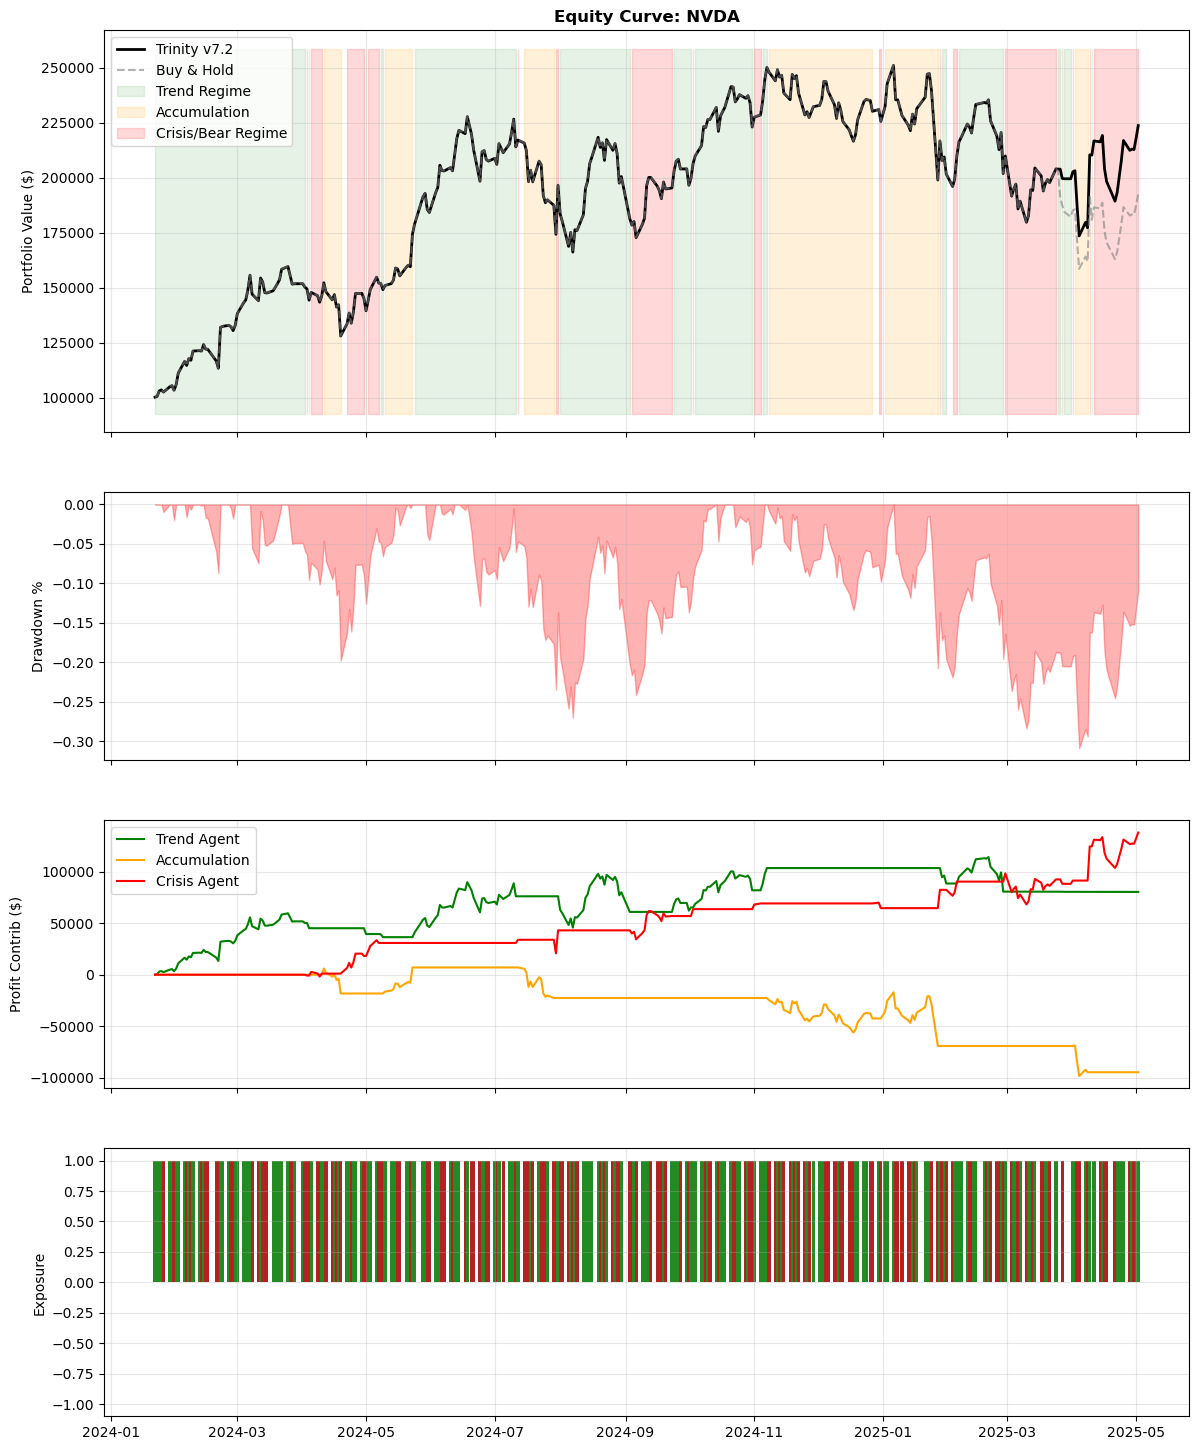

In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7.2) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31",
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), # Volmageddon
        ("2020-01-01", "2020-05-01"), # COVID
        ("2022-01-01", "2022-12-31"), # Bear
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # Fixed Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 64,
    "TRAINING_STEPS": 50000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    "ACTION_SCALER": 5.0,
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR (v7.2 Update: RSI Added) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / df['tr_s'])
        df['di_minus'] = 100 * (df['dm_s'] / df['tr_s'])
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'])
        df['adx'] = df['dx'].rolling(window).mean()
        
        # Mean Reversion Features
        sma = df[target].rolling(20).mean()
        std = df[target].rolling(20).std()
        df['bb_width'] = (std * 2 * 2) / sma
        df['pct_b'] = (df[target] - (sma - 2*std)) / (4*std)
        
        # RSI (New for v7.2)
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Crisis
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # Volatility
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7.2 Update: Anti-Index Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_rsi = self.cols.index('rsi') if 'rsi' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        rsi = self.data[self.current_step, self.idx_rsi] if self.idx_rsi != -1 else 50
        
        reward = 0
        if self.mode == 'trend':
            reward = act * ret * 100
            if self.idx_sma != -1:
                sma_dist = self.data[self.current_step, self.idx_sma]
                # Reward conviction in trend
                if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
                elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
                
        elif self.mode == 'accumulation': 
            # v7.2: KILL THE CLOSET INDEXER
            # 1. Base PnL
            reward = act * ret * 100
            
            # 2. The Holding Tax: Penalize holding meaningful exposure
            # This forces the agent to only enter when it's VERY confident
            reward -= 0.05 * abs(act) 
            
            # 3. Explicit Mean Reversion Incentives
            if rsi < 30 and act > 0.5: reward += 0.5 # Buy Oversold
            if rsi > 70 and act < -0.5: reward += 0.5 # Sell Overbought
            
            # 4. Boredom Penalty (Optional but good):
            # If agent just sits at 0.0 or 1.0, it gets no extra points.

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01 and act < -0.1: reward *= 2.0 
            elif ret < -0.01 and act > 0.1: reward -= (act * 10.0) 
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7.2 Logic) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print("\n=== 1. TRAINING SPECIALIST AGENTS (v7.2) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        # 1. Trend
        env_trend = DummyVecEnv([lambda: TradingEnv(trend_data, self.config, mode='trend')])
        env_trend = VecNormalize(env_trend, norm_obs=True, norm_reward=False)
        model_trend = PPO("MlpPolicy", env_trend, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_trend.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['trend'] = model_trend
        self.envs['trend'] = env_trend
        
        # 2. Accumulation
        env_acc = DummyVecEnv([lambda: TradingEnv(trend_data, self.config, mode='accumulation')]) 
        env_acc = VecNormalize(env_acc, norm_obs=True, norm_reward=False)
        model_acc = PPO("MlpPolicy", env_acc, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_acc.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['accumulation'] = model_acc
        self.envs['accumulation'] = env_acc
        
        # 3. Crisis
        crash_data = self.dp.get_crisis_data()
        env_crisis = DummyVecEnv([lambda: TradingEnv(crash_data, self.config, mode='crisis')])
        env_crisis = VecNormalize(env_crisis, norm_obs=True, norm_reward=False)
        model_crisis = PPO("MlpPolicy", env_crisis, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_crisis.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['crisis'] = model_crisis
        self.envs['crisis'] = env_crisis
        
        if verbose: print("=== TRAINING COMPLETE ===\n")

    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        if plot_results: print(f"=== 2. RUNNING BACKTEST ({s_date} to {e_date}) | Target: {self.config['TARGET_ASSET']} ===")
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return 0.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return 0.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        regime_stats = {
            'trend': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0},
            'accumulation': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0},
            'crisis': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0}
        }
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        agent_pnls = {'trend': 0.0, 'accumulation': 0.0, 'crisis': 0.0}
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            
            # --- DYNAMIC THRESHOLDS FROM CONFIG ---
            JUMP_THRESH = self.config['JUMP_THRESHOLD']
            ADX_THRESH = self.config['ADX_THRESHOLD']
            
            is_bullish_jump = (l_stat > JUMP_THRESH)
            is_bearish_jump = (l_stat < -JUMP_THRESH)
            is_extreme_vol = (vol_pct > 0.90)
            is_crash = (sma_dist < -0.05) # Loose Definition
            is_bull_trend = (adx > ADX_THRESH) and (di_plus > di_minus)
            is_bear_trend = (adx > ADX_THRESH) and (di_minus > di_plus)
            
            # --- GATING LOGIC (v7.2 Refined) ---
            # Priority 1: Instantaneous Jumps (High Conviction)
            if is_bearish_jump:
                regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump:
                regime, active_agent_name = "JUMP_BULL", "trend"
                
            # Priority 2: Volatility & Structure (The "Melt-up" vs "Crash" Fix)
            elif is_extreme_vol:
                if sma_dist < 0:
                    regime, active_agent_name = "CRISIS_PANIC", "crisis"
                else:
                    regime, active_agent_name = "MANIA_MODE", "trend" # High Vol + Above SMA = Meltup
                
            # Priority 3: Trend vs Chop
            elif is_bear_trend:
                regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: 
                regime, active_agent_name = "TREND", "trend"
            else:
                regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            # Exec
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- OVERRIDES (v7.2 Tuned) ---
            
            # Force Aggression on Bull Jump
            if regime == 'JUMP_BULL':
                raw_action = 1.0
            
            # Trend Override: More conservative. 
            # Only force long if sma > 0 AND price isn't totally collapsing short term
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0:
                    # If falling knife (return < -2%), trust the agent's hesitation
                    if mkt_ret > -0.02: 
                        raw_action = 0.5 
                
            # Accumulation Override: REMOVED.
            # We now trust the Accumulation Agent because we fixed its Reward Function.
            # It will naturally swing trade now.
            
            # Vol Targeting
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.1, 2.0)
            
            scaled_action = raw_action * self.config['ACTION_SCALER'] * vol_scaler
            
            # Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            
            print("\n=== AGENT PERFORMANCE BREAKDOWN (vs Benchmark in same period) ===")
            print(f"{'Agent':<12} | {'Days':<6} | {'Agent Ret':<12} | {'Bench Ret':<12} | {'Alpha':<12}")
            print("-" * 65)
            for agent_name, stats in regime_stats.items():
                if stats['days'] > 0:
                    agent_ret = np.exp(stats['log_ret']) - 1
                    bench_ret = np.exp(stats['bench_log_ret']) - 1
                    alpha = agent_ret - bench_ret
                    print(f"{agent_name:<12} | {stats['days']:<6} | {agent_ret:>11.2%} | {bench_ret:>11.2%} | {alpha:>11.2%}")
                else:
                    print(f"{agent_name:<12} | {0:<6} | {'N/A':>11} | {'N/A':>11} | {'0.00%':>11}")
            print("-" * 65)
            
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.2', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        
        y_min, y_max = ax0.get_ylim()
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'trend'), color='green', alpha=0.1, label='Trend Regime')
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'accumulation'), color='orange', alpha=0.15, label='Accumulation')
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'crisis'), color='red', alpha=0.15, label='Crisis/Bear Regime')
        ax0.legend(loc='upper left', frameon=True)

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        print(">>> OPTIMIZATION MODE: SMART GRID (Train once per Window, Backtest many) <<<")
        
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    # Safety Defaults
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 
        config['ACTION_SCALER'] = 5.0 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.2 (FINAL) <<<")
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["NVDA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "NVDA"
    START = "2024-01-22"
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=False)


>>> INITIALIZING TRINITY V7.2 (FINAL) <<<

=== 1. TRAINING SPECIALIST AGENTS (v7.2) ===
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
=== TRAINING COMPLETE ===

=== 2. RUNNING BACKTEST (2024-12-12 to 2025-12-12) | Target: TSLA ===
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2023-12-13 to 2025-12-12)
Date         | Regime       | Active Agent | Raw Act  | Scale Act  | Portfolio  | Bench      | Daily Alpha
------------------------------------------------------------------------------------------------------------------------
2024-12-26   | TREND        | trend        | 0.33     | 1.00       | 106858     | 106912     |        0 bps
2025-01-28   | ACCUMULATION | accumulation | 0.35     | 1.00       | 93151      | 93719      

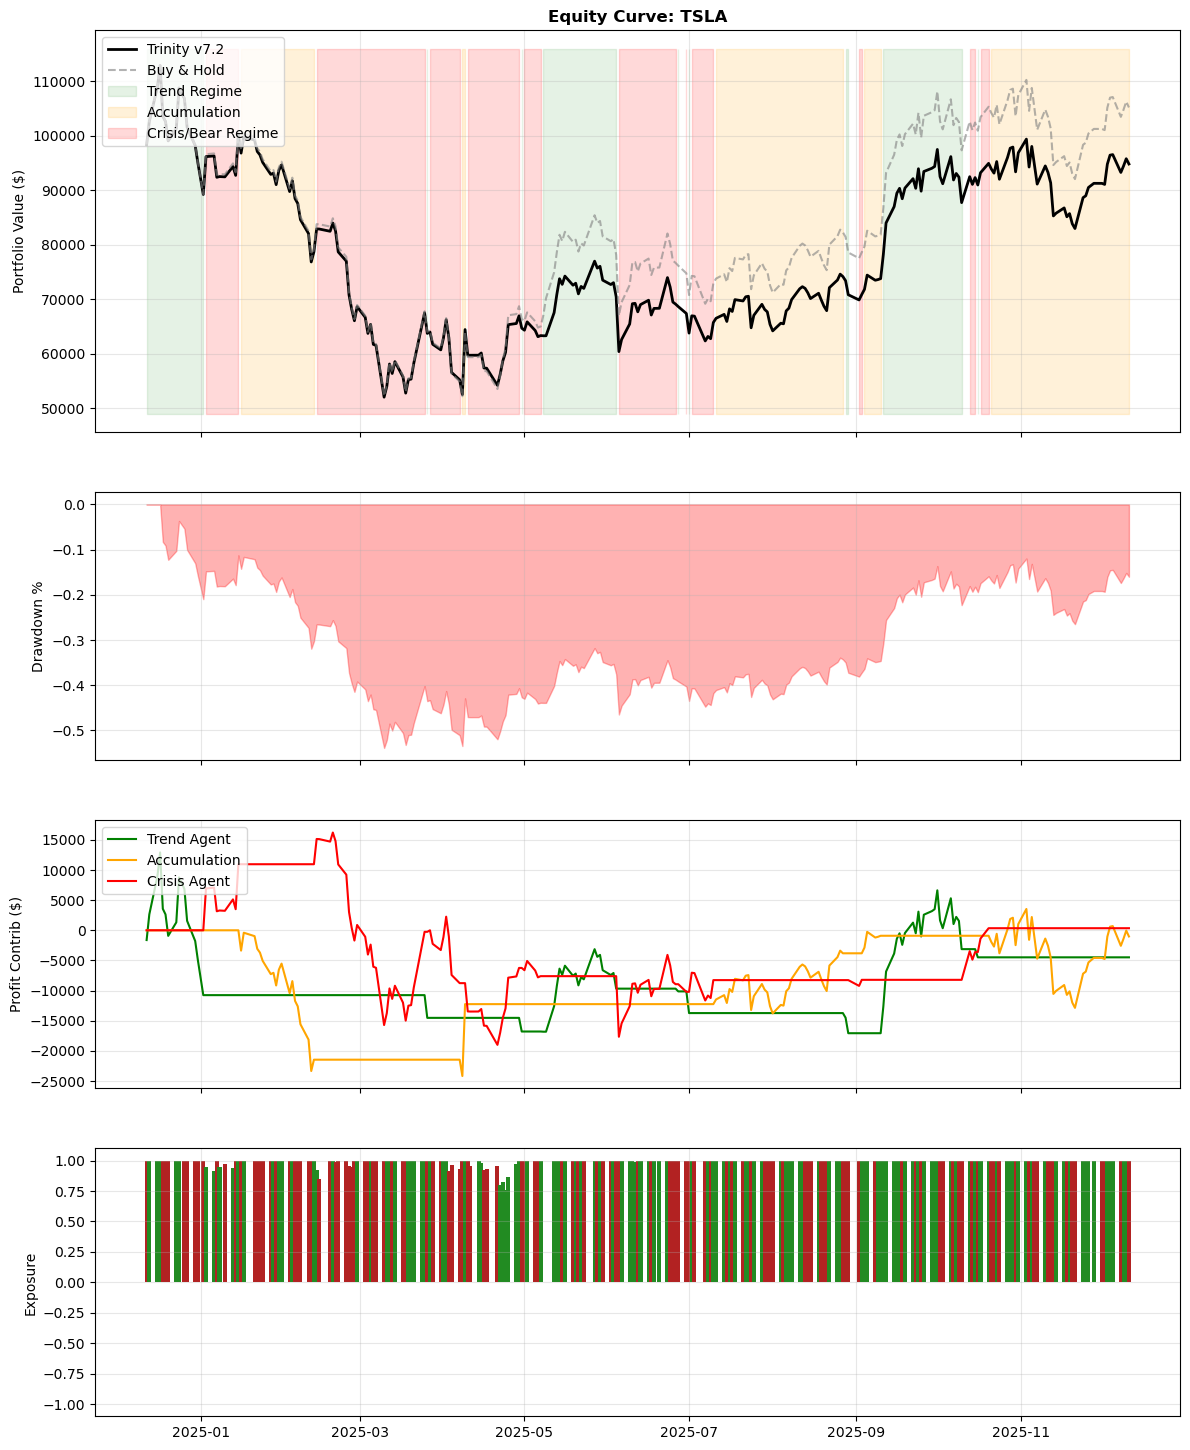

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7.2) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31",
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), # Volmageddon
        ("2020-01-01", "2020-05-01"), # COVID
        ("2022-01-01", "2022-12-31"), # Bear
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # Fixed Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 64,
    "TRAINING_STEPS": 50000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    "ACTION_SCALER": 5.0,
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR (v7.2 Update: RSI Added) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / df['tr_s'])
        df['di_minus'] = 100 * (df['dm_s'] / df['tr_s'])
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'])
        df['adx'] = df['dx'].rolling(window).mean()
        
        # Mean Reversion Features
        sma = df[target].rolling(20).mean()
        std = df[target].rolling(20).std()
        df['bb_width'] = (std * 2 * 2) / sma
        df['pct_b'] = (df[target] - (sma - 2*std)) / (4*std)
        
        # RSI (New for v7.2)
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Crisis
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # Volatility
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7.2 Update: Anti-Index Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_rsi = self.cols.index('rsi') if 'rsi' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        rsi = self.data[self.current_step, self.idx_rsi] if self.idx_rsi != -1 else 50
        
        reward = 0
        if self.mode == 'trend':
            reward = act * ret * 100
            if self.idx_sma != -1:
                sma_dist = self.data[self.current_step, self.idx_sma]
                # Reward conviction in trend
                if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
                elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
                
        elif self.mode == 'accumulation': 
            # v7.2: KILL THE CLOSET INDEXER
            # 1. Base PnL
            reward = act * ret * 100
            
            # 2. The Holding Tax: Penalize holding meaningful exposure
            # This forces the agent to only enter when it's VERY confident
            reward -= 0.05 * abs(act) 
            
            # 3. Explicit Mean Reversion Incentives
            if rsi < 30 and act > 0.5: reward += 0.5 # Buy Oversold
            if rsi > 70 and act < -0.5: reward += 0.5 # Sell Overbought
            
            # 4. Boredom Penalty (Optional but good):
            # If agent just sits at 0.0 or 1.0, it gets no extra points.

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01 and act < -0.1: reward *= 2.0 
            elif ret < -0.01 and act > 0.1: reward -= (act * 10.0) 
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7.2 Logic) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print("\n=== 1. TRAINING SPECIALIST AGENTS (v7.2) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        # 1. Trend
        env_trend = DummyVecEnv([lambda: TradingEnv(trend_data, self.config, mode='trend')])
        env_trend = VecNormalize(env_trend, norm_obs=True, norm_reward=False)
        model_trend = PPO("MlpPolicy", env_trend, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_trend.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['trend'] = model_trend
        self.envs['trend'] = env_trend
        
        # 2. Accumulation
        env_acc = DummyVecEnv([lambda: TradingEnv(trend_data, self.config, mode='accumulation')]) 
        env_acc = VecNormalize(env_acc, norm_obs=True, norm_reward=False)
        model_acc = PPO("MlpPolicy", env_acc, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_acc.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['accumulation'] = model_acc
        self.envs['accumulation'] = env_acc
        
        # 3. Crisis
        crash_data = self.dp.get_crisis_data()
        env_crisis = DummyVecEnv([lambda: TradingEnv(crash_data, self.config, mode='crisis')])
        env_crisis = VecNormalize(env_crisis, norm_obs=True, norm_reward=False)
        model_crisis = PPO("MlpPolicy", env_crisis, verbose=0, learning_rate=self.config['LEARNING_RATE'])
        model_crisis.learn(total_timesteps=self.config['TRAINING_STEPS'])
        self.agents['crisis'] = model_crisis
        self.envs['crisis'] = env_crisis
        
        if verbose: print("=== TRAINING COMPLETE ===\n")

    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        if plot_results: print(f"=== 2. RUNNING BACKTEST ({s_date} to {e_date}) | Target: {self.config['TARGET_ASSET']} ===")
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return 0.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return 0.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        regime_stats = {
            'trend': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0},
            'accumulation': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0},
            'crisis': {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0}
        }
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        agent_pnls = {'trend': 0.0, 'accumulation': 0.0, 'crisis': 0.0}
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            
            # --- DYNAMIC THRESHOLDS FROM CONFIG ---
            JUMP_THRESH = self.config['JUMP_THRESHOLD']
            ADX_THRESH = self.config['ADX_THRESHOLD']
            
            is_bullish_jump = (l_stat > JUMP_THRESH)
            is_bearish_jump = (l_stat < -JUMP_THRESH)
            is_extreme_vol = (vol_pct > 0.90)
            is_crash = (sma_dist < -0.05) # Loose Definition
            is_bull_trend = (adx > ADX_THRESH) and (di_plus > di_minus)
            is_bear_trend = (adx > ADX_THRESH) and (di_minus > di_plus)
            
            # --- GATING LOGIC (v7.2 Refined) ---
            # Priority 1: Instantaneous Jumps (High Conviction)
            if is_bearish_jump:
                regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump:
                regime, active_agent_name = "JUMP_BULL", "trend"
                
            # Priority 2: Volatility & Structure (The "Melt-up" vs "Crash" Fix)
            elif is_extreme_vol:
                if sma_dist < 0:
                    regime, active_agent_name = "CRISIS_PANIC", "crisis"
                else:
                    regime, active_agent_name = "MANIA_MODE", "trend" # High Vol + Above SMA = Meltup
                
            # Priority 3: Trend vs Chop
            elif is_bear_trend:
                regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: 
                regime, active_agent_name = "TREND", "trend"
            else:
                regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            # Exec
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- OVERRIDES (v7.2 Tuned) ---
            
            # Force Aggression on Bull Jump
            if regime == 'JUMP_BULL':
                raw_action = 1.0
            
            # Trend Override: More conservative. 
            # Only force long if sma > 0 AND price isn't totally collapsing short term
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0:
                    # If falling knife (return < -2%), trust the agent's hesitation
                    if mkt_ret > -0.02: 
                        raw_action = 0.5 
                
            # Accumulation Override: REMOVED.
            # We now trust the Accumulation Agent because we fixed its Reward Function.
            # It will naturally swing trade now.
            
            # Vol Targeting
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.1, 2.0)
            
            scaled_action = raw_action * self.config['ACTION_SCALER'] * vol_scaler
            
            # Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            
            print("\n=== AGENT PERFORMANCE BREAKDOWN (vs Benchmark in same period) ===")
            print(f"{'Agent':<12} | {'Days':<6} | {'Agent Ret':<12} | {'Bench Ret':<12} | {'Alpha':<12}")
            print("-" * 65)
            for agent_name, stats in regime_stats.items():
                if stats['days'] > 0:
                    agent_ret = np.exp(stats['log_ret']) - 1
                    bench_ret = np.exp(stats['bench_log_ret']) - 1
                    alpha = agent_ret - bench_ret
                    print(f"{agent_name:<12} | {stats['days']:<6} | {agent_ret:>11.2%} | {bench_ret:>11.2%} | {alpha:>11.2%}")
                else:
                    print(f"{agent_name:<12} | {0:<6} | {'N/A':>11} | {'N/A':>11} | {'0.00%':>11}")
            print("-" * 65)
            
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.2', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        
        y_min, y_max = ax0.get_ylim()
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'trend'), color='green', alpha=0.1, label='Trend Regime')
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'accumulation'), color='orange', alpha=0.15, label='Accumulation')
        ax0.fill_between(res.index, y_min, y_max, where=(res['Agent'] == 'crisis'), color='red', alpha=0.15, label='Crisis/Bear Regime')
        ax0.legend(loc='upper left', frameon=True)

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        print(">>> OPTIMIZATION MODE: SMART GRID (Train once per Window, Backtest many) <<<")
        
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    # Safety Defaults
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 
        config['ACTION_SCALER'] = 5.0 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.2 (FINAL) <<<")
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["TSLA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "TSLA"
    START = "2024-12-12"
    END = "2025-12-12"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=False)


>>> INITIALIZING TRINITY V7.3 (FINAL) <<<

=== 1. TRAINING SPECIALIST AGENTS (v7.3) ===
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
=== TRAINING COMPLETE ===

=== 2. RUNNING BACKTEST (2024-01-22 to 2025-05-05) | Target: NVDA ===
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2023-01-22 to 2025-05-05)
Date         | Regime       | Active Agent | Raw Act  | Scale Act  | Portfolio  | Bench      | Daily Alpha
------------------------------------------------------------------------------------------------------------------------
2024-02-05   | TREND        | trend        | 0.80     | 0.80       | 113085     | 116542     |      -97 bps
2024-03-05   | TREND        | trend        | 0.84     | 0.84       | 139294     | 144506     

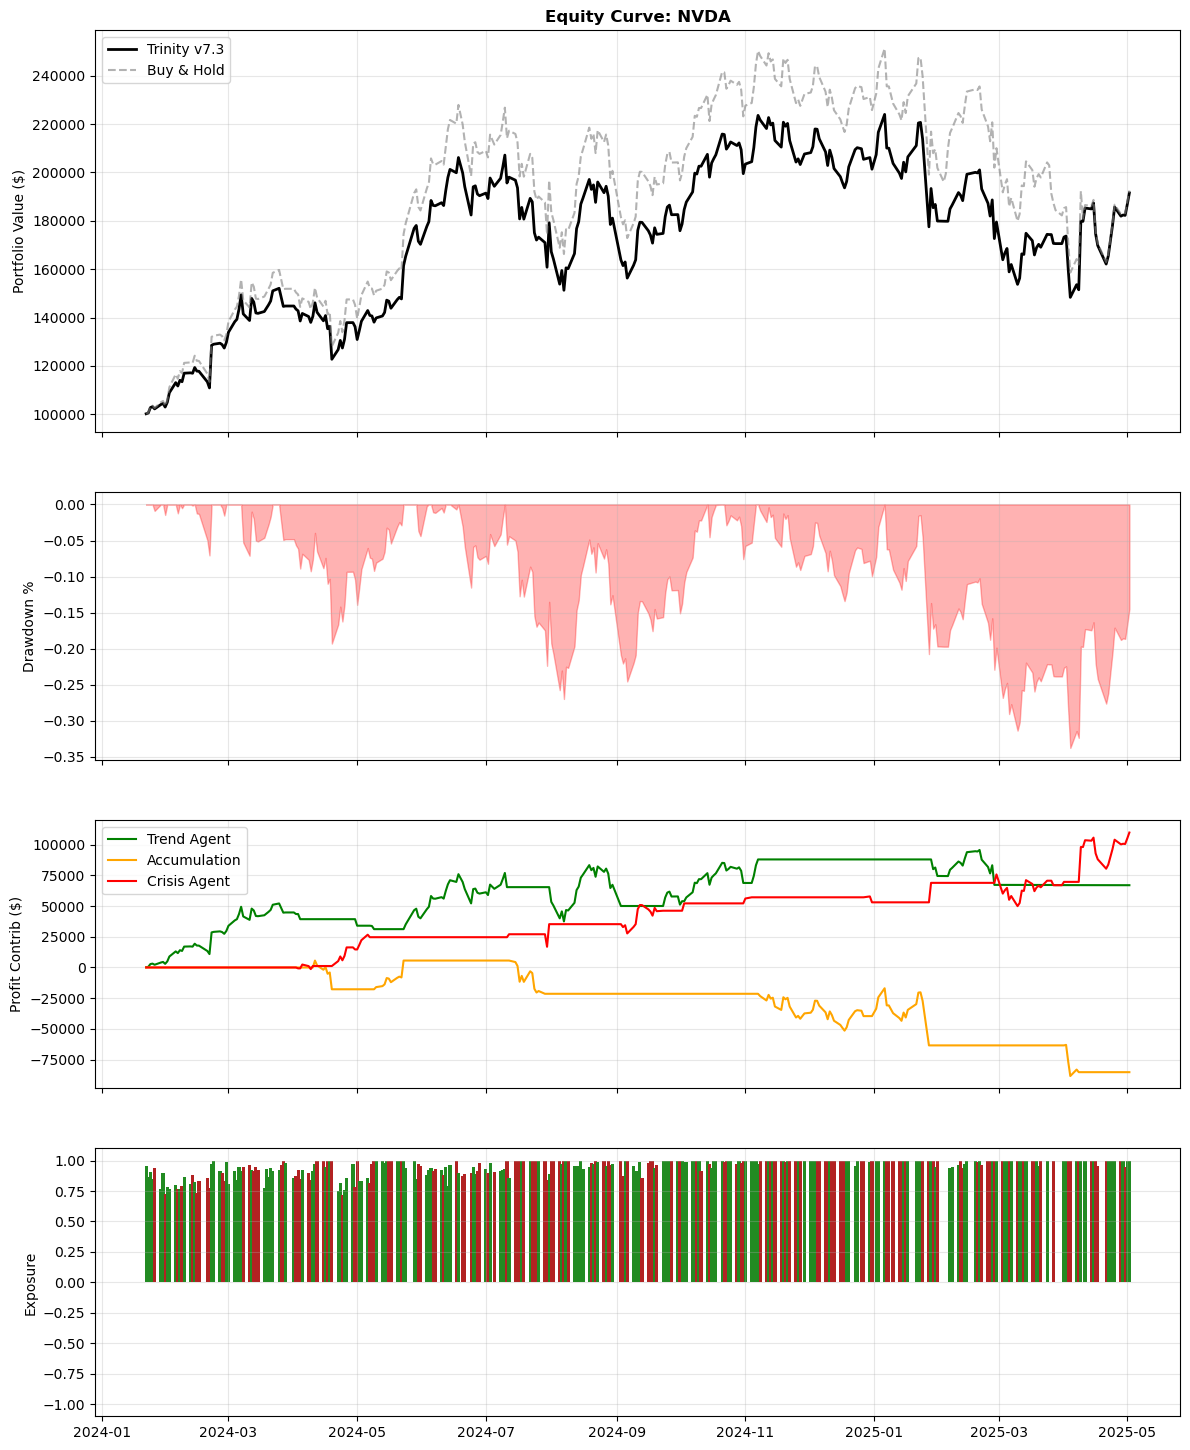

In [15]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7.3) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31",
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods (Regime Specific Data)
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), # Volmageddon
        ("2020-01-01", "2020-05-01"), # COVID
        ("2022-01-01", "2022-12-31"), # Bear
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128, # Increased for stability
    "TRAINING_STEPS": 60000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    
    # Execution Logic - v7.3 Changes
    "ACTION_SCALER": 1.0, # FIXED: Removed artificial multiplier (was 5.0)
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR (v7.3) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend Indicators
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        # Mean Reversion / RSI
        # Used for "Whipsaw Protection" in v7.3
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Crisis Features
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # Volatility Regime
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7.3 - Generalized Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_rsi = self.cols.index('rsi') if 'rsi' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        # Random start helps prevent overfitting to specific dates
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        else:
             self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        rsi = self.data[self.current_step, self.idx_rsi] if self.idx_rsi != -1 else 50
        sma_dist = self.data[self.current_step, self.idx_sma] if self.idx_sma != -1 else 0
        
        reward = 0
        
        # --- 1. TREND AGENT (Smart Trend Following) ---
        if self.mode == 'trend':
            reward = act * ret * 100
            
            # Conviction Bonus: Reward being long in uptrend
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            # v7.3 Whipsaw Protection: Penalize buying the top / selling the bottom
            # This teaches the agent to wait for better entries even in a trend
            if act > 0.5 and rsi > 80:
                reward -= 0.5 # Don't FOMO
            if act < -0.5 and rsi < 20:
                reward -= 0.5 # Don't panic sell
                
        # --- 2. ACCUMULATION AGENT (The Sniper) ---
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            
            # Holding Tax (Retained): Discourages closet indexing
            reward -= 0.05 * abs(act) 
            
            # Explicit Mean Reversion Incentives
            if rsi < 30 and act > 0.5: reward += 0.5 # Buy Oversold
            if rsi > 70 and act < -0.5: reward += 0.5 # Sell Overbought

        # --- 3. CRISIS AGENT (The Hedger) ---
        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            
            # v7.3: Aggression Boost
            # If market crashes (-1%) and agent is short, massive multiplier
            if ret < -0.01:
                if act < -0.1:
                    reward *= 3.0 # Boosted from 2.0 to 3.0
                elif act > 0.1:
                    reward -= (act * 20.0) # Punishment for catching falling knife
            
            # Punishment for timidity during volatility
            # If VIX is high but agent is neutral -> small penalty
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7.3 Execution Logic) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print("\n=== 1. TRAINING SPECIALIST AGENTS (v7.3) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        # Train Agents
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO(
                "MlpPolicy", 
                env, 
                verbose=0, 
                learning_rate=self.config['LEARNING_RATE'],
                batch_size=self.config['BATCH_SIZE']
            )
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
        if verbose: print("=== TRAINING COMPLETE ===\n")

    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        if plot_results: print(f"=== 2. RUNNING BACKTEST ({s_date} to {e_date}) | Target: {self.config['TARGET_ASSET']} ===")
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return 0.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return 0.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            # Features
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            
            # --- GATING LOGIC (v7.3 Standardized) ---
            # 1. Jumps (Immediate Reaction)
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            
            # 2. Structural (Regime)
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump:
                regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump:
                regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist < -0.05: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                else: regime, active_agent_name = "MANIA_MODE", "trend"
            elif is_bear_trend:
                regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: 
                regime, active_agent_name = "TREND", "trend"
            else:
                regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- EXECUTION LOGIC (v7.3 Confidence Fidelity) ---
            
            # 1. Base Action: Trust the AI's magnitude
            # Removed the 5.0 scalar. If AI says 0.3, we use 0.3.
            
            # 2. Overrides (Minimal)
            if regime == 'JUMP_BULL': raw_action = 1.0
            
            # Trend Override: More conservative
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0:
                     if mkt_ret > -0.02: raw_action = 0.5 
            
            # 3. Volatility Sizing (Risk Management)
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5) # Cap at 1.5x leverage
            
            # 4. Final Calculation
            # We multiply raw_action (conviction) * vol_scaler (risk)
            scaled_action = raw_action * vol_scaler
            
            # 5. Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.3', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    # Safety Defaults
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.3 (FINAL) <<<")
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["NVDA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "NVDA"
    START = "2024-01-22"
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=False)


>>> INITIALIZING TRINITY V7.3 (FINAL) <<<

=== 1. TRAINING SPECIALIST AGENTS (v7.3) ===
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
=== TRAINING COMPLETE ===

=== 2. RUNNING BACKTEST (2024-12-12 to 2025-12-12) | Target: TSLA ===
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2023-12-13 to 2025-12-12)
Date         | Regime       | Active Agent | Raw Act  | Scale Act  | Portfolio  | Bench      | Daily Alpha
------------------------------------------------------------------------------------------------------------------------
2024-12-26   | TREND        | trend        | 0.21     | 0.21       | 101353     | 106912     |      139 bps
2025-01-28   | ACCUMULATION | accumulation | 0.21     | 0.21       | 98403      | 93719      

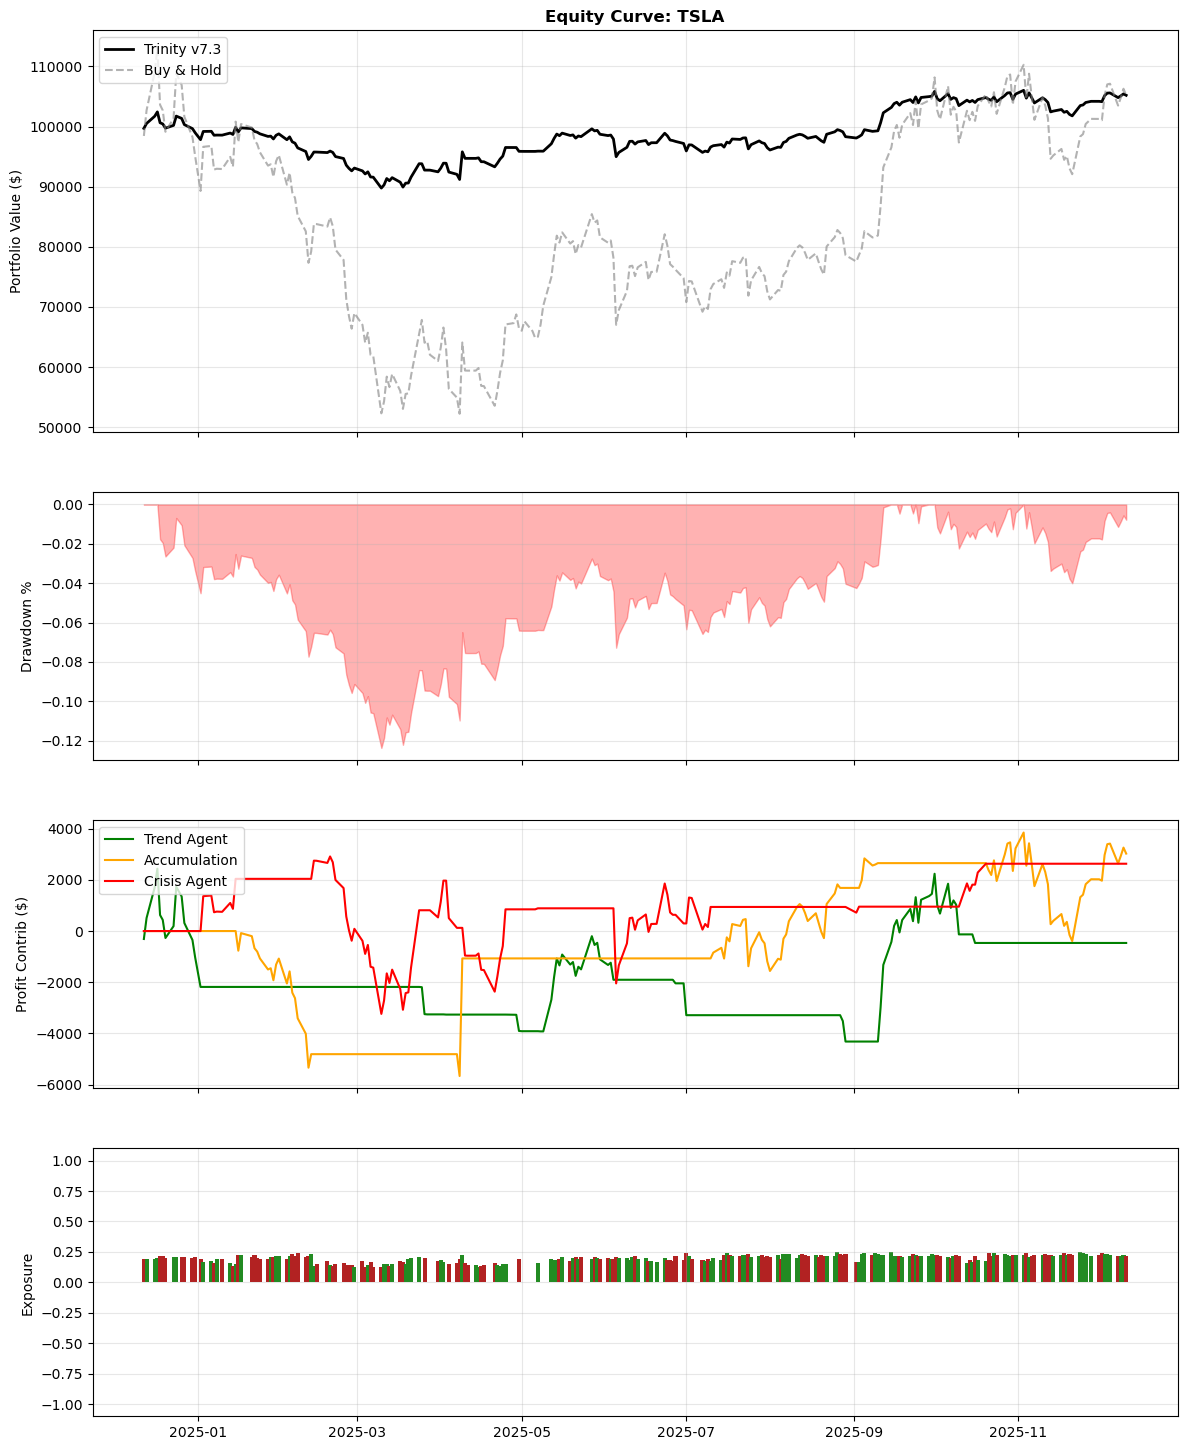

In [16]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7.3) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31",
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods (Regime Specific Data)
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), # Volmageddon
        ("2020-01-01", "2020-05-01"), # COVID
        ("2022-01-01", "2022-12-31"), # Bear
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128, # Increased for stability
    "TRAINING_STEPS": 60000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    
    # Execution Logic - v7.3 Changes
    "ACTION_SCALER": 1.0, # FIXED: Removed artificial multiplier (was 5.0)
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR (v7.3) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend Indicators
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        # Mean Reversion / RSI
        # Used for "Whipsaw Protection" in v7.3
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Crisis Features
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # Volatility Regime
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7.3 - Generalized Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_rsi = self.cols.index('rsi') if 'rsi' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        # Random start helps prevent overfitting to specific dates
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        else:
             self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        rsi = self.data[self.current_step, self.idx_rsi] if self.idx_rsi != -1 else 50
        sma_dist = self.data[self.current_step, self.idx_sma] if self.idx_sma != -1 else 0
        
        reward = 0
        
        # --- 1. TREND AGENT (Smart Trend Following) ---
        if self.mode == 'trend':
            reward = act * ret * 100
            
            # Conviction Bonus: Reward being long in uptrend
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            # v7.3 Whipsaw Protection: Penalize buying the top / selling the bottom
            # This teaches the agent to wait for better entries even in a trend
            if act > 0.5 and rsi > 80:
                reward -= 0.5 # Don't FOMO
            if act < -0.5 and rsi < 20:
                reward -= 0.5 # Don't panic sell
                
        # --- 2. ACCUMULATION AGENT (The Sniper) ---
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            
            # Holding Tax (Retained): Discourages closet indexing
            reward -= 0.05 * abs(act) 
            
            # Explicit Mean Reversion Incentives
            if rsi < 30 and act > 0.5: reward += 0.5 # Buy Oversold
            if rsi > 70 and act < -0.5: reward += 0.5 # Sell Overbought

        # --- 3. CRISIS AGENT (The Hedger) ---
        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            
            # v7.3: Aggression Boost
            # If market crashes (-1%) and agent is short, massive multiplier
            if ret < -0.01:
                if act < -0.1:
                    reward *= 3.0 # Boosted from 2.0 to 3.0
                elif act > 0.1:
                    reward -= (act * 20.0) # Punishment for catching falling knife
            
            # Punishment for timidity during volatility
            # If VIX is high but agent is neutral -> small penalty
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7.3 Execution Logic) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print("\n=== 1. TRAINING SPECIALIST AGENTS (v7.3) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        # Train Agents
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO(
                "MlpPolicy", 
                env, 
                verbose=0, 
                learning_rate=self.config['LEARNING_RATE'],
                batch_size=self.config['BATCH_SIZE']
            )
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
        if verbose: print("=== TRAINING COMPLETE ===\n")

    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        if plot_results: print(f"=== 2. RUNNING BACKTEST ({s_date} to {e_date}) | Target: {self.config['TARGET_ASSET']} ===")
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return 0.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return 0.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            # Features
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            
            # --- GATING LOGIC (v7.3 Standardized) ---
            # 1. Jumps (Immediate Reaction)
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            
            # 2. Structural (Regime)
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump:
                regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump:
                regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist < -0.05: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                else: regime, active_agent_name = "MANIA_MODE", "trend"
            elif is_bear_trend:
                regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: 
                regime, active_agent_name = "TREND", "trend"
            else:
                regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- EXECUTION LOGIC (v7.3 Confidence Fidelity) ---
            
            # 1. Base Action: Trust the AI's magnitude
            # Removed the 5.0 scalar. If AI says 0.3, we use 0.3.
            
            # 2. Overrides (Minimal)
            if regime == 'JUMP_BULL': raw_action = 1.0
            
            # Trend Override: More conservative
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0:
                     if mkt_ret > -0.02: raw_action = 0.5 
            
            # 3. Volatility Sizing (Risk Management)
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5) # Cap at 1.5x leverage
            
            # 4. Final Calculation
            # We multiply raw_action (conviction) * vol_scaler (risk)
            scaled_action = raw_action * vol_scaler
            
            # 5. Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.3', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    # Safety Defaults
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.3 (FINAL) <<<")
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["TSLA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "TSLA"
    START = "2024-12-12"
    END = "2025-12-12"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=False)


>>> INITIALIZING TRINITY V7.4 (FINAL) <<<

=== 1. TRAINING SPECIALIST AGENTS (v7.4) ===
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
=== TRAINING COMPLETE ===

=== 2. RUNNING BACKTEST (2024-01-22 to 2025-05-05) | Target: NVDA ===
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2023-01-22 to 2025-05-05)
Date         | Regime       | Active Agent | Raw Act  | Scale Act  | Portfolio  | Bench      | Daily Alpha
------------------------------------------------------------------------------------------------------------------------
2024-02-05   | TREND        | trend        | 0.81     | 1.00       | 116484     | 116542     |        0 bps
2024-03-05   | TREND        | trend        | 0.91     | 1.00       | 144434     | 144506     

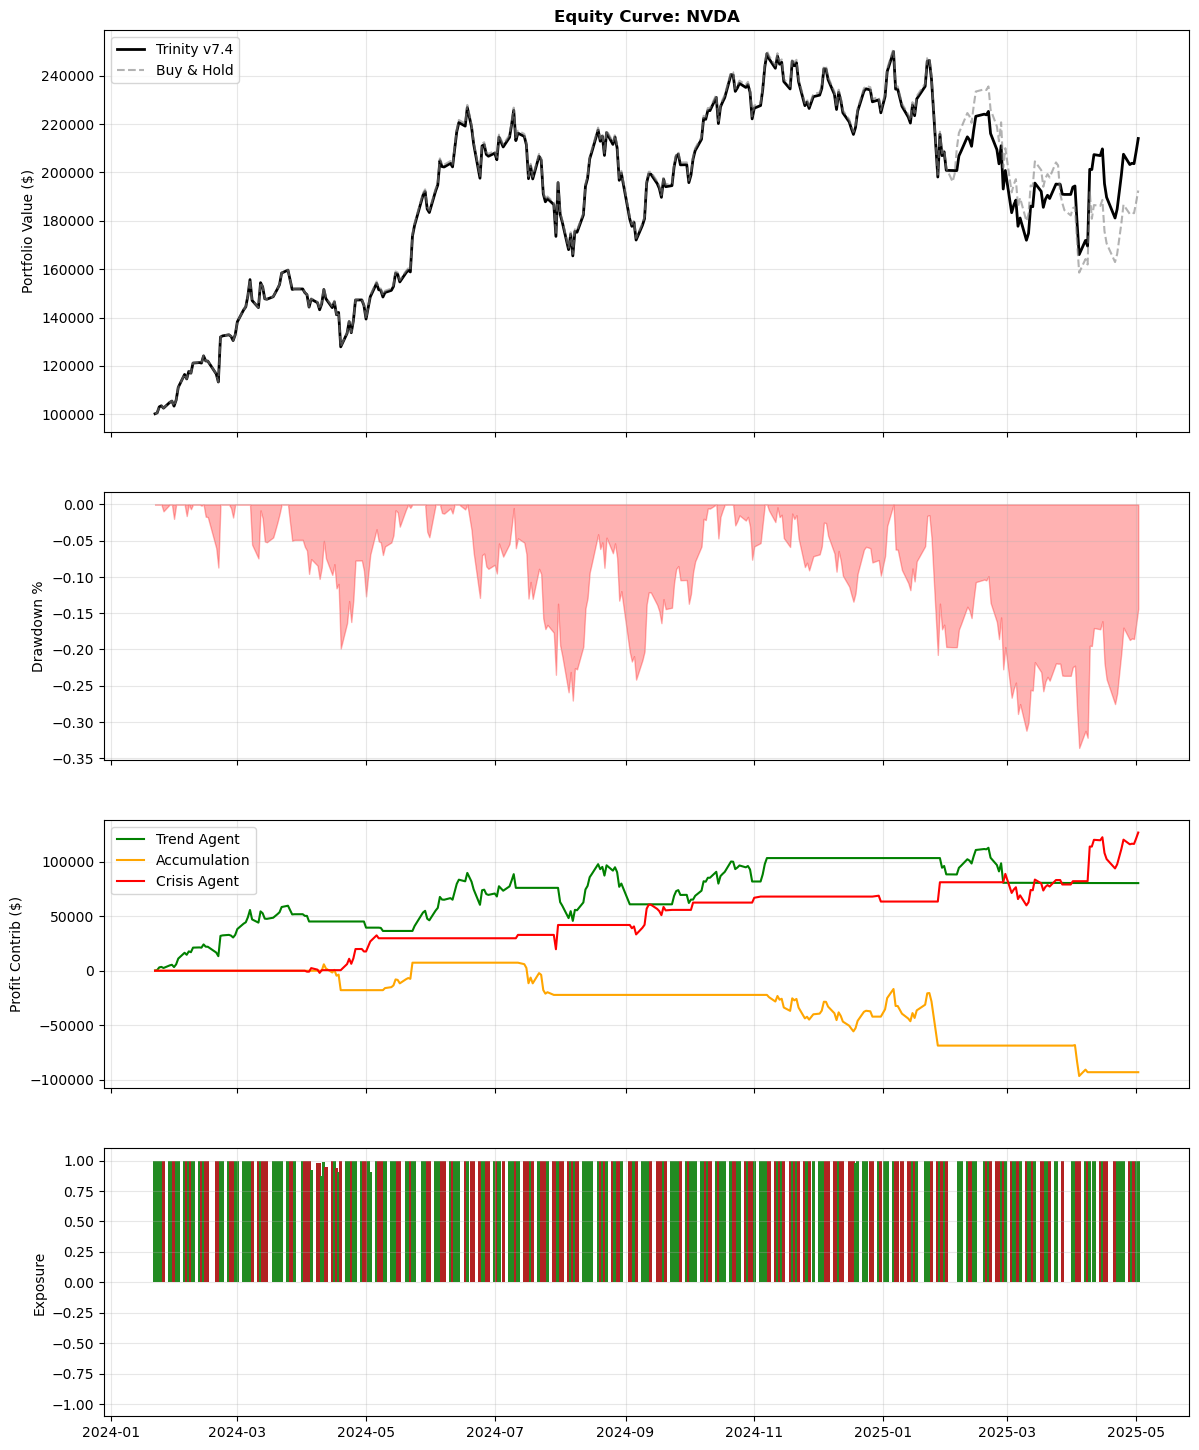

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7.4) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31",
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods (Regime Specific Data)
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), # Volmageddon
        ("2020-01-01", "2020-05-01"), # COVID
        ("2022-01-01", "2022-12-31"), # Bear
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 60000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    
    # Execution Logic - v7.4 Changes
    "ACTION_SCALER": 1.0, # Base scalar, modified dynamically by regime
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR (v7.4) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend Indicators
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        # Mean Reversion / RSI
        # Used for "Whipsaw Protection" in v7.4
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Crisis Features
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # Volatility Regime
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7.4 - Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_rsi = self.cols.index('rsi') if 'rsi' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        # Random start
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        else:
             self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        rsi = self.data[self.current_step, self.idx_rsi] if self.idx_rsi != -1 else 50
        sma_dist = self.data[self.current_step, self.idx_sma] if self.idx_sma != -1 else 0
        
        reward = 0
        
        # --- 1. TREND AGENT ---
        if self.mode == 'trend':
            reward = act * ret * 100
            
            # Conviction Bonus
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            # Whipsaw Protection
            if act > 0.5 and rsi > 80: reward -= 0.5 
            if act < -0.5 and rsi < 20: reward -= 0.5 
                
        # --- 2. ACCUMULATION AGENT ---
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            reward -= 0.05 * abs(act) # Holding Tax
            
            if rsi < 30 and act > 0.5: reward += 0.5 
            if rsi > 70 and act < -0.5: reward += 0.5 

        # --- 3. CRISIS AGENT ---
        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            
            # Aggression Boost on Crashes
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 20.0) 
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7.4 Execution Logic) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print("\n=== 1. TRAINING SPECIALIST AGENTS (v7.4) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        # Train Agents
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO(
                "MlpPolicy", 
                env, 
                verbose=0, 
                learning_rate=self.config['LEARNING_RATE'],
                batch_size=self.config['BATCH_SIZE']
            )
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
        if verbose: print("=== TRAINING COMPLETE ===\n")

    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        if plot_results: print(f"=== 2. RUNNING BACKTEST ({s_date} to {e_date}) | Target: {self.config['TARGET_ASSET']} ===")
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return 0.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return 0.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            # Features
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            
            # --- GATING LOGIC ---
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump:
                regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump:
                regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist < -0.05: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                else: regime, active_agent_name = "MANIA_MODE", "trend"
            elif is_bear_trend:
                regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: 
                regime, active_agent_name = "TREND", "trend"
            else:
                regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- EXECUTION LOGIC (v7.4 Dynamic Regime Scaling) ---
            
            # 1. Regime Scaler: Transmission Gear
            # High Gear for Trend/Mania (Aggressive)
            # Low Gear for Chop/Crisis (Defensive)
            regime_scaler = 1.0
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                regime_scaler = 1.5 
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 1.0 
            elif regime in ['CRISIS_PANIC', 'BEAR_TREND', 'JUMP_BEAR']:
                regime_scaler = 1.0 # Trust Crisis agent, no extra leverage
            
            # 2. Overrides
            if regime == 'JUMP_BULL': raw_action = 1.0
            
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0:
                     if mkt_ret > -0.02: raw_action = 0.5 
            
            # 3. Volatility Sizing
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            # 4. Final Calculation
            # Conviction * Regime Gear * Volatility Check
            scaled_action = raw_action * regime_scaler * vol_scaler
            
            # 5. Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.4', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    # Safety Defaults
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.4 (FINAL) <<<")
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["NVDA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "NVDA"
    START = "2024-01-22"
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=False)


>>> INITIALIZING TRINITY V7.4 (FINAL) <<<

=== 1. TRAINING SPECIALIST AGENTS (v7.4) ===
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
=== TRAINING COMPLETE ===

=== 2. RUNNING BACKTEST (2024-12-12 to 2025-12-12) | Target: TSLA ===
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2023-12-13 to 2025-12-12)
Date         | Regime       | Active Agent | Raw Act  | Scale Act  | Portfolio  | Bench      | Daily Alpha
------------------------------------------------------------------------------------------------------------------------
2024-12-26   | TREND        | trend        | 0.19     | 0.29       | 101708     | 106912     |      125 bps
2025-01-28   | ACCUMULATION | accumulation | 0.22     | 0.22       | 96820      | 93719      

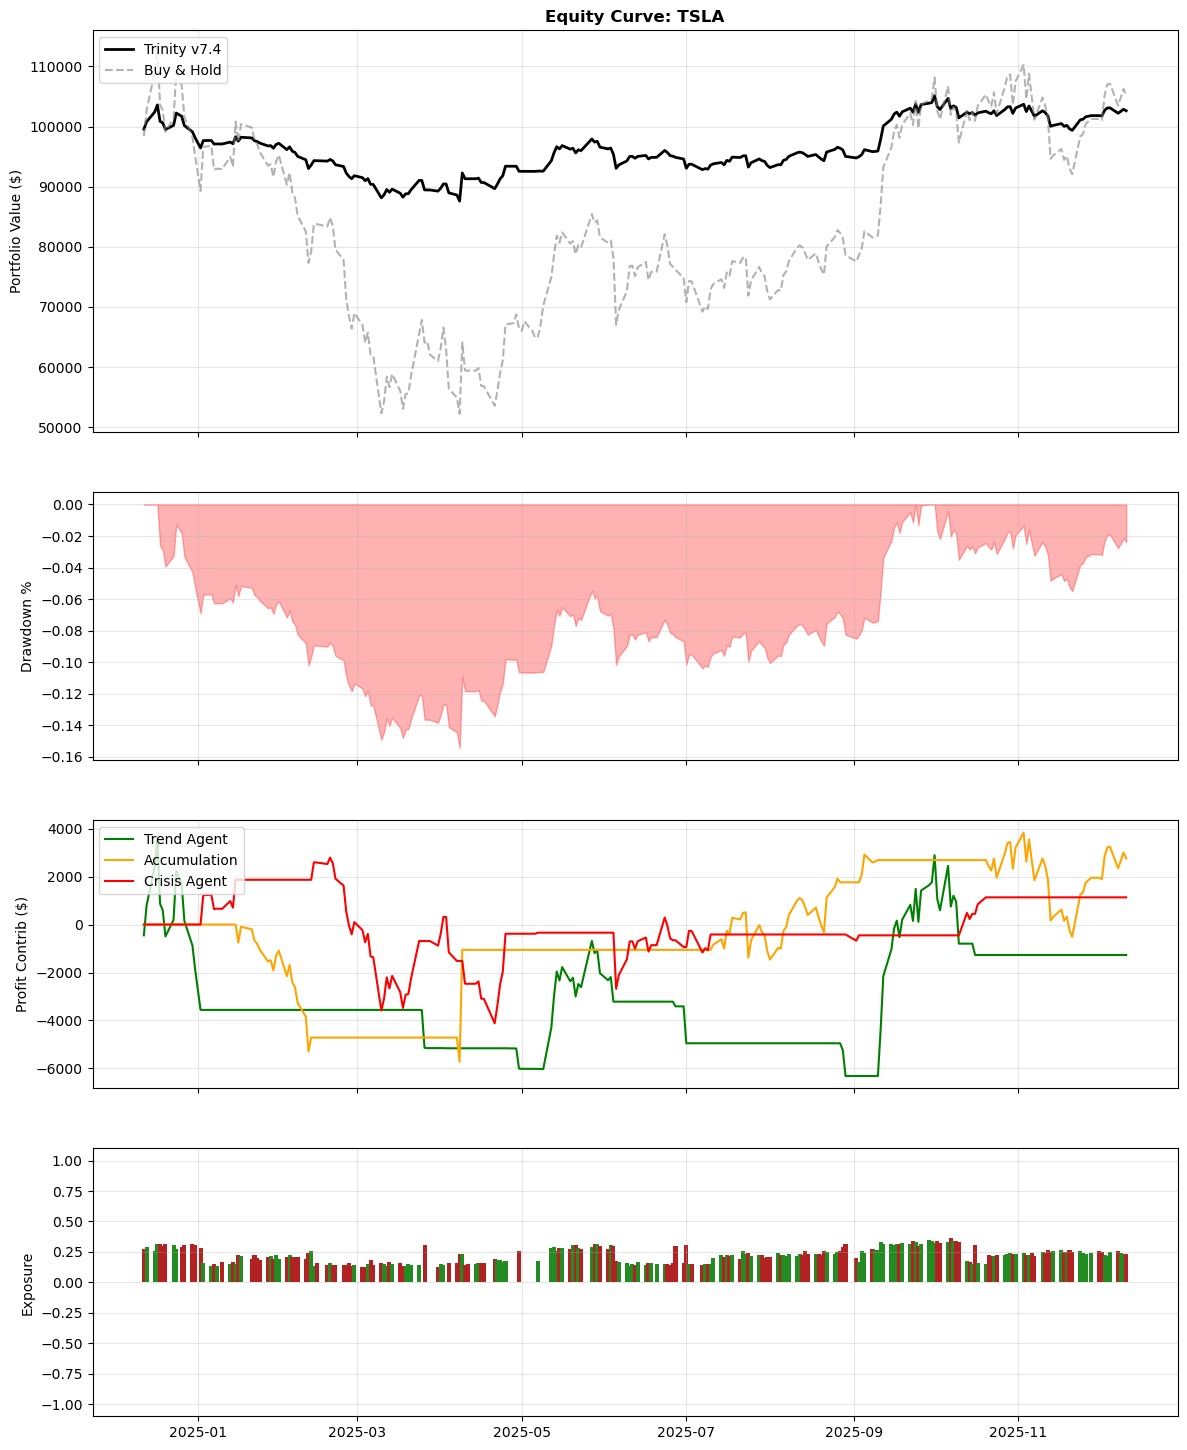

In [20]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7.4) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31",
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods (Regime Specific Data)
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), # Volmageddon
        ("2020-01-01", "2020-05-01"), # COVID
        ("2022-01-01", "2022-12-31"), # Bear
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 60000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    
    # Execution Logic - v7.4 Changes
    "ACTION_SCALER": 1.0, # Base scalar, modified dynamically by regime
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR (v7.4) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend Indicators
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        # Mean Reversion / RSI
        # Used for "Whipsaw Protection" in v7.4
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Crisis Features
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # Volatility Regime
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7.4 - Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_rsi = self.cols.index('rsi') if 'rsi' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        # Random start
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        else:
             self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        rsi = self.data[self.current_step, self.idx_rsi] if self.idx_rsi != -1 else 50
        sma_dist = self.data[self.current_step, self.idx_sma] if self.idx_sma != -1 else 0
        
        reward = 0
        
        # --- 1. TREND AGENT ---
        if self.mode == 'trend':
            reward = act * ret * 100
            
            # Conviction Bonus
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            # Whipsaw Protection
            if act > 0.5 and rsi > 80: reward -= 0.5 
            if act < -0.5 and rsi < 20: reward -= 0.5 
                
        # --- 2. ACCUMULATION AGENT ---
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            reward -= 0.05 * abs(act) # Holding Tax
            
            if rsi < 30 and act > 0.5: reward += 0.5 
            if rsi > 70 and act < -0.5: reward += 0.5 

        # --- 3. CRISIS AGENT ---
        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            
            # Aggression Boost on Crashes
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 20.0) 
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7.4 Execution Logic) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print("\n=== 1. TRAINING SPECIALIST AGENTS (v7.4) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        # Train Agents
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO(
                "MlpPolicy", 
                env, 
                verbose=0, 
                learning_rate=self.config['LEARNING_RATE'],
                batch_size=self.config['BATCH_SIZE']
            )
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
        if verbose: print("=== TRAINING COMPLETE ===\n")

    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        if plot_results: print(f"=== 2. RUNNING BACKTEST ({s_date} to {e_date}) | Target: {self.config['TARGET_ASSET']} ===")
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return 0.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return 0.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            # Features
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            
            # --- GATING LOGIC ---
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump:
                regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump:
                regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist < -0.05: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                else: regime, active_agent_name = "MANIA_MODE", "trend"
            elif is_bear_trend:
                regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: 
                regime, active_agent_name = "TREND", "trend"
            else:
                regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- EXECUTION LOGIC (v7.4 Dynamic Regime Scaling) ---
            
            # 1. Regime Scaler: Transmission Gear
            # High Gear for Trend/Mania (Aggressive)
            # Low Gear for Chop/Crisis (Defensive)
            regime_scaler = 1.0
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                regime_scaler = 1.5 
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 1.0 
            elif regime in ['CRISIS_PANIC', 'BEAR_TREND', 'JUMP_BEAR']:
                regime_scaler = 1.0 # Trust Crisis agent, no extra leverage
            
            # 2. Overrides
            if regime == 'JUMP_BULL': raw_action = 1.0
            
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0:
                     if mkt_ret > -0.02: raw_action = 0.5 
            
            # 3. Volatility Sizing
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            # 4. Final Calculation
            # Conviction * Regime Gear * Volatility Check
            scaled_action = raw_action * regime_scaler * vol_scaler
            
            # 5. Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.4', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    # Safety Defaults
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.4 (FINAL) <<<")
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["TSLA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "TSLA"
    START = "2024-12-12"
    END = "2025-12-12"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=False)


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR TSLA <<<
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 0.98% | Win:60 | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 1.40% | Win:60 | {'ADX_THRESHOLD': 25, 'JUMP_THRESHOLD': 3.5}

>>> BEST PARAMETERS FOUND: {'WINDOW_SIZE': 60, 'ADX_THRESHOLD': 25, 'JUMP_THRESHOLD': 3.5} (Ret: 1.40%) <<<

>>> INITIALIZING TRINITY V7.4 (FINAL) <<<

=== 1. TRAINING SPECIALIST AGENTS (v7.4) ===
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2

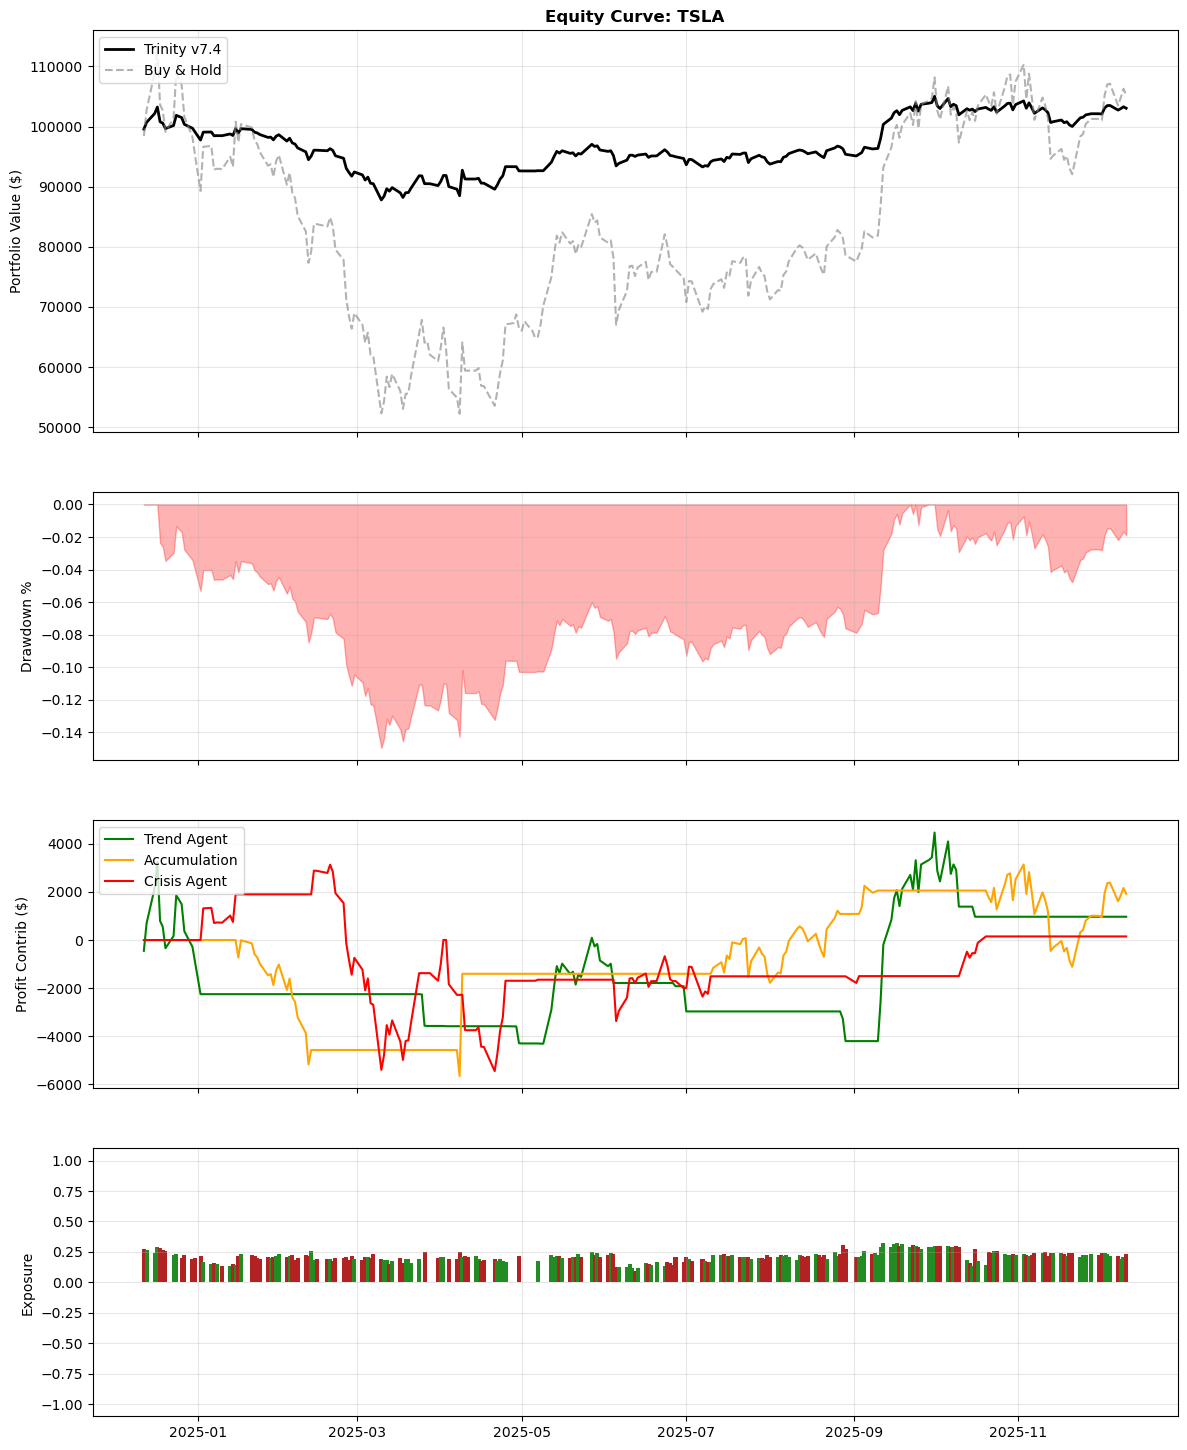

In [21]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7.4) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31",
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods (Regime Specific Data)
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), # Volmageddon
        ("2020-01-01", "2020-05-01"), # COVID
        ("2022-01-01", "2022-12-31"), # Bear
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 60000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    
    # Execution Logic - v7.4 Changes
    "ACTION_SCALER": 1.0, # Base scalar, modified dynamically by regime
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR (v7.4) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend Indicators
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        # Mean Reversion / RSI
        # Used for "Whipsaw Protection" in v7.4
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Crisis Features
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # Volatility Regime
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7.4 - Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_rsi = self.cols.index('rsi') if 'rsi' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        # Random start
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        else:
             self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        rsi = self.data[self.current_step, self.idx_rsi] if self.idx_rsi != -1 else 50
        sma_dist = self.data[self.current_step, self.idx_sma] if self.idx_sma != -1 else 0
        
        reward = 0
        
        # --- 1. TREND AGENT ---
        if self.mode == 'trend':
            reward = act * ret * 100
            
            # Conviction Bonus
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            # Whipsaw Protection
            if act > 0.5 and rsi > 80: reward -= 0.5 
            if act < -0.5 and rsi < 20: reward -= 0.5 
                
        # --- 2. ACCUMULATION AGENT ---
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            reward -= 0.05 * abs(act) # Holding Tax
            
            if rsi < 30 and act > 0.5: reward += 0.5 
            if rsi > 70 and act < -0.5: reward += 0.5 

        # --- 3. CRISIS AGENT ---
        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            
            # Aggression Boost on Crashes
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 20.0) 
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7.4 Execution Logic) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print("\n=== 1. TRAINING SPECIALIST AGENTS (v7.4) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        # Train Agents
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO(
                "MlpPolicy", 
                env, 
                verbose=0, 
                learning_rate=self.config['LEARNING_RATE'],
                batch_size=self.config['BATCH_SIZE']
            )
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
        if verbose: print("=== TRAINING COMPLETE ===\n")

    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        if plot_results: print(f"=== 2. RUNNING BACKTEST ({s_date} to {e_date}) | Target: {self.config['TARGET_ASSET']} ===")
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return 0.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return 0.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            # Features
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            
            # --- GATING LOGIC ---
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump:
                regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump:
                regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist < -0.05: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                else: regime, active_agent_name = "MANIA_MODE", "trend"
            elif is_bear_trend:
                regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: 
                regime, active_agent_name = "TREND", "trend"
            else:
                regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- EXECUTION LOGIC (v7.4 Dynamic Regime Scaling) ---
            
            # 1. Regime Scaler: Transmission Gear
            # High Gear for Trend/Mania (Aggressive)
            # Low Gear for Chop/Crisis (Defensive)
            regime_scaler = 1.0
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                regime_scaler = 1.5 
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 1.0 
            elif regime in ['CRISIS_PANIC', 'BEAR_TREND', 'JUMP_BEAR']:
                regime_scaler = 1.0 # Trust Crisis agent, no extra leverage
            
            # 2. Overrides
            if regime == 'JUMP_BULL': raw_action = 1.0
            
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0:
                     if mkt_ret > -0.02: raw_action = 0.5 
            
            # 3. Volatility Sizing
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            # 4. Final Calculation
            # Conviction * Regime Gear * Volatility Check
            scaled_action = raw_action * regime_scaler * vol_scaler
            
            # 5. Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.4', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    # Safety Defaults
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.4 (FINAL) <<<")
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["TSLA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "TSLA"
    START = "2024-12-12"
    END = "2025-12-12"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)

## v7.5


>>> INITIALIZING TRINITY V7.5 (FINAL) <<<

=== 1. TRAINING SPECIALIST AGENTS (v7.5) ===
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
=== TRAINING COMPLETE ===

=== 2. RUNNING BACKTEST (2024-01-22 to 2025-05-05) | Target: NVDA ===
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2023-01-22 to 2025-05-05)
Date         | Regime       | Active Agent | Raw Act  | Scale Act  | Portfolio  | Bench      | Daily Alpha
------------------------------------------------------------------------------------------------------------------------
2024-02-05   | TREND        | trend        | 0.85     | 1.00       | 116484     | 116542     |        0 bps
2024-03-05   | TREND        | trend        | 0.95     | 1.00       | 144434     | 144506     

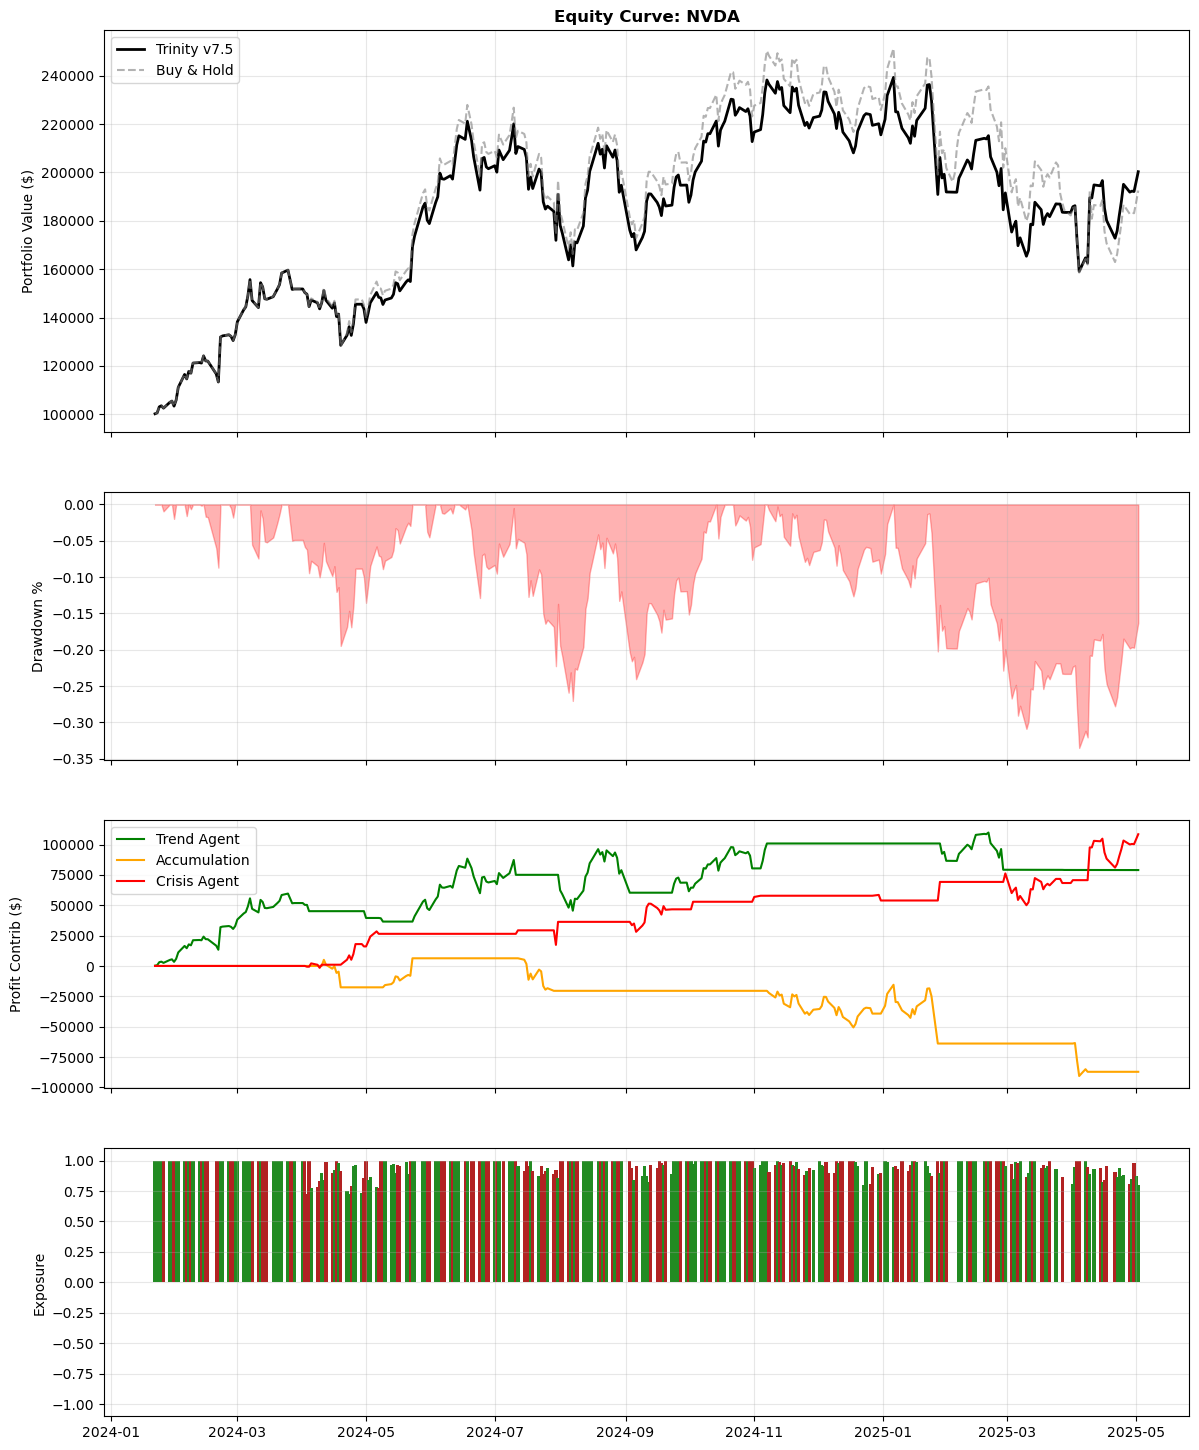

In [22]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7.5) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31",
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods (Regime Specific Data)
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), # Volmageddon
        ("2020-01-01", "2020-05-01"), # COVID
        ("2022-01-01", "2022-12-31"), # Bear
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 60000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    
    # Execution Logic - v7.5 Changes
    "ACTION_SCALER": 1.0, 
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR (v7.5) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend Indicators
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        # Mean Reversion / RSI
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Crisis Features
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # Volatility Regime
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7.5) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_rsi = self.cols.index('rsi') if 'rsi' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        else:
             self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        rsi = self.data[self.current_step, self.idx_rsi] if self.idx_rsi != -1 else 50
        sma_dist = self.data[self.current_step, self.idx_sma] if self.idx_sma != -1 else 0
        
        reward = 0
        
        if self.mode == 'trend':
            reward = act * ret * 100
            # Conviction
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            # Whipsaw Protection
            if act > 0.5 and rsi > 80: reward -= 0.5 
            if act < -0.5 and rsi < 20: reward -= 0.5 
                
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            reward -= 0.05 * abs(act) 
            if rsi < 30 and act > 0.5: reward += 0.5 
            if rsi > 70 and act < -0.5: reward += 0.5 

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 20.0) 
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7.5 Execution Logic) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print("\n=== 1. TRAINING SPECIALIST AGENTS (v7.5) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO("MlpPolicy", env, verbose=0, learning_rate=self.config['LEARNING_RATE'], batch_size=self.config['BATCH_SIZE'])
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
        if verbose: print("=== TRAINING COMPLETE ===\n")

    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        if plot_results: print(f"=== 2. RUNNING BACKTEST ({s_date} to {e_date}) | Target: {self.config['TARGET_ASSET']} ===")
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return 0.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return 0.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            # Features
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            
            # --- GATING LOGIC ---
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist < -0.05: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                else: regime, active_agent_name = "MANIA_MODE", "trend"
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- EXECUTION LOGIC (v7.5 Confidence-Gated Scaling) ---
            
            # 1. Regime Scaler
            regime_scaler = 1.0
            
            # Only boost IF in Trend/Mania AND Agent has High Confidence
            # This protects against "fake trends" in chopped assets (TSLA)
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.5: # AI must already be convinced
                    regime_scaler = 1.5 
                else:
                    regime_scaler = 1.0 # AI is skeptical, don't force it
                    
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 1.0 
            elif regime in ['CRISIS_PANIC', 'BEAR_TREND', 'JUMP_BEAR']:
                regime_scaler = 1.0
            
            # 2. Overrides
            if regime == 'JUMP_BULL': raw_action = 1.0
            
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0:
                     if mkt_ret > -0.02: raw_action = 0.5 
            
            # 3. Volatility Sizing
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            # 4. Final Calculation
            scaled_action = raw_action * regime_scaler * vol_scaler
            
            # 5. Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.5', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    # Safety Defaults
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.5 (FINAL) <<<")
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["NVDA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "NVDA"
    START = "2024-01-22"
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=False)


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR TSLA <<<
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 1.44% | Win:60 | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 1.51% | Win:60 | {'ADX_THRESHOLD': 25, 'JUMP_THRESHOLD': 3.5}

>>> BEST PARAMETERS FOUND: {'WINDOW_SIZE': 60, 'ADX_THRESHOLD': 25, 'JUMP_THRESHOLD': 3.5} (Ret: 1.51%) <<<

>>> INITIALIZING TRINITY V7.5 (FINAL) <<<

=== 1. TRAINING SPECIALIST AGENTS (v7.5) ===
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2

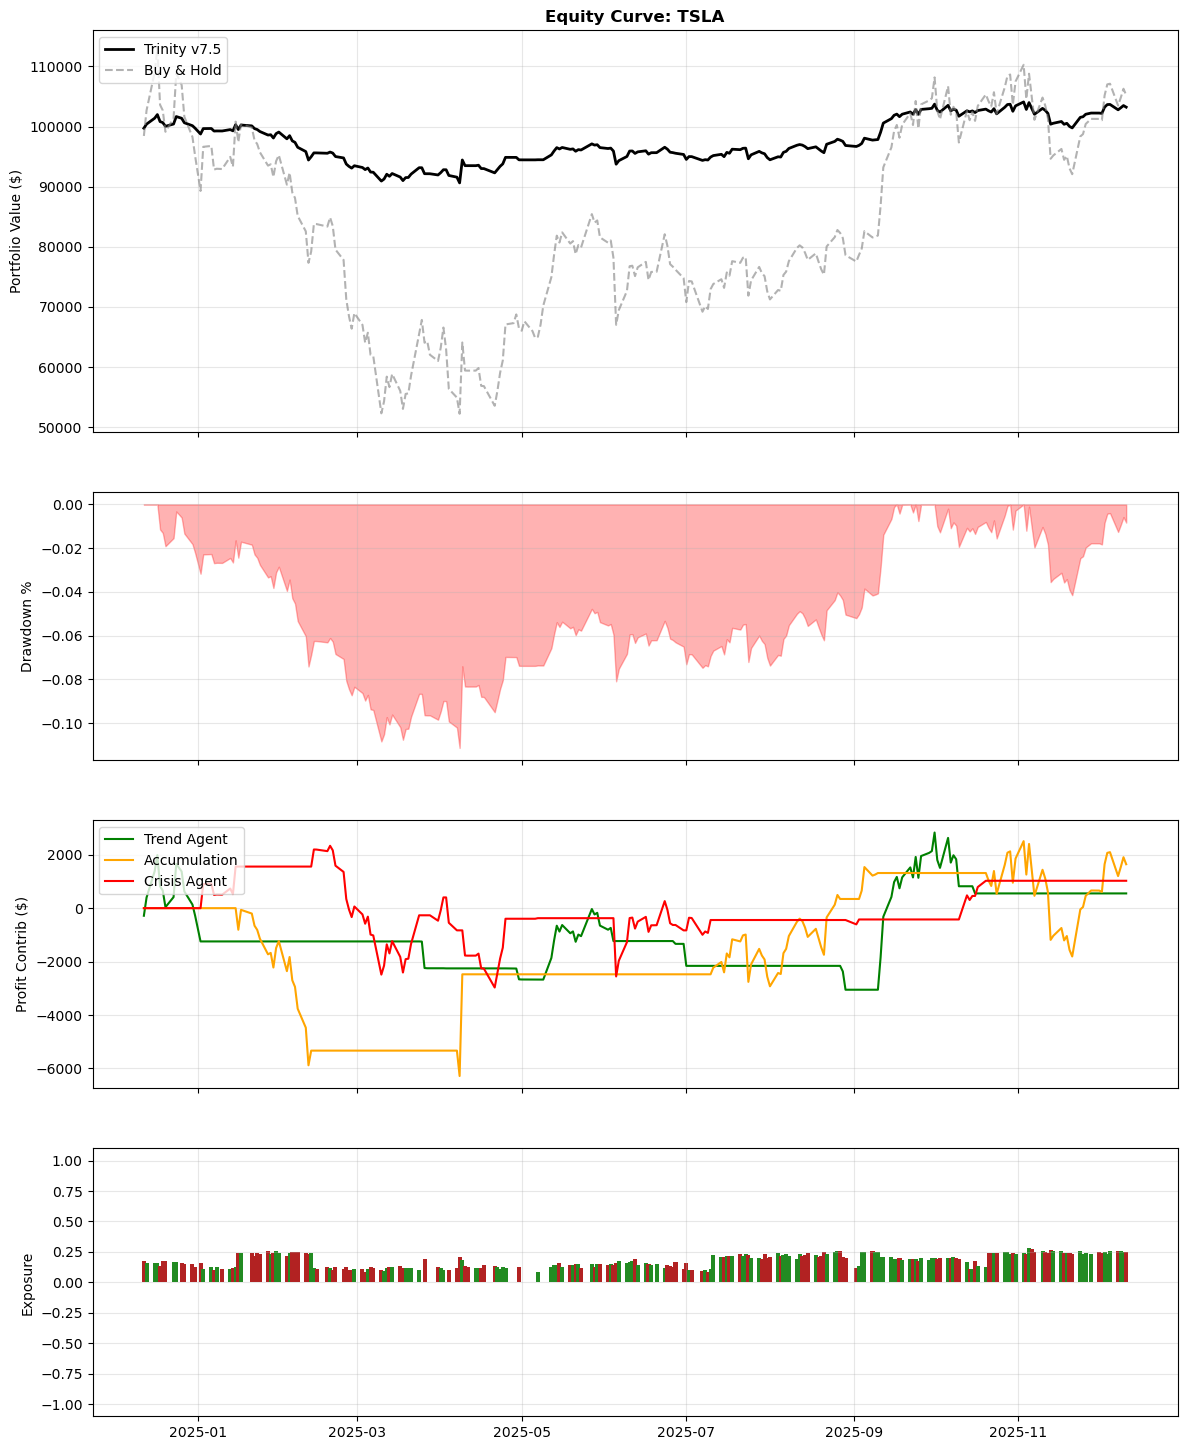

In [24]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7.5) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31",
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods (Regime Specific Data)
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), # Volmageddon
        ("2020-01-01", "2020-05-01"), # COVID
        ("2022-01-01", "2022-12-31"), # Bear
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 60000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    
    # Execution Logic - v7.5 Changes
    "ACTION_SCALER": 1.0, 
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR (v7.5) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend Indicators
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        # Mean Reversion / RSI
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Crisis Features
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # Volatility Regime
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7.5) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_rsi = self.cols.index('rsi') if 'rsi' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        else:
             self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        rsi = self.data[self.current_step, self.idx_rsi] if self.idx_rsi != -1 else 50
        sma_dist = self.data[self.current_step, self.idx_sma] if self.idx_sma != -1 else 0
        
        reward = 0
        
        if self.mode == 'trend':
            reward = act * ret * 100
            # Conviction
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            # Whipsaw Protection
            if act > 0.5 and rsi > 80: reward -= 0.5 
            if act < -0.5 and rsi < 20: reward -= 0.5 
                
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            reward -= 0.05 * abs(act) 
            if rsi < 30 and act > 0.5: reward += 0.5 
            if rsi > 70 and act < -0.5: reward += 0.5 

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 20.0) 
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7.5 Execution Logic) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print("\n=== 1. TRAINING SPECIALIST AGENTS (v7.5) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO("MlpPolicy", env, verbose=0, learning_rate=self.config['LEARNING_RATE'], batch_size=self.config['BATCH_SIZE'])
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
        if verbose: print("=== TRAINING COMPLETE ===\n")

    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        if plot_results: print(f"=== 2. RUNNING BACKTEST ({s_date} to {e_date}) | Target: {self.config['TARGET_ASSET']} ===")
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return 0.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return 0.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            # Features
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            
            # --- GATING LOGIC ---
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist < -0.05: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                else: regime, active_agent_name = "MANIA_MODE", "trend"
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- EXECUTION LOGIC (v7.5 Confidence-Gated Scaling) ---
            
            # 1. Regime Scaler
            regime_scaler = 1.0
            
            # Only boost IF in Trend/Mania AND Agent has High Confidence
            # This protects against "fake trends" in chopped assets (TSLA)
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.5: # AI must already be convinced
                    regime_scaler = 1.5 
                else:
                    regime_scaler = 1.0 # AI is skeptical, don't force it
                    
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 1.0 
            elif regime in ['CRISIS_PANIC', 'BEAR_TREND', 'JUMP_BEAR']:
                regime_scaler = 1.0
            
            # 2. Overrides
            if regime == 'JUMP_BULL': raw_action = 1.0
            
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0:
                     if mkt_ret > -0.02: raw_action = 0.5 
            
            # 3. Volatility Sizing
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            # 4. Final Calculation
            scaled_action = raw_action * regime_scaler * vol_scaler
            
            # 5. Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.5', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    # Safety Defaults
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.5 (FINAL) <<<")
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["TSLA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "TSLA"
    START = "2024-12-12"
    END = "2025-12-12"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)

## v7.6


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR NVDA <<<
>>> OPTIMIZATION MODE: WALK-FORWARD (Validation on last year of training data) <<<
    Training Phase: 2015-01-01 to 2022-12-31
    Validation Phase: 2023-01-01 to 2023-12-31
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2022-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): 49.65% | Win:40 | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): 54.17% | Win:40 | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 4.0}
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): 62.13% | Win:40 | {'ADX_THRESHOLD': 25,

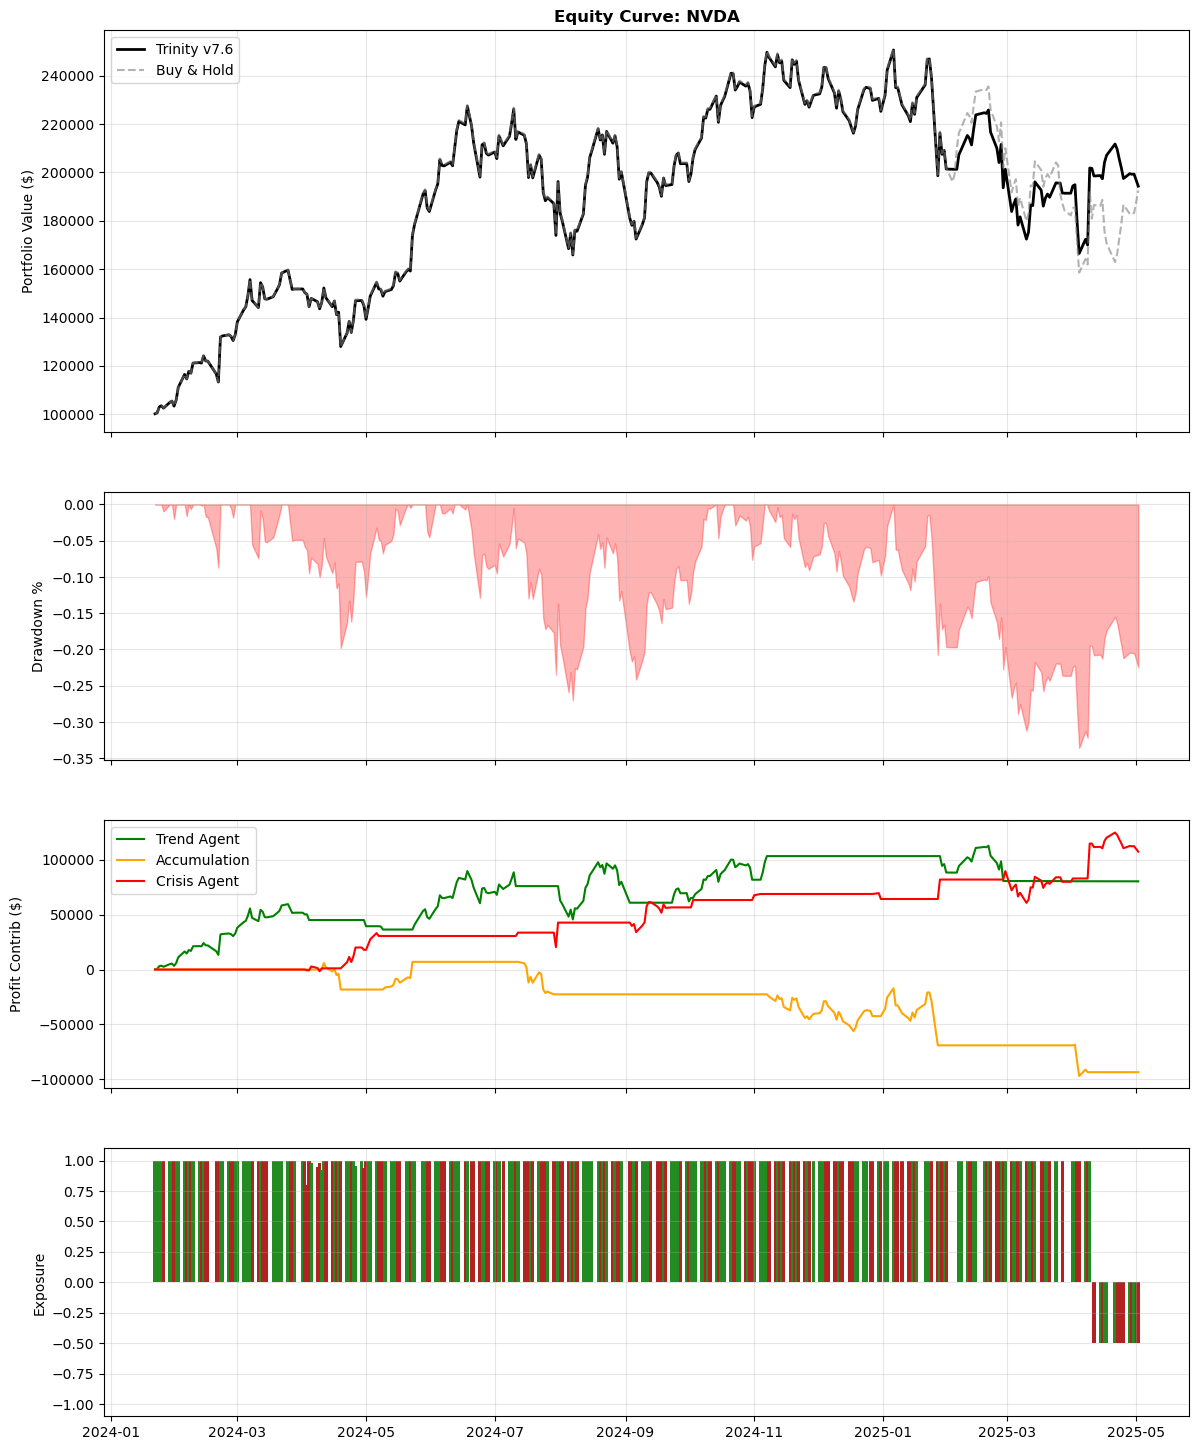

In [27]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7.6) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31", # Optimization runs on the last year of this
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods (Regime Specific Data)
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), # Volmageddon
        ("2020-01-01", "2020-05-01"), # COVID
        ("2022-01-01", "2022-12-31"), # Bear
    ],
    
    # Hyperparameters (Optimizable defaults)
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 60000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    
    # Execution Logic - v7.6 Adaptive
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR (v7.6) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend Indicators
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        # Mean Reversion / RSI
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Crisis Features
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # Volatility Regime
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7.6 - Adaptive Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_rsi = self.cols.index('rsi') if 'rsi' in self.cols else -1
        self.idx_adx = self.cols.index('adx') if 'adx' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        else:
             self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        rsi = self.data[self.current_step, self.idx_rsi] if self.idx_rsi != -1 else 50
        sma_dist = self.data[self.current_step, self.idx_sma] if self.idx_sma != -1 else 0
        adx = self.data[self.current_step, self.idx_adx] if self.idx_adx != -1 else 0
        
        reward = 0
        
        if self.mode == 'trend':
            reward = act * ret * 100
            # Conviction
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            # v7.6 Smart Whipsaw Protection
            # Don't punish buying Overbought if ADX is High (Melt Up)
            # Only punish if Overbought AND ADX is weak/fading (False Breakout)
            if act > 0.5 and rsi > 85:
                if adx < 0.40: # Weak trend + Overbought = Bad
                    reward -= 0.5 
                # If adx > 0.40, no penalty (Melt Up Allowed)
            
            # Don't punish selling Oversold if crashing
            if act < -0.5 and rsi < 15:
                if adx < 0.40: 
                    reward -= 0.5
                
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            reward -= 0.05 * abs(act) 
            if rsi < 30 and act > 0.5: reward += 0.5 
            if rsi > 70 and act < -0.5: reward += 0.5 

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 20.0) 
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7.6 Adaptive Amplification) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print(f"\n=== TRAINING SPECIALIST AGENTS (Win={self.config['WINDOW_SIZE']}) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO(
                "MlpPolicy", 
                env, 
                verbose=0, 
                learning_rate=self.config['LEARNING_RATE'],
                batch_size=self.config['BATCH_SIZE']
            )
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return -999.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return -999.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}

        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            # Features
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            
            # --- GATING LOGIC ---
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist < -0.05: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                else: regime, active_agent_name = "MANIA_MODE", "trend"
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- EXECUTION LOGIC (v7.6 Adaptive Amplification) ---
            
            # 1. Regime Scaler
            regime_scaler = 1.0
            
            # Trend/Mania: Moderate threshold, High gear
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.3: # Lowered threshold from 0.5 to 0.3
                    regime_scaler = 1.5 
                else:
                    regime_scaler = 1.0 
            
            # Accumulation: Give it teeth
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 2.0 
            
            # Crisis/Bear: Default 1.0
            elif regime in ['BEAR_TREND', 'JUMP_BEAR']:
                regime_scaler = 1.0
                
            # 2. PANIC BUTTON (The Frozen Bear Fix)
            # If Panic is detected, FORCE minimum exposure if agent is timid
            if regime == 'CRISIS_PANIC':
                if raw_action > -0.5:
                     raw_action = -0.5 # Force the Short
            
            # 3. Overrides
            if regime == 'JUMP_BULL': raw_action = 1.0
            
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0:
                     if mkt_ret > -0.02: raw_action = 0.5 
            
            # 4. Volatility Sizing
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            # 5. Final Calculation
            scaled_action = raw_action * regime_scaler * vol_scaler
            
            # Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.6', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER (v7.6 Validation Logic) ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        print(">>> OPTIMIZATION MODE: WALK-FORWARD (Validation on last year of training data) <<<")
        
        training_grid = { "WINDOW_SIZE": [40, 60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5, 4.0] }
        
        best_ret = -np.inf
        best_config = {} 
        
        # Determine Validation Period (e.g., 2023)
        # We hold out the last year of the user's "TRAIN_END" for validation
        val_start = str(int(train_end[:4])) + "-01-01"
        val_end = train_end
        train_cutoff = str(int(train_end[:4]) - 1) + "-12-31"
        
        print(f"    Training Phase: {train_start} to {train_cutoff}")
        print(f"    Validation Phase: {val_start} to {val_end}")
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_cutoff # Stop training before validation
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = val_start
                mgr.config['TEST_END'] = val_end
                
                # Suppress plots during optimization
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST (Val): {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Val Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    # Safety Defaults
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        # Run optimization on 2015-2023 data
        # It will use 2023 as validation to pick params
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.6 (FINAL) <<<")
    # Reset training period to full range for final model
    config['TRAIN_END'] = "2023-12-31" 
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["NVDA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "NVDA"
    START = "2024-01-22"
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR TSLA <<<
>>> OPTIMIZATION MODE: WALK-FORWARD (Validation on last year of training data) <<<
    Training Phase: 2015-01-01 to 2022-12-31
    Validation Phase: 2023-01-01 to 2023-12-31
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2022-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): -0.50% | Win:40 | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): -0.43% | Win:40 | {'ADX_THRESHOLD': 25, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01

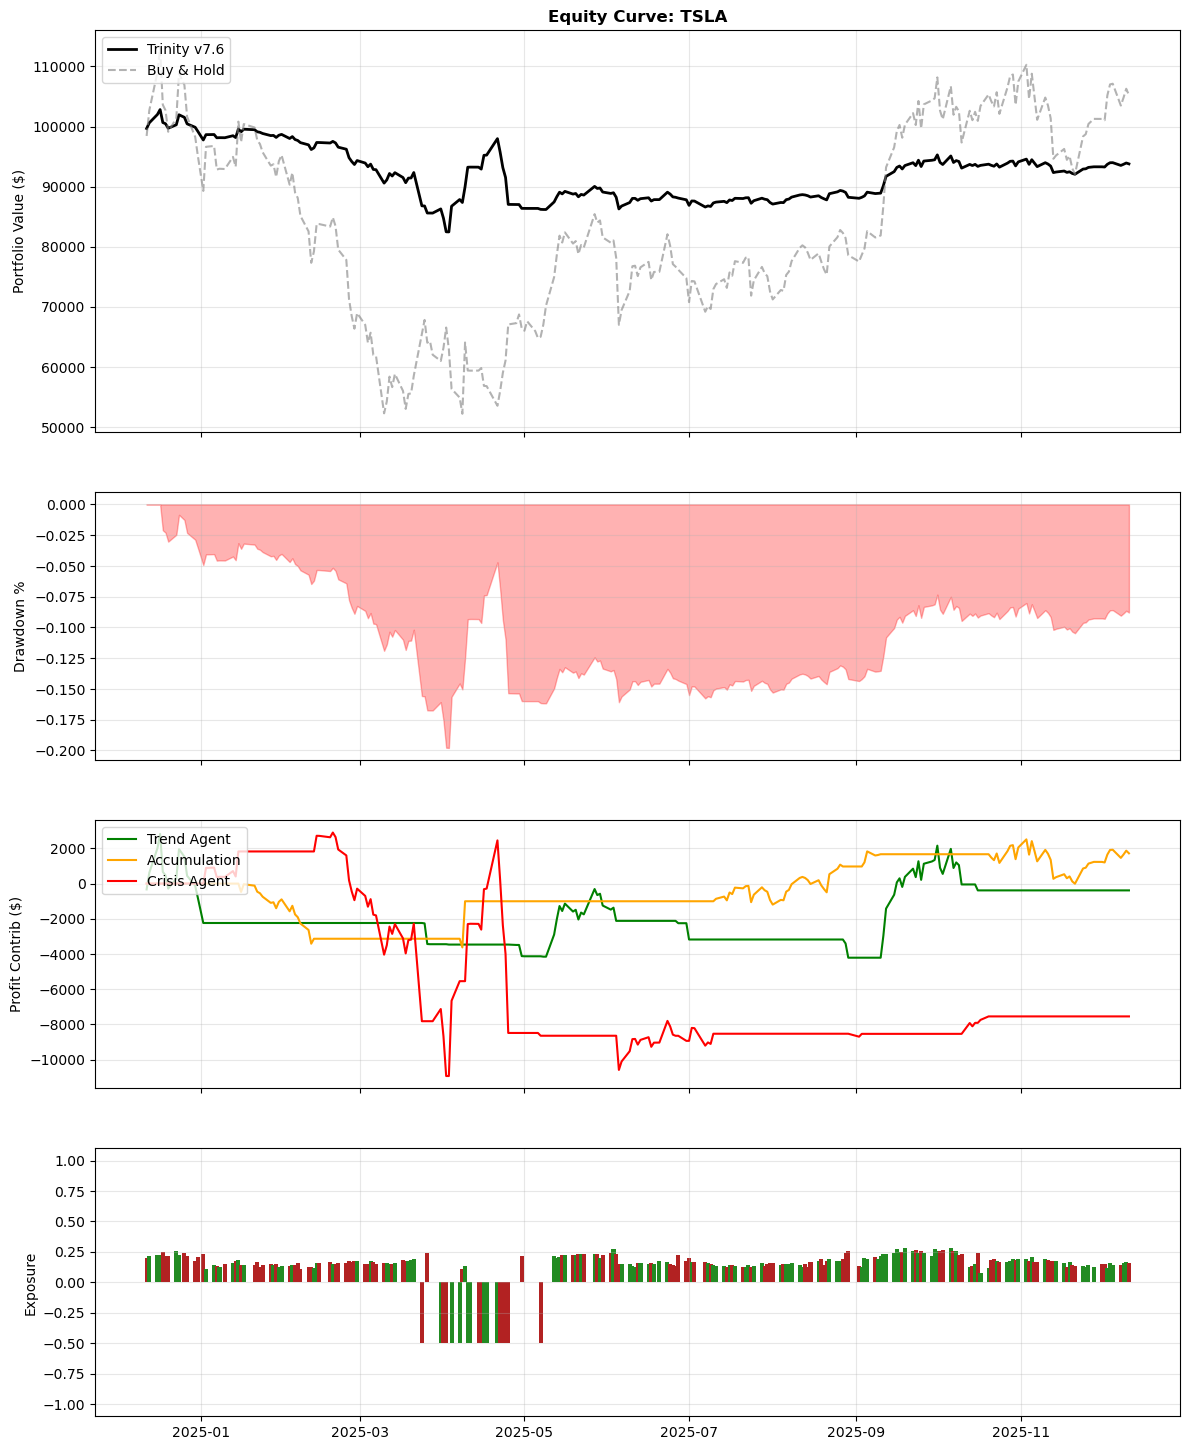

In [28]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7.6) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31", # Optimization runs on the last year of this
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods (Regime Specific Data)
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), # Volmageddon
        ("2020-01-01", "2020-05-01"), # COVID
        ("2022-01-01", "2022-12-31"), # Bear
    ],
    
    # Hyperparameters (Optimizable defaults)
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 60000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    
    # Execution Logic - v7.6 Adaptive
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR (v7.6) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend Indicators
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        # Mean Reversion / RSI
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Crisis Features
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # Volatility Regime
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7.6 - Adaptive Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_rsi = self.cols.index('rsi') if 'rsi' in self.cols else -1
        self.idx_adx = self.cols.index('adx') if 'adx' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        else:
             self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        rsi = self.data[self.current_step, self.idx_rsi] if self.idx_rsi != -1 else 50
        sma_dist = self.data[self.current_step, self.idx_sma] if self.idx_sma != -1 else 0
        adx = self.data[self.current_step, self.idx_adx] if self.idx_adx != -1 else 0
        
        reward = 0
        
        if self.mode == 'trend':
            reward = act * ret * 100
            # Conviction
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            # v7.6 Smart Whipsaw Protection
            # Don't punish buying Overbought if ADX is High (Melt Up)
            # Only punish if Overbought AND ADX is weak/fading (False Breakout)
            if act > 0.5 and rsi > 85:
                if adx < 0.40: # Weak trend + Overbought = Bad
                    reward -= 0.5 
                # If adx > 0.40, no penalty (Melt Up Allowed)
            
            # Don't punish selling Oversold if crashing
            if act < -0.5 and rsi < 15:
                if adx < 0.40: 
                    reward -= 0.5
                
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            reward -= 0.05 * abs(act) 
            if rsi < 30 and act > 0.5: reward += 0.5 
            if rsi > 70 and act < -0.5: reward += 0.5 

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 20.0) 
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7.6 Adaptive Amplification) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print(f"\n=== TRAINING SPECIALIST AGENTS (Win={self.config['WINDOW_SIZE']}) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO(
                "MlpPolicy", 
                env, 
                verbose=0, 
                learning_rate=self.config['LEARNING_RATE'],
                batch_size=self.config['BATCH_SIZE']
            )
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return -999.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return -999.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}

        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            # Features
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            
            # --- GATING LOGIC ---
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist < -0.05: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                else: regime, active_agent_name = "MANIA_MODE", "trend"
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- EXECUTION LOGIC (v7.6 Adaptive Amplification) ---
            
            # 1. Regime Scaler
            regime_scaler = 1.0
            
            # Trend/Mania: Moderate threshold, High gear
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.3: # Lowered threshold from 0.5 to 0.3
                    regime_scaler = 1.5 
                else:
                    regime_scaler = 1.0 
            
            # Accumulation: Give it teeth
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 2.0 
            
            # Crisis/Bear: Default 1.0
            elif regime in ['BEAR_TREND', 'JUMP_BEAR']:
                regime_scaler = 1.0
                
            # 2. PANIC BUTTON (The Frozen Bear Fix)
            # If Panic is detected, FORCE minimum exposure if agent is timid
            if regime == 'CRISIS_PANIC':
                if raw_action > -0.5:
                     raw_action = -0.5 # Force the Short
            
            # 3. Overrides
            if regime == 'JUMP_BULL': raw_action = 1.0
            
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0:
                     if mkt_ret > -0.02: raw_action = 0.5 
            
            # 4. Volatility Sizing
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            # 5. Final Calculation
            scaled_action = raw_action * regime_scaler * vol_scaler
            
            # Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.6', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER (v7.6 Validation Logic) ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        print(">>> OPTIMIZATION MODE: WALK-FORWARD (Validation on last year of training data) <<<")
        
        training_grid = { "WINDOW_SIZE": [40, 60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5, 4.0] }
        
        best_ret = -np.inf
        best_config = {} 
        
        # Determine Validation Period (e.g., 2023)
        # We hold out the last year of the user's "TRAIN_END" for validation
        val_start = str(int(train_end[:4])) + "-01-01"
        val_end = train_end
        train_cutoff = str(int(train_end[:4]) - 1) + "-12-31"
        
        print(f"    Training Phase: {train_start} to {train_cutoff}")
        print(f"    Validation Phase: {val_start} to {val_end}")
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_cutoff # Stop training before validation
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = val_start
                mgr.config['TEST_END'] = val_end
                
                # Suppress plots during optimization
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST (Val): {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Val Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    # Safety Defaults
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        # Run optimization on 2015-2023 data
        # It will use 2023 as validation to pick params
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.6 (FINAL) <<<")
    # Reset training period to full range for final model
    config['TRAIN_END'] = "2023-12-31" 
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["TSLA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "TSLA"
    START = "2024-12-12"
    END = "2025-12-12"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)

## 7.7


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR NVDA <<<
>>> OPTIMIZATION MODE: WALK-FORWARD (Validation on last year of training data) <<<
    Training Phase: 2015-01-01 to 2022-12-31
    Validation Phase: 2023-01-01 to 2023-12-31
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2022-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): 40.17% | Win:40 | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): 44.48% | Win:40 | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 4.0}
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): 56.79% | Win:40 | {'ADX_THRESHOLD': 25,

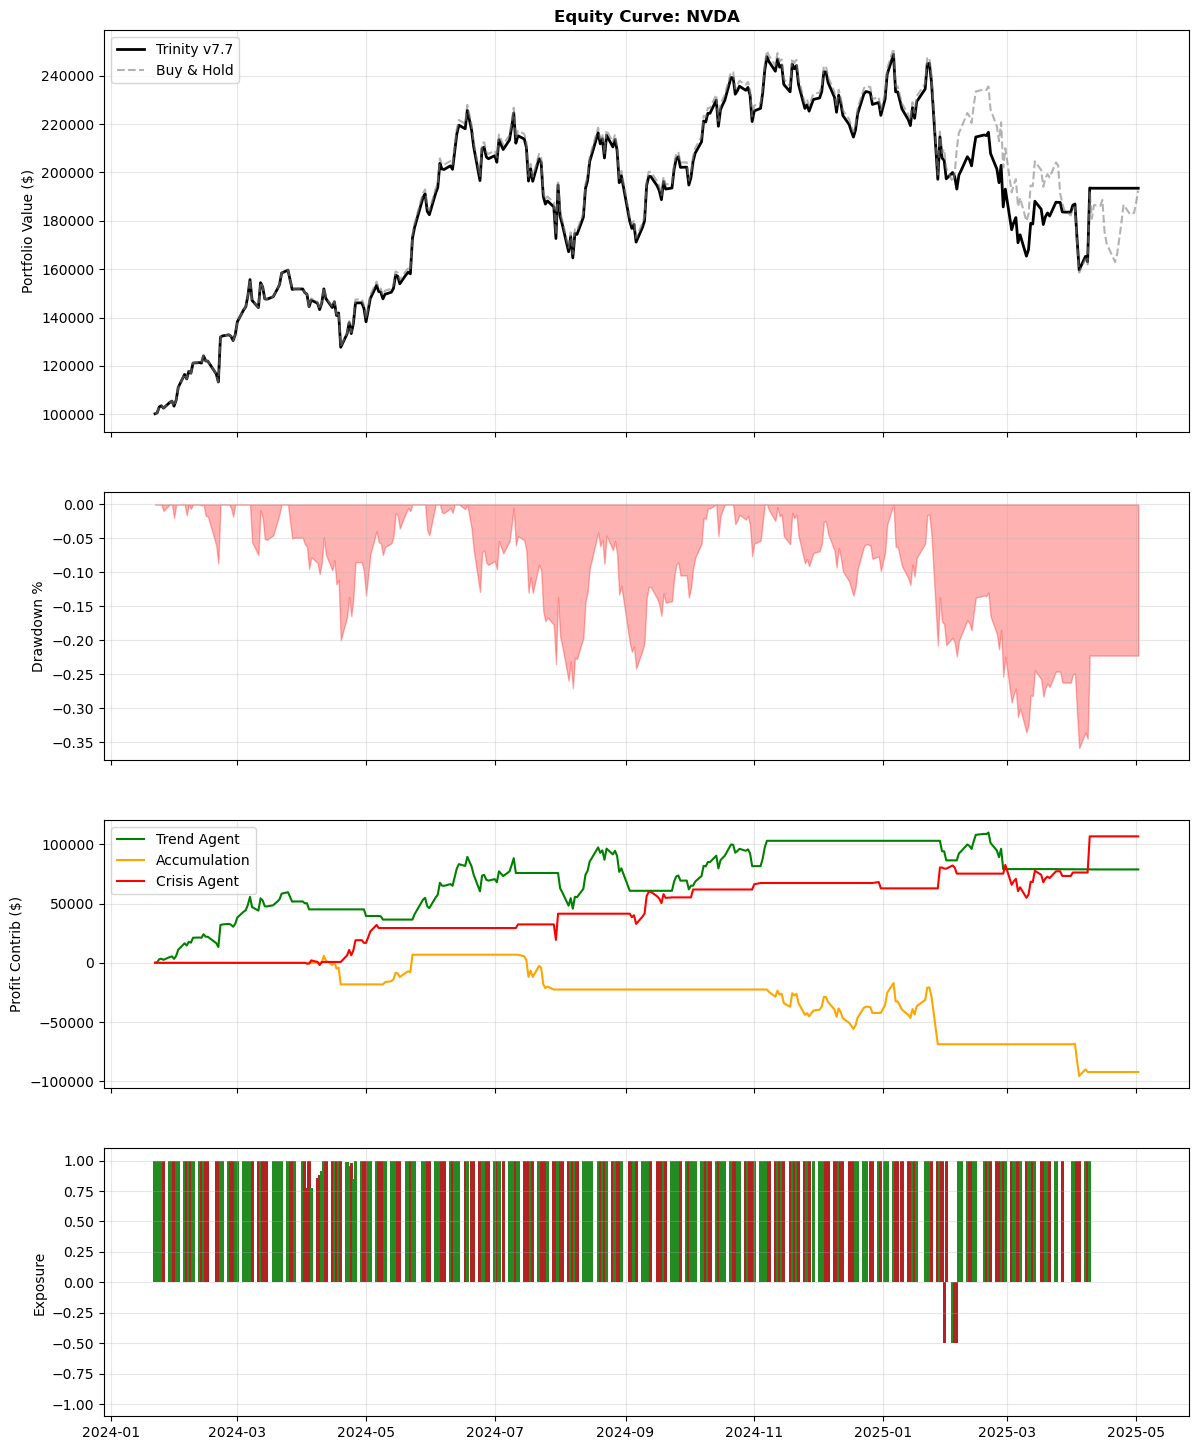

In [29]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7.7) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31", 
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), 
        ("2020-01-01", "2020-05-01"), 
        ("2022-01-01", "2022-12-31"), 
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 60000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    
    # Execution Logic
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR (v7.7 - Z-Scores) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend Indicators
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        # RSI
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Crisis Features
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        # Z-Score of SMA Distance (Standardized "Crash" Metric)
        sma200 = df[target].rolling(200).mean()
        dist_sma = (df[target] - sma200) / sma200
        df['dist_sma200'] = dist_sma
        
        # Calculate Rolling Z-Score of the distance
        dist_mean = dist_sma.rolling(252).mean()
        dist_std = dist_sma.rolling(252).std()
        df['z_score_sma'] = (dist_sma - dist_mean) / (dist_std + 1e-9)
        
        # Volatility Regime
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7.7 - Relaxed Crisis Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_rsi = self.cols.index('rsi') if 'rsi' in self.cols else -1
        self.idx_adx = self.cols.index('adx') if 'adx' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        else:
             self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        rsi = self.data[self.current_step, self.idx_rsi] if self.idx_rsi != -1 else 50
        sma_dist = self.data[self.current_step, self.idx_sma] if self.idx_sma != -1 else 0
        adx = self.data[self.current_step, self.idx_adx] if self.idx_adx != -1 else 0
        
        reward = 0
        
        if self.mode == 'trend':
            reward = act * ret * 100
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            if act > 0.5 and rsi > 85:
                if adx < 0.40: reward -= 0.5 
            if act < -0.5 and rsi < 15:
                if adx < 0.40: reward -= 0.5
                
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            reward -= 0.05 * abs(act) 
            if rsi < 30 and act > 0.5: reward += 0.5 
            if rsi > 70 and act < -0.5: reward += 0.5 

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                # Relaxed punishment: Reduced from 20.0 to 5.0
                # This stops the agent from being "paralyzed" by fear
                elif act > 0.1: reward -= (act * 5.0) 
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7.7 RSI Guardrails & Z-Score Gating) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print(f"\n=== TRAINING SPECIALIST AGENTS (Win={self.config['WINDOW_SIZE']}) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO("MlpPolicy", env, verbose=0, learning_rate=self.config['LEARNING_RATE'], batch_size=self.config['BATCH_SIZE'])
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return -999.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return -999.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_z_score = cols.index('z_score_sma')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        idx_rsi = cols.index('rsi')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}

        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            # Features
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            z_score = data_vals[t-1, idx_z_score] # Normalized Panic Metric
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            rsi = data_vals[t-1, idx_rsi]
            
            # --- GATING LOGIC (v7.7 Z-Score) ---
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                # v7.7 Fix: Use Z-Score (-2.0 Sigma) instead of -0.05
                if z_score < -2.0: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                else: regime, active_agent_name = "MANIA_MODE", "trend"
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- EXECUTION LOGIC ---
            
            # 1. Regime Scaler
            regime_scaler = 1.0
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.3: regime_scaler = 1.5 
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 2.0 
            
            # 2. PANIC BUTTON w/ RSI GUARDRAIL
            # Only force short if NOT oversold (RSI > 30)
            # This prevents shorting the hole
            if regime == 'CRISIS_PANIC':
                if rsi < 30:
                    raw_action = 0.0 # Step aside, don't short
                elif raw_action > -0.5:
                     raw_action = -0.5 # Force Short
            
            # 3. Overrides
            if regime == 'JUMP_BULL': raw_action = 1.0
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0:
                     if mkt_ret > -0.02: raw_action = 0.5 
            
            # 4. Volatility Sizing
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            # 5. Final Calculation
            scaled_action = raw_action * regime_scaler * vol_scaler
            
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.7', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        print(">>> OPTIMIZATION MODE: WALK-FORWARD (Validation on last year of training data) <<<")
        
        training_grid = { "WINDOW_SIZE": [40, 60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5, 4.0] }
        
        best_ret = -np.inf
        best_config = {} 
        
        val_start = str(int(train_end[:4])) + "-01-01"
        val_end = train_end
        train_cutoff = str(int(train_end[:4]) - 1) + "-12-31"
        
        print(f"    Training Phase: {train_start} to {train_cutoff}")
        print(f"    Validation Phase: {val_start} to {val_end}")
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_cutoff 
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = val_start
                mgr.config['TEST_END'] = val_end
                
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST (Val): {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Val Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.7 (FINAL) <<<")
    config['TRAIN_END'] = "2023-12-31" 
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["NVDA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "NVDA"
    START = "2024-01-22"
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR TSLA <<<
>>> OPTIMIZATION MODE: WALK-FORWARD (Validation on last year of training data) <<<
    Training Phase: 2015-01-01 to 2022-12-31
    Validation Phase: 2023-01-01 to 2023-12-31
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2022-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): -1.02% | Win:40 | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): 1.06% | Win:40 | {'ADX_THRESHOLD': 25, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 

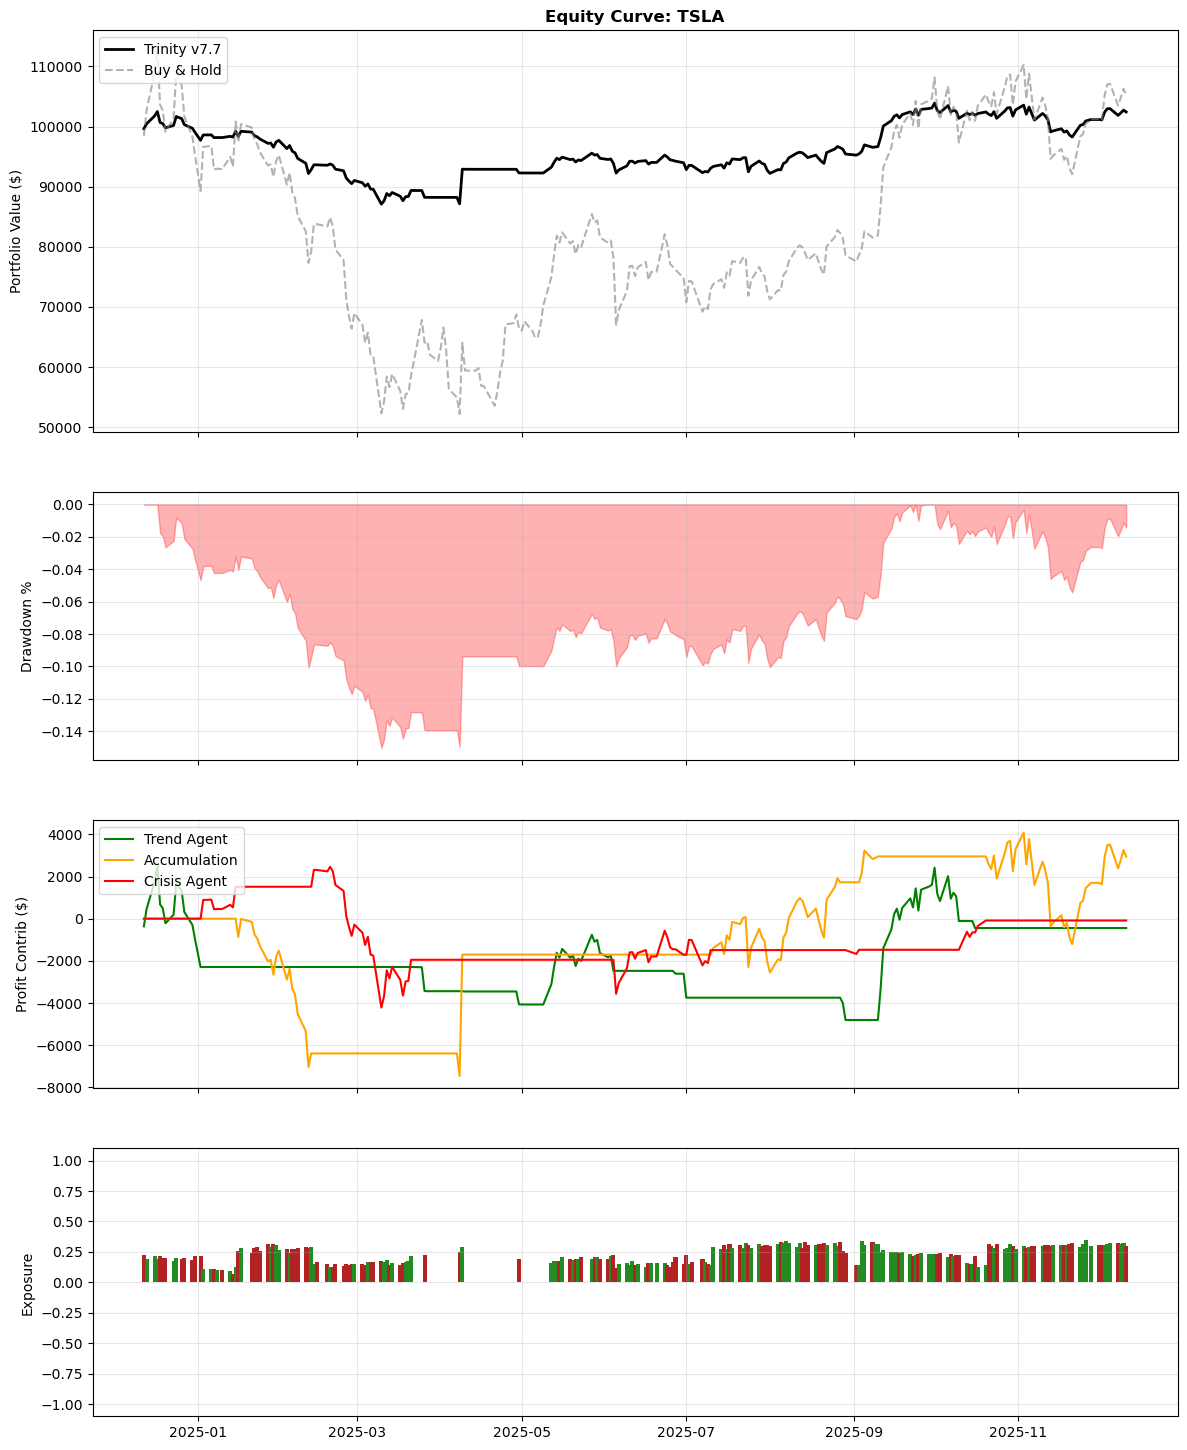

In [30]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7.7) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31", 
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), 
        ("2020-01-01", "2020-05-01"), 
        ("2022-01-01", "2022-12-31"), 
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 60000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    
    # Execution Logic
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR (v7.7 - Z-Scores) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend Indicators
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        # RSI
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Crisis Features
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        # Z-Score of SMA Distance (Standardized "Crash" Metric)
        sma200 = df[target].rolling(200).mean()
        dist_sma = (df[target] - sma200) / sma200
        df['dist_sma200'] = dist_sma
        
        # Calculate Rolling Z-Score of the distance
        dist_mean = dist_sma.rolling(252).mean()
        dist_std = dist_sma.rolling(252).std()
        df['z_score_sma'] = (dist_sma - dist_mean) / (dist_std + 1e-9)
        
        # Volatility Regime
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7.7 - Relaxed Crisis Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_rsi = self.cols.index('rsi') if 'rsi' in self.cols else -1
        self.idx_adx = self.cols.index('adx') if 'adx' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        else:
             self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        rsi = self.data[self.current_step, self.idx_rsi] if self.idx_rsi != -1 else 50
        sma_dist = self.data[self.current_step, self.idx_sma] if self.idx_sma != -1 else 0
        adx = self.data[self.current_step, self.idx_adx] if self.idx_adx != -1 else 0
        
        reward = 0
        
        if self.mode == 'trend':
            reward = act * ret * 100
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            if act > 0.5 and rsi > 85:
                if adx < 0.40: reward -= 0.5 
            if act < -0.5 and rsi < 15:
                if adx < 0.40: reward -= 0.5
                
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            reward -= 0.05 * abs(act) 
            if rsi < 30 and act > 0.5: reward += 0.5 
            if rsi > 70 and act < -0.5: reward += 0.5 

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                # Relaxed punishment: Reduced from 20.0 to 5.0
                # This stops the agent from being "paralyzed" by fear
                elif act > 0.1: reward -= (act * 5.0) 
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7.7 RSI Guardrails & Z-Score Gating) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print(f"\n=== TRAINING SPECIALIST AGENTS (Win={self.config['WINDOW_SIZE']}) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO("MlpPolicy", env, verbose=0, learning_rate=self.config['LEARNING_RATE'], batch_size=self.config['BATCH_SIZE'])
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return -999.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return -999.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_z_score = cols.index('z_score_sma')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        idx_rsi = cols.index('rsi')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}

        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            # Features
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            z_score = data_vals[t-1, idx_z_score] # Normalized Panic Metric
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            rsi = data_vals[t-1, idx_rsi]
            
            # --- GATING LOGIC (v7.7 Z-Score) ---
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                # v7.7 Fix: Use Z-Score (-2.0 Sigma) instead of -0.05
                if z_score < -2.0: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                else: regime, active_agent_name = "MANIA_MODE", "trend"
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- EXECUTION LOGIC ---
            
            # 1. Regime Scaler
            regime_scaler = 1.0
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.3: regime_scaler = 1.5 
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 2.0 
            
            # 2. PANIC BUTTON w/ RSI GUARDRAIL
            # Only force short if NOT oversold (RSI > 30)
            # This prevents shorting the hole
            if regime == 'CRISIS_PANIC':
                if rsi < 30:
                    raw_action = 0.0 # Step aside, don't short
                elif raw_action > -0.5:
                     raw_action = -0.5 # Force Short
            
            # 3. Overrides
            if regime == 'JUMP_BULL': raw_action = 1.0
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0:
                     if mkt_ret > -0.02: raw_action = 0.5 
            
            # 4. Volatility Sizing
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            # 5. Final Calculation
            scaled_action = raw_action * regime_scaler * vol_scaler
            
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.7', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        print(">>> OPTIMIZATION MODE: WALK-FORWARD (Validation on last year of training data) <<<")
        
        training_grid = { "WINDOW_SIZE": [40, 60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5, 4.0] }
        
        best_ret = -np.inf
        best_config = {} 
        
        val_start = str(int(train_end[:4])) + "-01-01"
        val_end = train_end
        train_cutoff = str(int(train_end[:4]) - 1) + "-12-31"
        
        print(f"    Training Phase: {train_start} to {train_cutoff}")
        print(f"    Validation Phase: {val_start} to {val_end}")
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_cutoff 
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = val_start
                mgr.config['TEST_END'] = val_end
                
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST (Val): {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Val Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.7 (FINAL) <<<")
    config['TRAIN_END'] = "2023-12-31" 
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["TSLA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "TSLA"
    START = "2024-12-12"
    END = "2025-12-12"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)

## v7.8


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR NVDA <<<
>>> OPTIMIZATION MODE: WALK-FORWARD (Validation on last year of training data) <<<
    Training Phase: 2015-01-01 to 2022-12-31
    Validation Phase: 2023-01-01 to 2023-12-31
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2022-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): 35.38% | Win:40 | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): 40.05% | Win:40 | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 4.0}
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): 44.28% | Win:40 | {'ADX_THRESHOLD': 25,

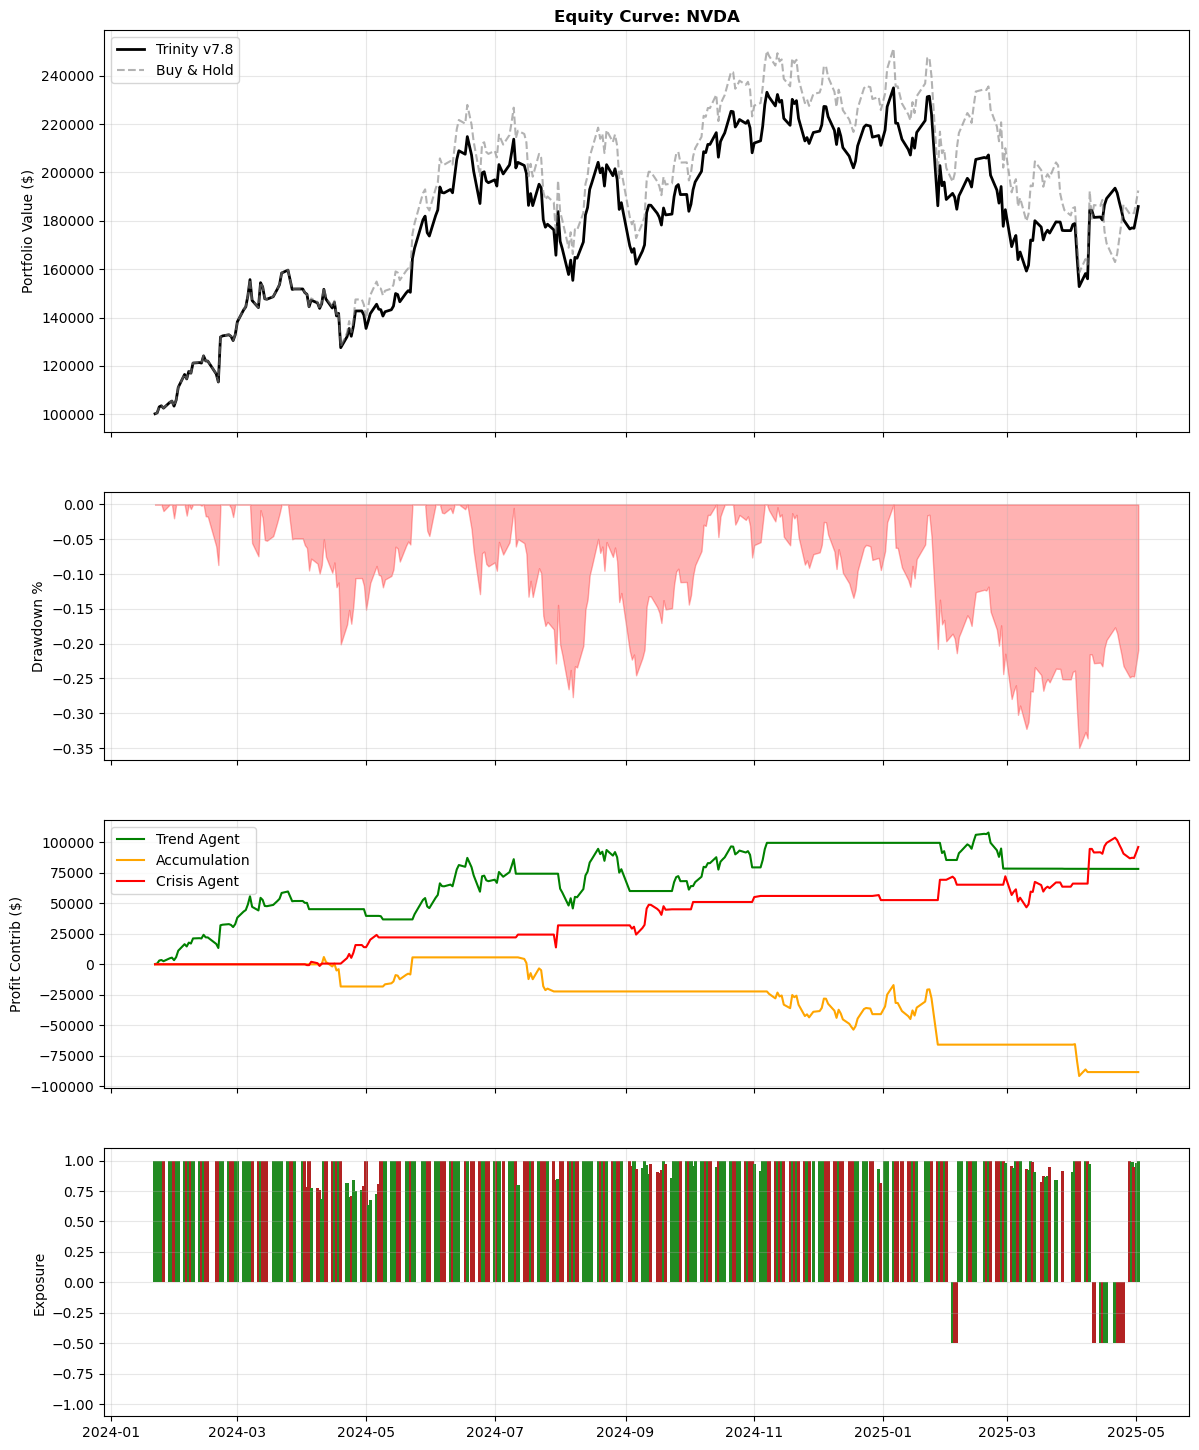

In [31]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7.8) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31", 
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), 
        ("2020-01-01", "2020-05-01"), 
        ("2022-01-01", "2022-12-31"), 
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 60000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    
    # Execution Logic
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False 
}

# --- DATA PROCESSOR (v7.8) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend Indicators
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        # RSI
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Crisis Features
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        # Z-Score of SMA Distance
        sma200 = df[target].rolling(200).mean()
        dist_sma = (df[target] - sma200) / sma200
        df['dist_sma200'] = dist_sma
        
        # Calculate Rolling Z-Score of the distance
        dist_mean = dist_sma.rolling(252).mean()
        dist_std = dist_sma.rolling(252).std()
        df['z_score_sma'] = (dist_sma - dist_mean) / (dist_std + 1e-9)
        
        # Volatility Regime
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7.8 - Bear Long Penalty) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_rsi = self.cols.index('rsi') if 'rsi' in self.cols else -1
        self.idx_adx = self.cols.index('adx') if 'adx' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        else:
             self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        rsi = self.data[self.current_step, self.idx_rsi] if self.idx_rsi != -1 else 50
        sma_dist = self.data[self.current_step, self.idx_sma] if self.idx_sma != -1 else 0
        adx = self.data[self.current_step, self.idx_adx] if self.idx_adx != -1 else 0
        
        reward = 0
        
        if self.mode == 'trend':
            reward = act * ret * 100
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            if act > 0.5 and rsi > 85:
                if adx < 0.40: reward -= 0.5 
            if act < -0.5 and rsi < 15:
                if adx < 0.40: reward -= 0.5
                
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            reward -= 0.05 * abs(act) 
            if rsi < 30 and act > 0.5: reward += 0.5 
            if rsi > 70 and act < -0.5: reward += 0.5 

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 5.0)
            
            # v7.8: Explicit Penalty for holding Longs in Bear Market
            # If price is below SMA200 (Bear), punish Long exposure
            if sma_dist < 0 and act > 0:
                reward -= 0.1 * act
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7.8 Directional Volatility Gating) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print(f"\n=== TRAINING SPECIALIST AGENTS (Win={self.config['WINDOW_SIZE']}) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO("MlpPolicy", env, verbose=0, learning_rate=self.config['LEARNING_RATE'], batch_size=self.config['BATCH_SIZE'])
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return -999.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return -999.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_z_score = cols.index('z_score_sma')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        idx_rsi = cols.index('rsi')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}

        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            # Features
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            z_score = data_vals[t-1, idx_z_score] 
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            rsi = data_vals[t-1, idx_rsi]
            
            # --- GATING LOGIC (v7.8 Directional Fix) ---
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            
            elif is_extreme_vol:
                # v7.8 Fix: Logic Tree for High Vol
                if sma_dist > 0:
                    regime, active_agent_name = "MANIA_MODE", "trend"
                else:
                    # High Vol + Below SMA = DANGER
                    if z_score < -1.5: # Relaxed from -2.0 for TSLA sensitivity
                        regime, active_agent_name = "CRISIS_PANIC", "crisis"
                    else:
                        regime, active_agent_name = "BEAR_VOLATILITY", "crisis"
                        
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- EXECUTION LOGIC ---
            
            # 1. Regime Scaler
            regime_scaler = 1.0
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.3: regime_scaler = 1.5 
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 2.0 
            
            # 2. PANIC BUTTON w/ RSI GUARDRAIL
            if regime == 'CRISIS_PANIC':
                if rsi < 30:
                    raw_action = 0.0 
                elif raw_action > -0.5:
                     raw_action = -0.5 
            
            # 3. Overrides
            if regime == 'JUMP_BULL': raw_action = 1.0
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0:
                     if mkt_ret > -0.02: raw_action = 0.5 
            
            # 4. Volatility Sizing
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            # 5. Final Calculation
            scaled_action = raw_action * regime_scaler * vol_scaler
            
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: scaled_action = np.clip(scaled_action, -10, 0)
                elif sma_dist > 0: scaled_action = np.clip(scaled_action, 0, 10)
            
            position_size = np.clip(scaled_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.8', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        print(">>> OPTIMIZATION MODE: WALK-FORWARD (Validation on last year of training data) <<<")
        
        training_grid = { "WINDOW_SIZE": [40, 60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5, 4.0] }
        
        best_ret = -np.inf
        best_config = {} 
        
        val_start = str(int(train_end[:4])) + "-01-01"
        val_end = train_end
        train_cutoff = str(int(train_end[:4]) - 1) + "-12-31"
        
        print(f"    Training Phase: {train_start} to {train_cutoff}")
        print(f"    Validation Phase: {val_start} to {val_end}")
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_cutoff 
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = val_start
                mgr.config['TEST_END'] = val_end
                
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST (Val): {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Val Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.8 (FINAL) <<<")
    config['TRAIN_END'] = "2023-12-31" 
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["NVDA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "NVDA"
    START = "2024-01-22"
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR NVDA <<<
>>> OPTIMIZATION MODE: WALK-FORWARD (Validation on last year of training data) <<<
    Training Phase: 2015-01-01 to 2022-12-31
    Validation Phase: 2023-01-01 to 2023-12-31
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2022-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): 42.61% | Win:40 | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): 46.16% | Win:40 | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 4.0}
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): 56.68% | Win:40 | {'ADX_THRESHOLD': 25,

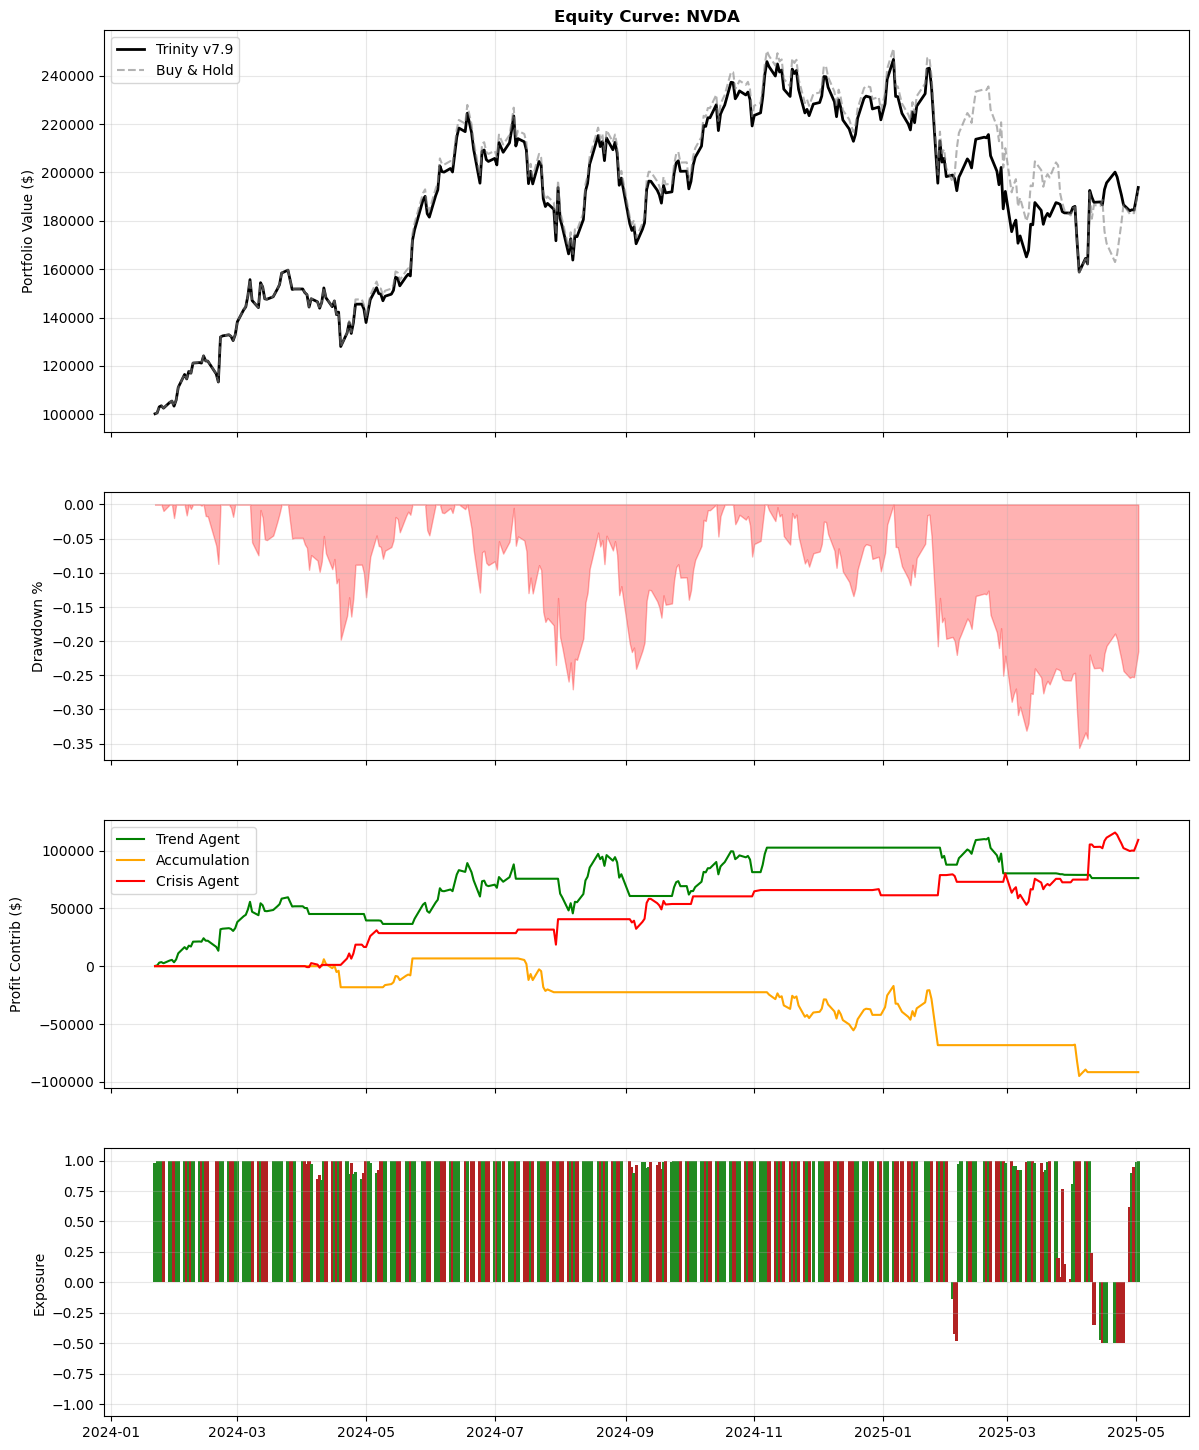

In [32]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7.9) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31", 
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), 
        ("2020-01-01", "2020-05-01"), 
        ("2022-01-01", "2022-12-31"), 
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 60000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    
    # Execution Logic
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False,
    "ACTION_SMOOTHING": 0.2 # 0.0 = No smoothing, 0.9 = High Inertia
}

# --- DATA PROCESSOR (v7.9) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend Indicators
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        # RSI
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Crisis Features
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        # Z-Score of SMA Distance
        sma200 = df[target].rolling(200).mean()
        dist_sma = (df[target] - sma200) / sma200
        df['dist_sma200'] = dist_sma
        
        # Calculate Rolling Z-Score of the distance
        dist_mean = dist_sma.rolling(252).mean()
        dist_std = dist_sma.rolling(252).std()
        df['z_score_sma'] = (dist_sma - dist_mean) / (dist_std + 1e-9)
        
        # Volatility Regime
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7.9 - Relaxed Trend Penalty) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_rsi = self.cols.index('rsi') if 'rsi' in self.cols else -1
        self.idx_adx = self.cols.index('adx') if 'adx' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        else:
             self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        rsi = self.data[self.current_step, self.idx_rsi] if self.idx_rsi != -1 else 50
        sma_dist = self.data[self.current_step, self.idx_sma] if self.idx_sma != -1 else 0
        adx = self.data[self.current_step, self.idx_adx] if self.idx_adx != -1 else 0
        
        reward = 0
        
        if self.mode == 'trend':
            reward = act * ret * 100
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            # v7.9: Relaxed ADX Threshold (40 -> 25)
            # Allow buying Overbought (RSI > 85) IF ADX is decent (> 25)
            if act > 0.5 and rsi > 85:
                if adx < 0.25: # Was 0.40, too strict for NVDA grind
                    reward -= 0.5 
            
            if act < -0.5 and rsi < 15:
                if adx < 0.25: reward -= 0.5
                
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            reward -= 0.05 * abs(act) 
            if rsi < 30 and act > 0.5: reward += 0.5 
            if rsi > 70 and act < -0.5: reward += 0.5 

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 5.0)
            
            if sma_dist < 0 and act > 0:
                reward -= 0.1 * act
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7.9 Action Smoothing) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        self.last_action = 0.0 # For Smoothing
        
    def train_specialists(self, verbose=True):
        if verbose: print(f"\n=== TRAINING SPECIALIST AGENTS (Win={self.config['WINDOW_SIZE']}) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO("MlpPolicy", env, verbose=0, learning_rate=self.config['LEARNING_RATE'], batch_size=self.config['BATCH_SIZE'])
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return -999.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return -999.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        self.last_action = 0.0 # Reset for new backtest
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_z_score = cols.index('z_score_sma')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        idx_rsi = cols.index('rsi')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}

        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            # Features
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            z_score = data_vals[t-1, idx_z_score] 
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            rsi = data_vals[t-1, idx_rsi]
            
            # --- GATING LOGIC ---
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            
            elif is_extreme_vol:
                if sma_dist > 0:
                    regime, active_agent_name = "MANIA_MODE", "trend"
                else:
                    if z_score < -1.5:
                        regime, active_agent_name = "CRISIS_PANIC", "crisis"
                    else:
                        regime, active_agent_name = "BEAR_VOLATILITY", "crisis"
                        
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- EXECUTION LOGIC (v7.9 Smoothed) ---
            
            # 1. Regime Scaler
            regime_scaler = 1.0
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.3: regime_scaler = 1.5 
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 2.0 
            
            # 2. PANIC BUTTON
            if regime == 'CRISIS_PANIC':
                if rsi < 30:
                    raw_action = 0.0 
                elif raw_action > -0.5:
                     raw_action = -0.5 
            
            # 3. Overrides
            if regime == 'JUMP_BULL': raw_action = 1.0
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0:
                     if mkt_ret > -0.02: raw_action = 0.5 
            
            # 4. Volatility Sizing
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            # 5. Target Calculation
            target_action = raw_action * regime_scaler * vol_scaler
            
            # 6. Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: target_action = np.clip(target_action, -10, 0)
                elif sma_dist > 0: target_action = np.clip(target_action, 0, 10)
            
            # 7. SMOOTHING (v7.9 New)
            # Prevents churn burn. Keeps the "Train" moving.
            alpha = self.config.get('ACTION_SMOOTHING', 0.2) 
            final_action = (1 - alpha) * target_action + alpha * self.last_action
            self.last_action = final_action # Update state
            
            position_size = np.clip(final_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.9', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        print(">>> OPTIMIZATION MODE: WALK-FORWARD (Validation on last year of training data) <<<")
        
        training_grid = { "WINDOW_SIZE": [40, 60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5, 4.0] }
        
        best_ret = -np.inf
        best_config = {} 
        
        val_start = str(int(train_end[:4])) + "-01-01"
        val_end = train_end
        train_cutoff = str(int(train_end[:4]) - 1) + "-12-31"
        
        print(f"    Training Phase: {train_start} to {train_cutoff}")
        print(f"    Validation Phase: {val_start} to {val_end}")
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_cutoff 
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = val_start
                mgr.config['TEST_END'] = val_end
                
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST (Val): {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Val Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.9 (FINAL) <<<")
    config['TRAIN_END'] = "2023-12-31" 
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["NVDA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "NVDA"
    START = "2024-01-22"
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR TSLA <<<
>>> OPTIMIZATION MODE: WALK-FORWARD (Validation on last year of training data) <<<
    Training Phase: 2015-01-01 to 2022-12-31
    Validation Phase: 2023-01-01 to 2023-12-31
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2022-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): -3.52% | Win:40 | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2023-12-31)
  >>> NEW BEST (Val): -2.90% | Win:40 | {'ADX_THRESHOLD': 25, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01

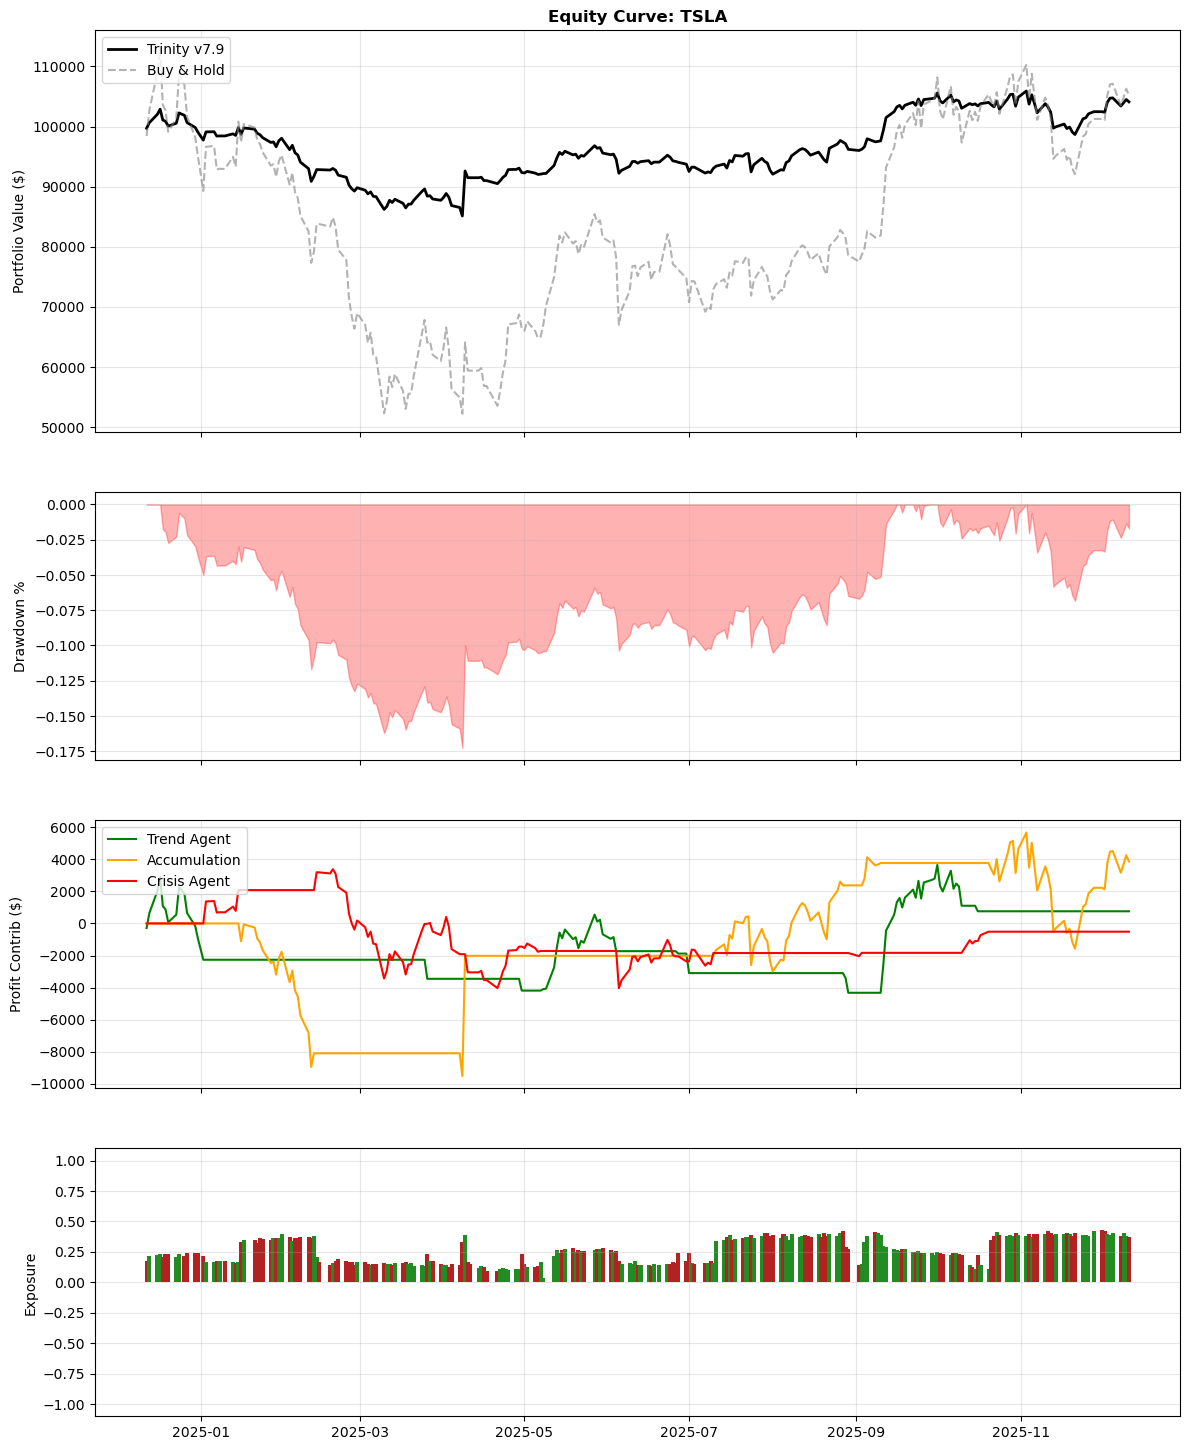

In [33]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v7.9) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31", 
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), 
        ("2020-01-01", "2020-05-01"), 
        ("2022-01-01", "2022-12-31"), 
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 60000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    
    # Execution Logic
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False,
    "ACTION_SMOOTHING": 0.2 # 0.0 = No smoothing, 0.9 = High Inertia
}

# --- DATA PROCESSOR (v7.9) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        df['returns'] = df[target].pct_change()
        
        # JUMP DETECTION
        l_stat = self.calculate_lee_mykland(df[target], window=20)
        df['l_stat'] = l_stat
        
        # Trend Indicators
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        # RSI
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Crisis Features
        if '^VIX' in df.columns: df['vix_norm'] = (df['^VIX'] - 15) / 40
        else: df['vix_norm'] = 0
            
        # Z-Score of SMA Distance
        sma200 = df[target].rolling(200).mean()
        dist_sma = (df[target] - sma200) / sma200
        df['dist_sma200'] = dist_sma
        
        # Calculate Rolling Z-Score of the distance
        dist_mean = dist_sma.rolling(252).mean()
        dist_std = dist_sma.rolling(252).std()
        df['z_score_sma'] = (dist_sma - dist_mean) / (dist_std + 1e-9)
        
        # Volatility Regime
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v7.9 - Relaxed Trend Penalty) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.n_features = df.shape[1]
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
        self.data = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        self.idx_sma = self.cols.index('dist_sma200') if 'dist_sma200' in self.cols else -1
        self.idx_rsi = self.cols.index('rsi') if 'rsi' in self.cols else -1
        self.idx_adx = self.cols.index('adx') if 'adx' in self.cols else -1
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        else:
             self.current_step = self.window
        return self._get_obs(), {}
    
    def _get_obs(self):
        return self.data[self.current_step-self.window : self.current_step].flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data[self.current_step, 0] 
        rsi = self.data[self.current_step, self.idx_rsi] if self.idx_rsi != -1 else 50
        sma_dist = self.data[self.current_step, self.idx_sma] if self.idx_sma != -1 else 0
        adx = self.data[self.current_step, self.idx_adx] if self.idx_adx != -1 else 0
        
        reward = 0
        
        if self.mode == 'trend':
            reward = act * ret * 100
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            # v7.9: Relaxed ADX Threshold (40 -> 25)
            # Allow buying Overbought (RSI > 85) IF ADX is decent (> 25)
            if act > 0.5 and rsi > 85:
                if adx < 0.25: # Was 0.40, too strict for NVDA grind
                    reward -= 0.5 
            
            if act < -0.5 and rsi < 15:
                if adx < 0.25: reward -= 0.5
                
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            reward -= 0.05 * abs(act) 
            if rsi < 30 and act > 0.5: reward += 0.5 
            if rsi > 70 and act < -0.5: reward += 0.5 

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 5.0)
            
            if sma_dist < 0 and act > 0:
                reward -= 0.1 * act
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v7.9 Action Smoothing) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        self.last_action = 0.0 # For Smoothing
        
    def train_specialists(self, verbose=True):
        if verbose: print(f"\n=== TRAINING SPECIALIST AGENTS (Win={self.config['WINDOW_SIZE']}) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO("MlpPolicy", env, verbose=0, learning_rate=self.config['LEARNING_RATE'], batch_size=self.config['BATCH_SIZE'])
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return -999.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return -999.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        self.last_action = 0.0 # Reset for new backtest
        
        cols = full_data.columns.tolist()
        idx_adx = cols.index('adx')
        idx_sma = cols.index('dist_sma200')
        idx_z_score = cols.index('z_score_sma')
        idx_ret = cols.index('returns')
        idx_vol_pct = cols.index('vol_percentile')
        idx_raw_vol = cols.index('realized_vol_20d')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_l_stat = cols.index('l_stat')
        idx_rsi = cols.index('rsi')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}

        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            obs_raw = data_vals[t-window : t].flatten()
            
            # Features
            vol_pct = data_vals[t-1, idx_vol_pct] 
            raw_vol = data_vals[t-1, idx_raw_vol]
            adx = data_vals[t-1, idx_adx]
            sma_dist = data_vals[t-1, idx_sma]
            z_score = data_vals[t-1, idx_z_score] 
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            l_stat = data_vals[t-1, idx_l_stat]
            rsi = data_vals[t-1, idx_rsi]
            
            # --- GATING LOGIC ---
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            
            elif is_extreme_vol:
                if sma_dist > 0:
                    regime, active_agent_name = "MANIA_MODE", "trend"
                else:
                    if z_score < -1.5:
                        regime, active_agent_name = "CRISIS_PANIC", "crisis"
                    else:
                        regime, active_agent_name = "BEAR_VOLATILITY", "crisis"
                        
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
                
            # Predict
            agent = self.agents[active_agent_name]
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = agent.predict(obs_norm, deterministic=True)
            
            mkt_ret = data_vals[t, idx_ret]
            raw_action = action[0]
            
            # --- EXECUTION LOGIC (v7.9 Smoothed) ---
            
            # 1. Regime Scaler
            regime_scaler = 1.0
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.3: regime_scaler = 1.5 
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 2.0 
            
            # 2. PANIC BUTTON
            if regime == 'CRISIS_PANIC':
                if rsi < 30:
                    raw_action = 0.0 
                elif raw_action > -0.5:
                     raw_action = -0.5 
            
            # 3. Overrides
            if regime == 'JUMP_BULL': raw_action = 1.0
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0:
                     if mkt_ret > -0.02: raw_action = 0.5 
            
            # 4. Volatility Sizing
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            # 5. Target Calculation
            target_action = raw_action * regime_scaler * vol_scaler
            
            # 6. Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: target_action = np.clip(target_action, -10, 0)
                elif sma_dist > 0: target_action = np.clip(target_action, 0, 10)
            
            # 7. SMOOTHING (v7.9 New)
            # Prevents churn burn. Keeps the "Train" moving.
            alpha = self.config.get('ACTION_SMOOTHING', 0.2) 
            final_action = (1 - alpha) * target_action + alpha * self.last_action
            self.last_action = final_action # Update state
            
            position_size = np.clip(final_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Trend_PnL': agent_pnls['trend'],
                'MeanRev_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret
    
    def plot_dashboard(self, res):
        fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True, gridspec_kw={'height_ratios': [3, 2, 2, 2]})
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v7.9', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Portfolio Value ($)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        ax1 = axes[1]
        strat_peak = res['Portfolio'].cummax()
        strat_dd = (res['Portfolio'] - strat_peak) / strat_peak
        ax1.fill_between(res.index, strat_dd, 0, color='red', alpha=0.3, label='Strategy Drawdown')
        ax1.set_ylabel("Drawdown %")
        ax1.grid(True, alpha=0.3)

        ax2 = axes[2]
        ax2.plot(res.index, res['Trend_PnL'], label='Trend Agent', color='green', linewidth=1.5)
        ax2.plot(res.index, res['MeanRev_PnL'], label='Accumulation', color='orange', linewidth=1.5)
        ax2.plot(res.index, res['Crisis_PnL'], label='Crisis Agent', color='red', linewidth=1.5)
        ax2.set_ylabel("Profit Contrib ($)")
        ax2.legend(loc='upper left')
        ax2.grid(True, alpha=0.3)

        ax3 = axes[3]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax3.bar(res.index, res['Scale Act'], color=colors, width=1.5)
        ax3.set_ylabel("Exposure")
        ax3.set_ylim(-1.1, 1.1)
        ax3.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        print(">>> OPTIMIZATION MODE: WALK-FORWARD (Validation on last year of training data) <<<")
        
        training_grid = { "WINDOW_SIZE": [40, 60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5, 4.0] }
        
        best_ret = -np.inf
        best_config = {} 
        
        val_start = str(int(train_end[:4])) + "-01-01"
        val_end = train_end
        train_cutoff = str(int(train_end[:4]) - 1) + "-12-31"
        
        print(f"    Training Phase: {train_start} to {train_cutoff}")
        print(f"    Validation Phase: {val_start} to {val_end}")
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_cutoff 
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = val_start
                mgr.config['TEST_END'] = val_end
                
                ret = mgr.run_backtest(plot_results=False)
                
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST (Val): {ret:.2%} | Win:{window} | {params}")
                
        print(f"\n>>> BEST PARAMETERS FOUND: {best_config} (Val Ret: {best_ret:.2%}) <<<")
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V7.9 (FINAL) <<<")
    config['TRAIN_END'] = "2023-12-31" 
    
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["TSLA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "TSLA"
    START = "2024-12-12"
    END = "2025-12-12"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)

## v8.0


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR NVDA <<<
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 24.56% | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 31.08% | {'ADX_THRESHOLD': 25, 'JUMP_THRESHOLD': 3.5}

>>> INITIALIZING TRINITY V8.0 (FINAL) <<<

=== TRAINING SPECIALIST AGENTS (Win=60) ===
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['NVD

KeyError: 'Scale Act'

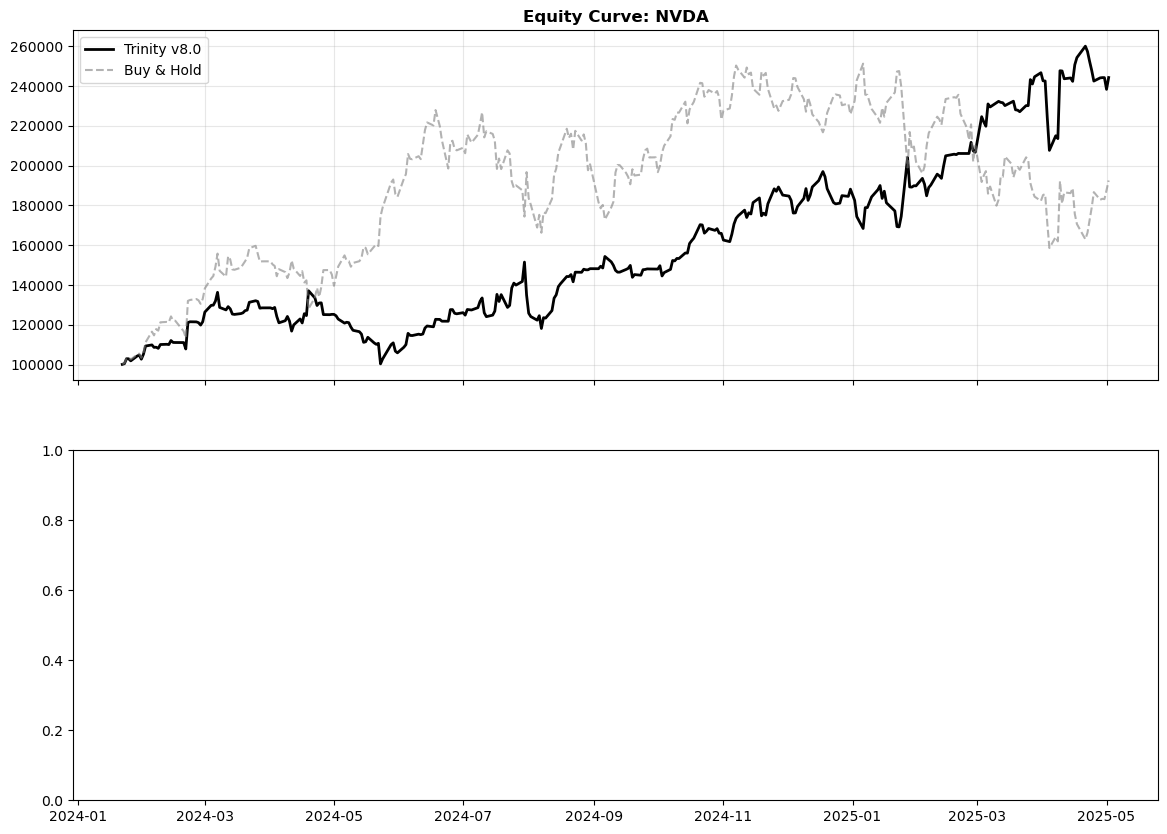

In [35]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v8.0) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31", 
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), 
        ("2020-01-01", "2020-05-01"), 
        ("2022-01-01", "2022-12-31"), 
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 60000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    
    # Execution Logic
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False
}

# --- DATA PROCESSOR (v8.0 Split Views) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        
        # --- BASE FEATURES ---
        df['returns'] = df[target].pct_change()
        df['log_ret'] = np.log(df[target] / df[target].shift(1))
        
        # --- TREND FEATURES (For Trend Agent) ---
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        # ADX Calculation...
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # --- OSCILLATOR FEATURES (For Accumulation Agent) ---
        # RSI
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Bollinger %B
        sma20 = df[target].rolling(20).mean()
        std20 = df[target].rolling(20).std()
        df['pct_b'] = (df[target] - (sma20 - 2*std20)) / (4*std20 + 1e-9)
        df['bb_width'] = (4 * std20) / (sma20 + 1e-9)
        
        # Detrended Price Oscillator (Proxy)
        df['dpo'] = df[target] - df[target].shift(int(20/2 + 1)).rolling(20).mean()
        
        # --- CRISIS FEATURES ---
        df['l_stat'] = self.calculate_lee_mykland(df[target], window=20)
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        # Z-Score of SMA Distance (Panic Metric)
        dist_mean = df['dist_sma200'].rolling(252).mean()
        dist_std = df['dist_sma200'].rolling(252).std()
        df['z_score_sma'] = (df['dist_sma200'] - dist_mean) / (dist_std + 1e-9)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v8.0 - Split Observation Space) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.data_vals = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        
        # --- FEATURE SELECTION BASED ON MODE ---
        if self.mode == 'accumulation':
            # Accumulation agent ONLY sees Oscillators. Blind to Trend.
            # Features: RSI, %B, BB Width, DPO, Volatility
            self.obs_cols = ['rsi', 'pct_b', 'bb_width', 'dpo', 'realized_vol_20d']
        else:
            # Trend/Crisis see Macro structure
            # Features: Returns, SMA Dist, ADX, Jump Stat, Volatility
            self.obs_cols = ['returns', 'dist_sma200', 'adx', 'l_stat', 'realized_vol_20d']
            
        self.obs_indices = [self.cols.index(c) for c in self.obs_cols]
        self.n_features = len(self.obs_cols)
        
        # Global indices for rewards
        self.idx_ret = self.cols.index('returns')
        self.idx_sma = self.cols.index('dist_sma200')
        self.idx_rsi = self.cols.index('rsi')
        self.idx_adx = self.cols.index('adx')
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        return self._get_obs(), {}
    
    def _get_obs(self):
        # Select specific features for this specialist
        obs_window = self.data_vals[self.current_step-self.window : self.current_step, self.obs_indices]
        return obs_window.flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data_vals[self.current_step, self.idx_ret] 
        rsi = self.data_vals[self.current_step, self.idx_rsi]
        sma_dist = self.data_vals[self.current_step, self.idx_sma]
        adx = self.data_vals[self.current_step, self.idx_adx]
        
        reward = 0
        
        if self.mode == 'trend':
            reward = act * ret * 100
            # Standard Trend Following Logic
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            # Whipsaw: Only penalize buying overbought if Trend is Weak
            if act > 0.5 and rsi > 85 and adx < 0.25: reward -= 0.5 
            if act < -0.5 and rsi < 15 and adx < 0.25: reward -= 0.5
                
        elif self.mode == 'accumulation': 
            # v8.0 BEHAVIORAL REWARDING
            # Ignore PnL noise. Reward "Buying Value" and "Selling Premium".
            
            # 1. The Value Factor Reward
            # If price < SMA (Negative Dist), Longs are good.
            # If price > SMA (Positive Dist), Shorts are good.
            # We invert sma_dist so negative dist * positive act = negative? No.
            # We want: (SMA - Price). If positive, Buy.
            # SMA - Price ~ -dist_sma200
            
            value_signal = -sma_dist # Positive if Price < SMA
            reward += (act * value_signal * 10.0) # Reward alignment with Value
            
            # 2. Oscillator Limits
            if rsi < 30: reward += act * 1.0 # Reward Longs
            if rsi > 70: reward -= act * 1.0 # Reward Shorts (negative act)
            
            # 3. Holding Tax (Reduced)
            reward -= 0.01 * abs(act) # Small tax to prevent camping

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 5.0)
            
            # Penalize Longs in Bear Market
            if sma_dist < 0 and act > 0: reward -= 0.1 * act
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v8.0) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print(f"\n=== TRAINING SPECIALIST AGENTS (Win={self.config['WINDOW_SIZE']}) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            # Note: Env now handles observation space internally based on mode
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO("MlpPolicy", env, verbose=0, learning_rate=self.config['LEARNING_RATE'], batch_size=self.config['BATCH_SIZE'])
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return -999.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return -999.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        # Indices
        cols = full_data.columns.tolist()
        idx_ret = cols.index('returns')
        idx_vol = cols.index('realized_vol_20d')
        idx_rsi = cols.index('rsi')
        
        # Helper for Gating
        idx_l_stat = cols.index('l_stat')
        idx_vol_pct = cols.index('vol_percentile')
        idx_adx = cols.index('adx')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_sma = cols.index('dist_sma200')
        idx_z_score = cols.index('z_score_sma')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            # Prepare Obs Row for Normalization
            # We must reconstruct the specific feature subset for the active agent
            current_slice = data_vals[t-window : t]
            
            # --- GATING LOGIC ---
            # Features for gating
            l_stat = data_vals[t-1, idx_l_stat]
            vol_pct = data_vals[t-1, idx_vol_pct]
            adx = data_vals[t-1, idx_adx]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            sma_dist = data_vals[t-1, idx_sma]
            z_score = data_vals[t-1, idx_z_score]
            
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist > 0: regime, active_agent_name = "MANIA_MODE", "trend"
                else:
                    if z_score < -1.5: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                    else: regime, active_agent_name = "BEAR_VOLATILITY", "crisis"
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
            
            # --- PREDICTION ---
            # 1. Get correct indices for this agent's view
            temp_env = self.envs[active_agent_name].venv.envs[0] # Access internal env
            indices = temp_env.obs_indices
            
            # 2. Extract and Flatten
            obs_raw = current_slice[:, indices].flatten()
            
            # 3. Normalize & Predict
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = self.agents[active_agent_name].predict(obs_norm, deterministic=True)
            raw_action = action[0]
            
            # --- EXECUTION LOGIC (v8.0) ---
            
            # 1. Regime Scaler
            regime_scaler = 1.0
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.3: regime_scaler = 1.5 
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 2.0 
            
            # 2. Panic Button
            rsi = data_vals[t-1, idx_rsi]
            if regime == 'CRISIS_PANIC':
                if rsi < 30: raw_action = 0.0 
                elif raw_action > -0.5: raw_action = -0.5 
            
            # 3. Overrides
            mkt_ret = data_vals[t, idx_ret]
            if regime == 'JUMP_BULL': raw_action = 1.0
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0 and mkt_ret > -0.02: raw_action = 0.5 
            
            # 4. Volatility Sizing (Adjusted)
            raw_vol = data_vals[t-1, idx_vol]
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                # v8.0: Less aggressive de-leveraging on high conviction
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            target_action = raw_action * regime_scaler * vol_scaler
            
            # 5. Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: target_action = np.clip(target_action, -10, 0)
                elif sma_dist > 0: target_action = np.clip(target_action, 0, 10)
            
            position_size = np.clip(target_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret

    def plot_dashboard(self, res):
        fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v8.0', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.grid(True, alpha=0.3)
        ax0.legend()

        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        axes[1].bar(res.index, res['Scale Act'], color=colors)
        axes[1].set_ylabel("Exposure")
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end 
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | {params}")
                
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V8.0 (FINAL) <<<")
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["NVDA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "NVDA"
    START = "2024-01-22"
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR NVDA <<<
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 55.61% | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)

>>> INITIALIZING TRINITY V8.0 (FINAL) <<<

=== TRAINING SPECIALIST AGENTS (Win=60) ===
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for

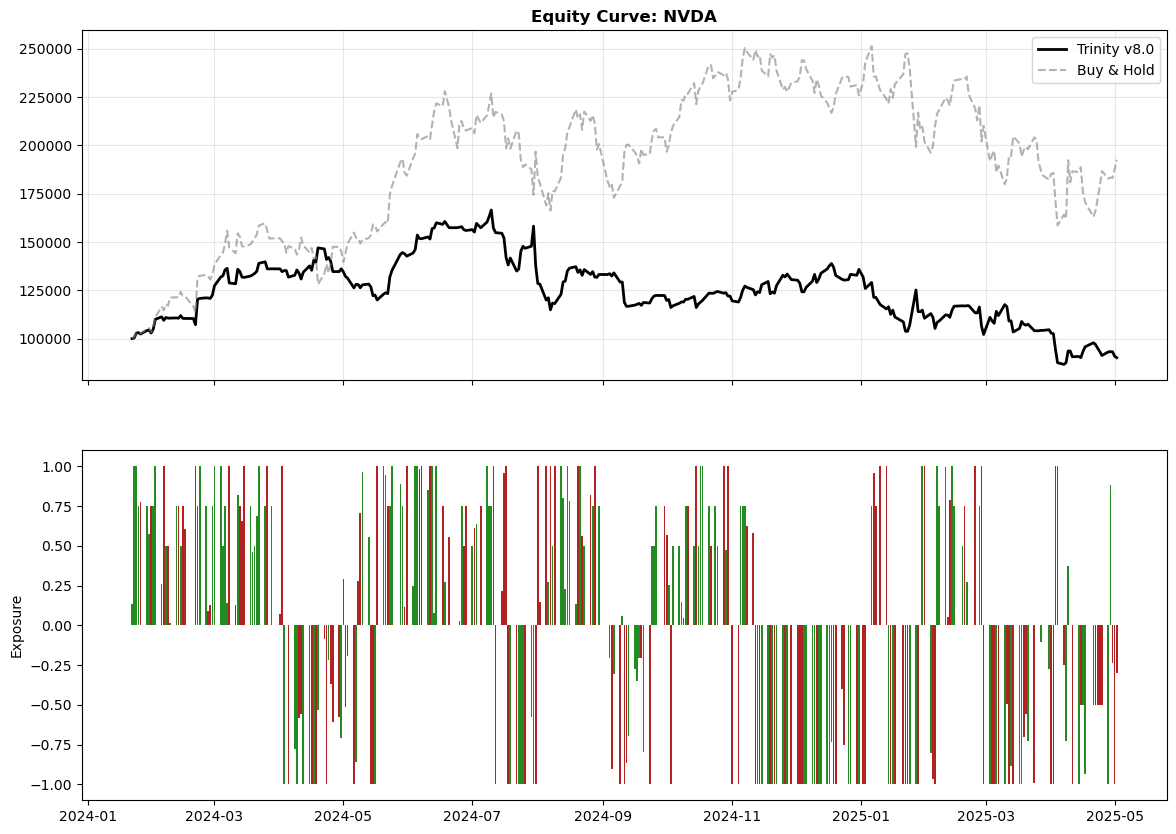

In [38]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v8.0) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31", 
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), 
        ("2020-01-01", "2020-05-01"), 
        ("2022-01-01", "2022-12-31"), 
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 60000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002, 
    
    # Execution Logic
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False
}

# --- DATA PROCESSOR (v8.0 Split Views) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        
        # --- BASE FEATURES ---
        df['returns'] = df[target].pct_change()
        df['log_ret'] = np.log(df[target] / df[target].shift(1))
        
        # --- TREND FEATURES (For Trend Agent) ---
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        # ADX Calculation...
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # --- OSCILLATOR FEATURES (For Accumulation Agent) ---
        # RSI
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        # Bollinger %B
        sma20 = df[target].rolling(20).mean()
        std20 = df[target].rolling(20).std()
        df['pct_b'] = (df[target] - (sma20 - 2*std20)) / (4*std20 + 1e-9)
        df['bb_width'] = (4 * std20) / (sma20 + 1e-9)
        
        # Detrended Price Oscillator (Proxy)
        df['dpo'] = df[target] - df[target].shift(int(20/2 + 1)).rolling(20).mean()
        
        # --- CRISIS FEATURES ---
        df['l_stat'] = self.calculate_lee_mykland(df[target], window=20)
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        # Z-Score of SMA Distance (Panic Metric)
        dist_mean = df['dist_sma200'].rolling(252).mean()
        dist_std = df['dist_sma200'].rolling(252).std()
        df['z_score_sma'] = (df['dist_sma200'] - dist_mean) / (dist_std + 1e-9)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v8.0 - Split Observation Space) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.data_vals = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        
        # --- FEATURE SELECTION BASED ON MODE ---
        if self.mode == 'accumulation':
            # Accumulation agent ONLY sees Oscillators. Blind to Trend.
            # Features: RSI, %B, BB Width, DPO, Volatility
            self.obs_cols = ['rsi', 'pct_b', 'bb_width', 'dpo', 'realized_vol_20d']
        else:
            # Trend/Crisis see Macro structure
            # Features: Returns, SMA Dist, ADX, Jump Stat, Volatility
            self.obs_cols = ['returns', 'dist_sma200', 'adx', 'l_stat', 'realized_vol_20d']
            
        self.obs_indices = [self.cols.index(c) for c in self.obs_cols]
        self.n_features = len(self.obs_cols)
        
        # Global indices for rewards
        self.idx_ret = self.cols.index('returns')
        self.idx_sma = self.cols.index('dist_sma200')
        self.idx_rsi = self.cols.index('rsi')
        self.idx_adx = self.cols.index('adx')
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        return self._get_obs(), {}
    
    def _get_obs(self):
        # Select specific features for this specialist
        obs_window = self.data_vals[self.current_step-self.window : self.current_step, self.obs_indices]
        return obs_window.flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data_vals[self.current_step, self.idx_ret] 
        rsi = self.data_vals[self.current_step, self.idx_rsi]
        sma_dist = self.data_vals[self.current_step, self.idx_sma]
        adx = self.data_vals[self.current_step, self.idx_adx]
        
        reward = 0
        
        if self.mode == 'trend':
            reward = act * ret * 100
            # Standard Trend Following Logic
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            # Whipsaw: Only penalize buying overbought if Trend is Weak
            if act > 0.5 and rsi > 85 and adx < 0.25: reward -= 0.5 
            if act < -0.5 and rsi < 15 and adx < 0.25: reward -= 0.5
                
        elif self.mode == 'accumulation': 
            # v8.0 BEHAVIORAL REWARDING
            # Ignore PnL noise. Reward "Buying Value" and "Selling Premium".
            
            # 1. The Value Factor Reward
            # If price < SMA (Negative Dist), Longs are good.
            # If price > SMA (Positive Dist), Shorts are good.
            # We invert sma_dist so negative dist * positive act = negative? No.
            # We want: (SMA - Price). If positive, Buy.
            # SMA - Price ~ -dist_sma200
            
            value_signal = -sma_dist # Positive if Price < SMA
            reward += (act * value_signal * 10.0) # Reward alignment with Value
            
            # 2. Oscillator Limits
            if rsi < 30: reward += act * 1.0 # Reward Longs
            if rsi > 70: reward -= act * 1.0 # Reward Shorts (negative act)
            
            # 3. Holding Tax (Reduced)
            reward -= 0.01 * abs(act) # Small tax to prevent camping

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 5.0)
            
            # Penalize Longs in Bear Market
            if sma_dist < 0 and act > 0: reward -= 0.1 * act
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v8.0) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
    def train_specialists(self, verbose=True):
        if verbose: print(f"\n=== TRAINING SPECIALIST AGENTS (Win={self.config['WINDOW_SIZE']}) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            # Note: Env now handles observation space internally based on mode
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO("MlpPolicy", env, verbose=0, learning_rate=self.config['LEARNING_RATE'], batch_size=self.config['BATCH_SIZE'])
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return -999.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return -999.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        # Indices
        cols = full_data.columns.tolist()
        idx_ret = cols.index('returns')
        idx_vol = cols.index('realized_vol_20d')
        idx_rsi = cols.index('rsi')
        
        # Helper for Gating
        idx_l_stat = cols.index('l_stat')
        idx_vol_pct = cols.index('vol_percentile')
        idx_adx = cols.index('adx')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_sma = cols.index('dist_sma200')
        idx_z_score = cols.index('z_score_sma')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            # Prepare Obs Row for Normalization
            # We must reconstruct the specific feature subset for the active agent
            current_slice = data_vals[t-window : t]
            
            # --- GATING LOGIC ---
            # Features for gating
            l_stat = data_vals[t-1, idx_l_stat]
            vol_pct = data_vals[t-1, idx_vol_pct]
            adx = data_vals[t-1, idx_adx]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            sma_dist = data_vals[t-1, idx_sma]
            z_score = data_vals[t-1, idx_z_score]
            
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist > 0: regime, active_agent_name = "MANIA_MODE", "trend"
                else:
                    if z_score < -1.5: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                    else: regime, active_agent_name = "BEAR_VOLATILITY", "crisis"
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
            
            # --- PREDICTION ---
            # 1. Get correct indices for this agent's view
            temp_env = self.envs[active_agent_name].venv.envs[0] # Access internal env
            indices = temp_env.obs_indices
            
            # 2. Extract and Flatten
            obs_raw = current_slice[:, indices].flatten()
            
            # 3. Normalize & Predict
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = self.agents[active_agent_name].predict(obs_norm, deterministic=True)
            raw_action = action[0]
            
            # --- EXECUTION LOGIC (v8.0) ---
            
            # 1. Regime Scaler
            regime_scaler = 1.0
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.3: regime_scaler = 1.5 
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 2.0 
            
            # 2. Panic Button
            rsi = data_vals[t-1, idx_rsi]
            if regime == 'CRISIS_PANIC':
                if rsi < 30: raw_action = 0.0 
                elif raw_action > -0.5: raw_action = -0.5 
            
            # 3. Overrides
            mkt_ret = data_vals[t, idx_ret]
            if regime == 'JUMP_BULL': raw_action = 1.0
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0 and mkt_ret > -0.02: raw_action = 0.5 
            
            # 4. Volatility Sizing (Adjusted)
            raw_vol = data_vals[t-1, idx_vol]
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                # v8.0: Less aggressive de-leveraging on high conviction
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            target_action = raw_action * regime_scaler * vol_scaler
            
            # 5. Safety Clips
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: target_action = np.clip(target_action, -10, 0)
                elif sma_dist > 0: target_action = np.clip(target_action, 0, 10)
            
            position_size = np.clip(target_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # PnL
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Raw Act': raw_action
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret

    def plot_dashboard(self, res):
        fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v8.0', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.grid(True, alpha=0.3)
        ax0.legend()

        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        axes[1].bar(res.index, res['Scale Act'], color=colors)
        axes[1].set_ylabel("Exposure")
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end 
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | {params}")
                
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V8.0 (FINAL) <<<")
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["NVDA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "NVDA"
    START = "2024-01-22"
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)

## Fix seed


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR NVDA <<<
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 40.86% | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 54.50% | {'ADX_THRESHOLD': 25, 'JUMP_THRESHOLD': 3.5}

>>> INITIALIZING TRINITY V8.1 (FINAL) <<<

=== TRAINING SPECIALIST AGENTS (Win=60) ===
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['NVD

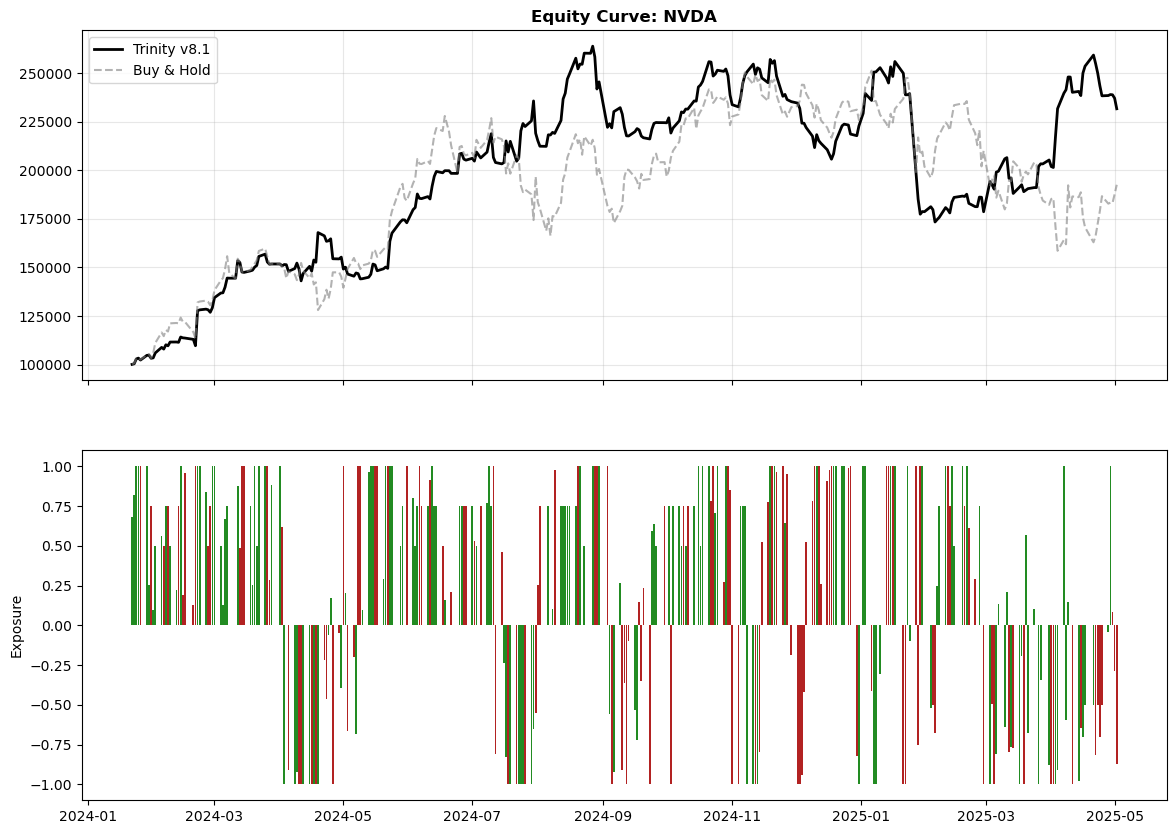

In [39]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings
import random
import torch

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v8.1) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31", 
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), 
        ("2020-01-01", "2020-05-01"), 
        ("2022-01-01", "2022-12-31"), 
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 80000, # Increased for stability
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002,
    "SEED": 42, # Reproducibility
    
    # Execution Logic
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False
}

# --- DATA PROCESSOR (v8.1) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        
        # --- BASE FEATURES ---
        df['returns'] = df[target].pct_change()
        df['log_ret'] = np.log(df[target] / df[target].shift(1))
        
        # --- TREND FEATURES ---
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # --- OSCILLATOR FEATURES ---
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        sma20 = df[target].rolling(20).mean()
        std20 = df[target].rolling(20).std()
        df['pct_b'] = (df[target] - (sma20 - 2*std20)) / (4*std20 + 1e-9)
        df['bb_width'] = (4 * std20) / (sma20 + 1e-9)
        
        df['dpo'] = df[target] - df[target].shift(int(20/2 + 1)).rolling(20).mean()
        
        # --- CRISIS FEATURES ---
        df['l_stat'] = self.calculate_lee_mykland(df[target], window=20)
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        dist_mean = df['dist_sma200'].rolling(252).mean()
        dist_std = df['dist_sma200'].rolling(252).std()
        df['z_score_sma'] = (df['dist_sma200'] - dist_mean) / (dist_std + 1e-9)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v8.1 - Fixed Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.data_vals = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        
        if self.mode == 'accumulation':
            self.obs_cols = ['rsi', 'pct_b', 'bb_width', 'dpo', 'realized_vol_20d']
        else:
            self.obs_cols = ['returns', 'dist_sma200', 'adx', 'l_stat', 'realized_vol_20d']
            
        self.obs_indices = [self.cols.index(c) for c in self.obs_cols]
        self.n_features = len(self.obs_cols)
        
        self.idx_ret = self.cols.index('returns')
        self.idx_sma = self.cols.index('dist_sma200')
        self.idx_rsi = self.cols.index('rsi')
        self.idx_adx = self.cols.index('adx')
        self.idx_pct_b = self.cols.index('pct_b')
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        return self._get_obs(), {}
    
    def _get_obs(self):
        obs_window = self.data_vals[self.current_step-self.window : self.current_step, self.obs_indices]
        return obs_window.flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data_vals[self.current_step, self.idx_ret] 
        rsi = self.data_vals[self.current_step, self.idx_rsi]
        sma_dist = self.data_vals[self.current_step, self.idx_sma]
        adx = self.data_vals[self.current_step, self.idx_adx]
        pct_b = self.data_vals[self.current_step, self.idx_pct_b]
        
        reward = 0
        
        if self.mode == 'trend':
            reward = act * ret * 100
            # Conviction Bonus
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            # Whipsaw Protection (Weak Trend + Extreme RSI = Danger)
            if act > 0.5 and rsi > 85 and adx < 0.25: reward -= 0.5 
            if act < -0.5 and rsi < 15 and adx < 0.25: reward -= 0.5
                
        elif self.mode == 'accumulation': 
            # v8.1 FIX: Removed SMA-based penalty
            reward = act * ret * 100
            
            # Pure Oscillator Logic
            # Buy the dip (RSI < 30 or Price below Lower BB)
            if rsi < 30 or pct_b < 0: 
                reward += act * 1.0 
            
            # Sell the rip (RSI > 70 or Price above Upper BB)
            if rsi > 70 or pct_b > 1: 
                reward -= act * 1.0 # Encourages negative action (Short)
            
            reward -= 0.01 * abs(act) 

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 5.0)
            
            # Penalize Longs in Bear Market
            if sma_dist < 0 and act > 0: reward -= 0.1 * act
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v8.1 Seeded) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
        # Set Global Seeds
        seed = config.get('SEED', 42)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    def train_specialists(self, verbose=True):
        if verbose: print(f"\n=== TRAINING SPECIALIST AGENTS (Win={self.config['WINDOW_SIZE']}) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO("MlpPolicy", env, verbose=0, learning_rate=self.config['LEARNING_RATE'], batch_size=self.config['BATCH_SIZE'], seed=self.config['SEED'])
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return -999.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return -999.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        cols = full_data.columns.tolist()
        idx_ret = cols.index('returns')
        idx_vol = cols.index('realized_vol_20d')
        idx_rsi = cols.index('rsi')
        
        idx_l_stat = cols.index('l_stat')
        idx_vol_pct = cols.index('vol_percentile')
        idx_adx = cols.index('adx')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_sma = cols.index('dist_sma200')
        idx_z_score = cols.index('z_score_sma')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            current_slice = data_vals[t-window : t]
            
            l_stat = data_vals[t-1, idx_l_stat]
            vol_pct = data_vals[t-1, idx_vol_pct]
            adx = data_vals[t-1, idx_adx]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            sma_dist = data_vals[t-1, idx_sma]
            z_score = data_vals[t-1, idx_z_score]
            
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist > 0: regime, active_agent_name = "MANIA_MODE", "trend"
                else:
                    if z_score < -1.5: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                    else: regime, active_agent_name = "BEAR_VOLATILITY", "crisis"
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
            
            temp_env = self.envs[active_agent_name].venv.envs[0]
            indices = temp_env.obs_indices
            obs_raw = current_slice[:, indices].flatten()
            
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = self.agents[active_agent_name].predict(obs_norm, deterministic=True)
            raw_action = action[0]
            
            regime_scaler = 1.0
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.3: regime_scaler = 1.5 
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 2.0 
            
            rsi = data_vals[t-1, idx_rsi]
            if regime == 'CRISIS_PANIC':
                if rsi < 30: raw_action = 0.0 
                elif raw_action > -0.5: raw_action = -0.5 
            
            mkt_ret = data_vals[t, idx_ret]
            if regime == 'JUMP_BULL': raw_action = 1.0
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0 and mkt_ret > -0.02: raw_action = 0.5 
            
            raw_vol = data_vals[t-1, idx_vol]
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            target_action = raw_action * regime_scaler * vol_scaler
            
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: target_action = np.clip(target_action, -10, 0)
                elif sma_dist > 0: target_action = np.clip(target_action, 0, 10)
            
            position_size = np.clip(target_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Raw Act': raw_action
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret

    def plot_dashboard(self, res):
        fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v8.1', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.grid(True, alpha=0.3)
        ax0.legend()

        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        axes[1].bar(res.index, res['Scale Act'], color=colors)
        axes[1].set_ylabel("Exposure")
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end 
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | {params}")
                
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V8.1 (FINAL) <<<")
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["NVDA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "NVDA"
    START = "2024-01-22"
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR TSLA <<<
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 46.92% | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 50.62% | {'ADX_THRESHOLD': 25, 'JUMP_THRESHOLD': 3.5}

>>> INITIALIZING TRINITY V8.1 (FINAL) <<<

=== TRAINING SPECIALIST AGENTS (Win=60) ===
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['TSL

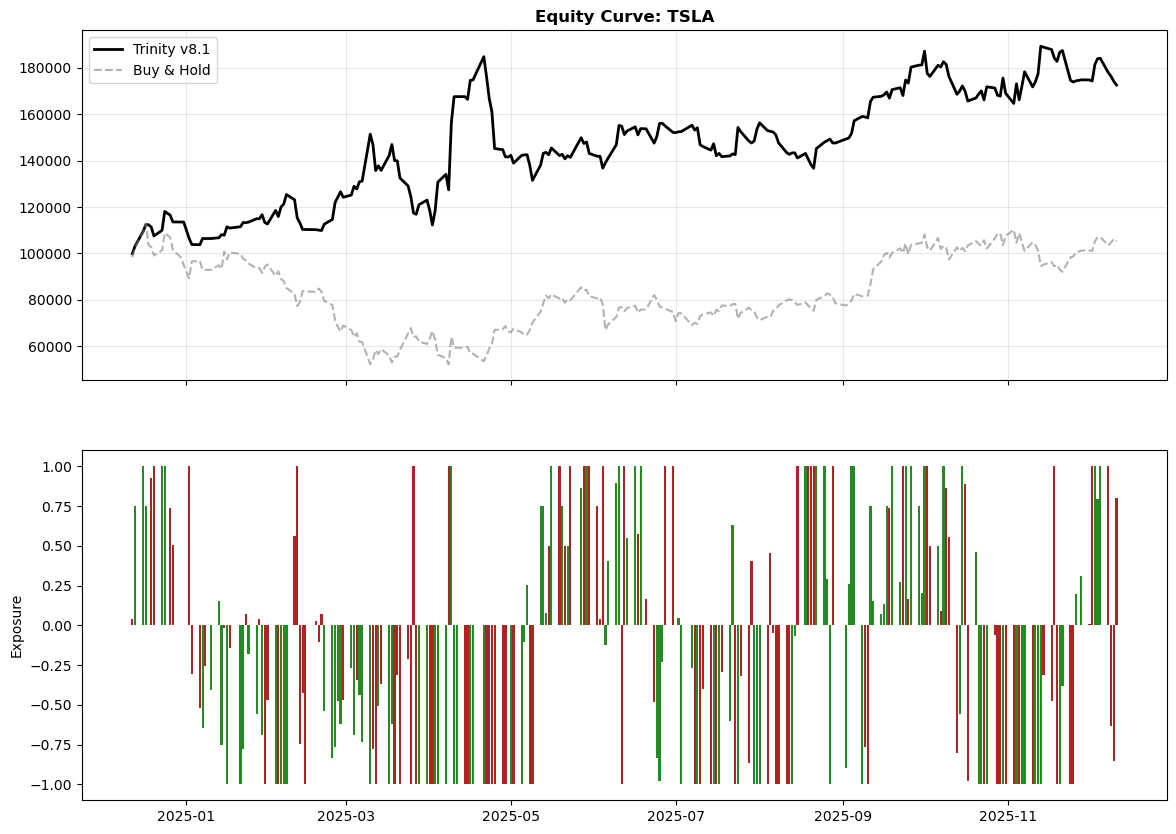

In [40]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings
import random
import torch

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v8.1) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31", 
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), 
        ("2020-01-01", "2020-05-01"), 
        ("2022-01-01", "2022-12-31"), 
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 80000, # Increased for stability
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002,
    "SEED": 42, # Reproducibility
    
    # Execution Logic
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False
}

# --- DATA PROCESSOR (v8.1) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        
        # --- BASE FEATURES ---
        df['returns'] = df[target].pct_change()
        df['log_ret'] = np.log(df[target] / df[target].shift(1))
        
        # --- TREND FEATURES ---
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # --- OSCILLATOR FEATURES ---
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        sma20 = df[target].rolling(20).mean()
        std20 = df[target].rolling(20).std()
        df['pct_b'] = (df[target] - (sma20 - 2*std20)) / (4*std20 + 1e-9)
        df['bb_width'] = (4 * std20) / (sma20 + 1e-9)
        
        df['dpo'] = df[target] - df[target].shift(int(20/2 + 1)).rolling(20).mean()
        
        # --- CRISIS FEATURES ---
        df['l_stat'] = self.calculate_lee_mykland(df[target], window=20)
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        dist_mean = df['dist_sma200'].rolling(252).mean()
        dist_std = df['dist_sma200'].rolling(252).std()
        df['z_score_sma'] = (df['dist_sma200'] - dist_mean) / (dist_std + 1e-9)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v8.1 - Fixed Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.data_vals = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        
        if self.mode == 'accumulation':
            self.obs_cols = ['rsi', 'pct_b', 'bb_width', 'dpo', 'realized_vol_20d']
        else:
            self.obs_cols = ['returns', 'dist_sma200', 'adx', 'l_stat', 'realized_vol_20d']
            
        self.obs_indices = [self.cols.index(c) for c in self.obs_cols]
        self.n_features = len(self.obs_cols)
        
        self.idx_ret = self.cols.index('returns')
        self.idx_sma = self.cols.index('dist_sma200')
        self.idx_rsi = self.cols.index('rsi')
        self.idx_adx = self.cols.index('adx')
        self.idx_pct_b = self.cols.index('pct_b')
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        return self._get_obs(), {}
    
    def _get_obs(self):
        obs_window = self.data_vals[self.current_step-self.window : self.current_step, self.obs_indices]
        return obs_window.flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data_vals[self.current_step, self.idx_ret] 
        rsi = self.data_vals[self.current_step, self.idx_rsi]
        sma_dist = self.data_vals[self.current_step, self.idx_sma]
        adx = self.data_vals[self.current_step, self.idx_adx]
        pct_b = self.data_vals[self.current_step, self.idx_pct_b]
        
        reward = 0
        
        if self.mode == 'trend':
            reward = act * ret * 100
            # Conviction Bonus
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            # Whipsaw Protection (Weak Trend + Extreme RSI = Danger)
            if act > 0.5 and rsi > 85 and adx < 0.25: reward -= 0.5 
            if act < -0.5 and rsi < 15 and adx < 0.25: reward -= 0.5
                
        elif self.mode == 'accumulation': 
            # v8.1 FIX: Removed SMA-based penalty
            reward = act * ret * 100
            
            # Pure Oscillator Logic
            # Buy the dip (RSI < 30 or Price below Lower BB)
            if rsi < 30 or pct_b < 0: 
                reward += act * 1.0 
            
            # Sell the rip (RSI > 70 or Price above Upper BB)
            if rsi > 70 or pct_b > 1: 
                reward -= act * 1.0 # Encourages negative action (Short)
            
            reward -= 0.01 * abs(act) 

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 5.0)
            
            # Penalize Longs in Bear Market
            if sma_dist < 0 and act > 0: reward -= 0.1 * act
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v8.1 Seeded) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
        # Set Global Seeds
        seed = config.get('SEED', 42)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    def train_specialists(self, verbose=True):
        if verbose: print(f"\n=== TRAINING SPECIALIST AGENTS (Win={self.config['WINDOW_SIZE']}) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO("MlpPolicy", env, verbose=0, learning_rate=self.config['LEARNING_RATE'], batch_size=self.config['BATCH_SIZE'], seed=self.config['SEED'])
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return -999.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return -999.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        cols = full_data.columns.tolist()
        idx_ret = cols.index('returns')
        idx_vol = cols.index('realized_vol_20d')
        idx_rsi = cols.index('rsi')
        
        idx_l_stat = cols.index('l_stat')
        idx_vol_pct = cols.index('vol_percentile')
        idx_adx = cols.index('adx')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_sma = cols.index('dist_sma200')
        idx_z_score = cols.index('z_score_sma')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            current_slice = data_vals[t-window : t]
            
            l_stat = data_vals[t-1, idx_l_stat]
            vol_pct = data_vals[t-1, idx_vol_pct]
            adx = data_vals[t-1, idx_adx]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            sma_dist = data_vals[t-1, idx_sma]
            z_score = data_vals[t-1, idx_z_score]
            
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist > 0: regime, active_agent_name = "MANIA_MODE", "trend"
                else:
                    if z_score < -1.5: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                    else: regime, active_agent_name = "BEAR_VOLATILITY", "crisis"
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
            
            temp_env = self.envs[active_agent_name].venv.envs[0]
            indices = temp_env.obs_indices
            obs_raw = current_slice[:, indices].flatten()
            
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = self.agents[active_agent_name].predict(obs_norm, deterministic=True)
            raw_action = action[0]
            
            regime_scaler = 1.0
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.3: regime_scaler = 1.5 
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 2.0 
            
            rsi = data_vals[t-1, idx_rsi]
            if regime == 'CRISIS_PANIC':
                if rsi < 30: raw_action = 0.0 
                elif raw_action > -0.5: raw_action = -0.5 
            
            mkt_ret = data_vals[t, idx_ret]
            if regime == 'JUMP_BULL': raw_action = 1.0
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0 and mkt_ret > -0.02: raw_action = 0.5 
            
            raw_vol = data_vals[t-1, idx_vol]
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            target_action = raw_action * regime_scaler * vol_scaler
            
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: target_action = np.clip(target_action, -10, 0)
                elif sma_dist > 0: target_action = np.clip(target_action, 0, 10)
            
            position_size = np.clip(target_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Raw Act': raw_action
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret

    def plot_dashboard(self, res):
        fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v8.1', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.grid(True, alpha=0.3)
        ax0.legend()

        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        axes[1].bar(res.index, res['Scale Act'], color=colors)
        axes[1].set_ylabel("Exposure")
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end 
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | {params}")
                
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V8.1 (FINAL) <<<")
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["TSLA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "TSLA"
    START = "2024-12-12"
    END = "2025-12-12"
    
    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR TSLA <<<
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 1.52% | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 10.56% | {'ADX_THRESHOLD': 25, 'JUMP_THRESHOLD': 3.5}

>>> INITIALIZING TRINITY V8.1 (FINAL) <<<

=== TRAINING SPECIALIST AGENTS (Win=60) ===
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['TSLA

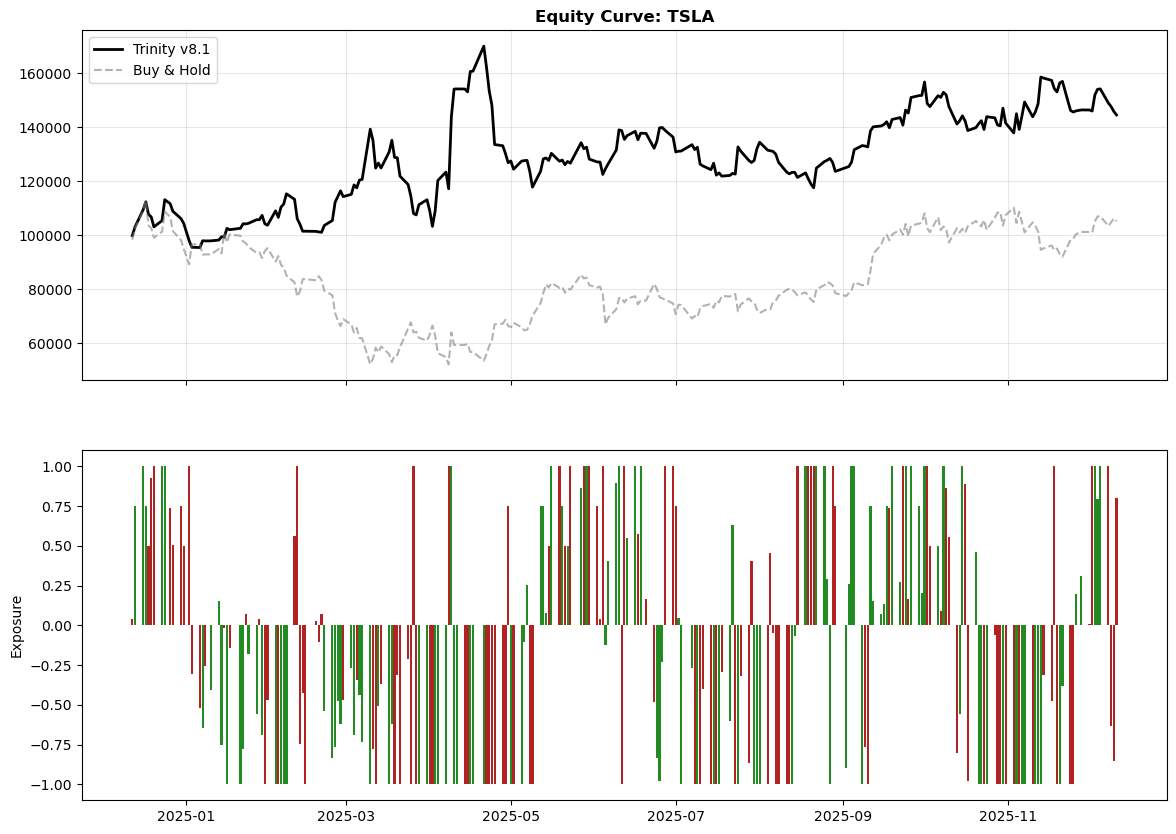

In [41]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings
import random
import torch

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v8.1) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31", 
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), 
        ("2020-01-01", "2020-05-01"), 
        ("2022-01-01", "2022-12-31"), 
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 80000, # Increased for stability
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002,
    "SEED": 42, # Reproducibility
    
    # Execution Logic
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False
}

# --- DATA PROCESSOR (v8.1) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            # Flatten multi-index if necessary (yfinance update compatibility)
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                # prioritize Adj Close, fallback to Close
                try:
                    data = data.xs('Adj Close', level=0, axis=1)
                except KeyError:
                    try:
                        data = data.xs('Close', level=0, axis=1)
                    except KeyError:
                         # Handle cases where level 0 is Ticker and level 1 is Price Type
                        if 'Close' in data.columns.levels[1]:
                             data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            # Ensure OHLC is single level
            if isinstance(ohlc.columns, pd.MultiIndex):
                 ohlc.columns = ohlc.columns.droplevel(1)

            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        
        # --- BASE FEATURES ---
        df['returns'] = df[target].pct_change()
        df['log_ret'] = np.log(df[target] / df[target].shift(1))
        
        # --- TREND FEATURES ---
        # Ensure alignment
        common_idx = df.index.intersection(ohlc.index)
        high = ohlc.loc[common_idx, 'High']
        low = ohlc.loc[common_idx, 'Low']
        close = ohlc.loc[common_idx, 'Close']
        df = df.loc[common_idx]
        
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # --- OSCILLATOR FEATURES ---
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        sma20 = df[target].rolling(20).mean()
        std20 = df[target].rolling(20).std()
        df['pct_b'] = (df[target] - (sma20 - 2*std20)) / (4*std20 + 1e-9)
        df['bb_width'] = (4 * std20) / (sma20 + 1e-9)
        
        # DPO: Shifted positive is lag (safe), shifted negative is lookahead. 
        # Original code used positive shift (safe).
        df['dpo'] = df[target] - df[target].shift(int(20/2 + 1)).rolling(20).mean()
        
        # --- CRISIS FEATURES ---
        df['l_stat'] = self.calculate_lee_mykland(df[target], window=20)
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        dist_mean = df['dist_sma200'].rolling(252).mean()
        dist_std = df['dist_sma200'].rolling(252).std()
        df['z_score_sma'] = (df['dist_sma200'] - dist_mean) / (dist_std + 1e-9)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v8.1 - Fixed Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.data_vals = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        
        if self.mode == 'accumulation':
            self.obs_cols = ['rsi', 'pct_b', 'bb_width', 'dpo', 'realized_vol_20d']
        else:
            self.obs_cols = ['returns', 'dist_sma200', 'adx', 'l_stat', 'realized_vol_20d']
            
        self.obs_indices = [self.cols.index(c) for c in self.obs_cols]
        self.n_features = len(self.obs_cols)
        
        self.idx_ret = self.cols.index('returns')
        self.idx_sma = self.cols.index('dist_sma200')
        self.idx_rsi = self.cols.index('rsi')
        self.idx_adx = self.cols.index('adx')
        self.idx_pct_b = self.cols.index('pct_b')
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        return self._get_obs(), {}
    
    def _get_obs(self):
        obs_window = self.data_vals[self.current_step-self.window : self.current_step, self.obs_indices]
        return obs_window.flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data_vals[self.current_step, self.idx_ret] 
        rsi = self.data_vals[self.current_step, self.idx_rsi]
        sma_dist = self.data_vals[self.current_step, self.idx_sma]
        adx = self.data_vals[self.current_step, self.idx_adx]
        pct_b = self.data_vals[self.current_step, self.idx_pct_b]
        
        reward = 0
        
        if self.mode == 'trend':
            reward = act * ret * 100
            # Conviction Bonus
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            # Whipsaw Protection (Weak Trend + Extreme RSI = Danger)
            if act > 0.5 and rsi > 85 and adx < 0.25: reward -= 0.5 
            if act < -0.5 and rsi < 15 and adx < 0.25: reward -= 0.5
                
        elif self.mode == 'accumulation': 
            # v8.1 FIX: Removed SMA-based penalty
            reward = act * ret * 100
            
            # Pure Oscillator Logic
            # Buy the dip (RSI < 30 or Price below Lower BB)
            if rsi < 30 or pct_b < 0: 
                reward += act * 1.0 
            
            # Sell the rip (RSI > 70 or Price above Upper BB)
            if rsi > 70 or pct_b > 1: 
                reward -= act * 1.0 # Encourages negative action (Short)
            
            reward -= 0.01 * abs(act) 

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 5.0)
            
            # Penalize Longs in Bear Market
            if sma_dist < 0 and act > 0: reward -= 0.1 * act
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v8.1 Seeded) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
        # Set Global Seeds
        seed = config.get('SEED', 42)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    def train_specialists(self, verbose=True):
        if verbose: print(f"\n=== TRAINING SPECIALIST AGENTS (Win={self.config['WINDOW_SIZE']}) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            if data_source.empty:
                print(f"Warning: No data for {mode} training. Skipping.")
                continue

            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO("MlpPolicy", env, verbose=0, learning_rate=self.config['LEARNING_RATE'], batch_size=self.config['BATCH_SIZE'], seed=self.config['SEED'])
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return -999.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return -999.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        cols = full_data.columns.tolist()
        idx_ret = cols.index('returns')
        idx_vol = cols.index('realized_vol_20d')
        idx_rsi = cols.index('rsi')
        
        idx_l_stat = cols.index('l_stat')
        idx_vol_pct = cols.index('vol_percentile')
        idx_adx = cols.index('adx')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_sma = cols.index('dist_sma200')
        idx_z_score = cols.index('z_score_sma')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        regime_stats = {k: {'days': 0, 'log_ret': 0.0, 'bench_log_ret': 0.0} for k in ['trend', 'accumulation', 'crisis']}
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            current_slice = data_vals[t-window : t]
            
            # NOTE: All these indicators are fetched from index t-1 (yesterday).
            # This is safe (no look-ahead).
            l_stat = data_vals[t-1, idx_l_stat]
            vol_pct = data_vals[t-1, idx_vol_pct]
            adx = data_vals[t-1, idx_adx]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            sma_dist = data_vals[t-1, idx_sma]
            z_score = data_vals[t-1, idx_z_score]
            
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist > 0: regime, active_agent_name = "MANIA_MODE", "trend"
                else:
                    if z_score < -1.5: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                    else: regime, active_agent_name = "BEAR_VOLATILITY", "crisis"
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
            
            # Ensure agent exists
            if active_agent_name not in self.envs:
                 active_agent_name = 'trend' # Fallback
            
            temp_env = self.envs[active_agent_name].venv.envs[0]
            indices = temp_env.obs_indices
            obs_raw = current_slice[:, indices].flatten()
            
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = self.agents[active_agent_name].predict(obs_norm, deterministic=True)
            raw_action = action[0]
            
            regime_scaler = 1.0
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.3: regime_scaler = 1.5 
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 2.0 
            
            rsi = data_vals[t-1, idx_rsi]
            if regime == 'CRISIS_PANIC':
                if rsi < 30: raw_action = 0.0 
                elif raw_action > -0.5: raw_action = -0.5 
            
            mkt_ret = data_vals[t, idx_ret]
            if regime == 'JUMP_BULL': raw_action = 1.0
            
            if active_agent_name == 'trend':
                # FIXED: Removed 'and mkt_ret > -0.02'. 
                # Checking future return (mkt_ret) to decide current action is look-ahead bias.
                if sma_dist > 0 and raw_action < 0: raw_action = 0.5 
            
            raw_vol = data_vals[t-1, idx_vol]
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            target_action = raw_action * regime_scaler * vol_scaler
            
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: target_action = np.clip(target_action, -10, 0)
                elif sma_dist > 0: target_action = np.clip(target_action, 0, 10)
            
            position_size = np.clip(target_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            regime_stats[active_agent_name]['days'] += 1
            regime_stats[active_agent_name]['log_ret'] += np.log1p(step_pnl_pct)
            regime_stats[active_agent_name]['bench_log_ret'] += np.log1p(mkt_ret)
            
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Raw Act': raw_action
            })
            
        if not history:
            return 0.0

        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret

    def plot_dashboard(self, res):
        fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v8.1', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        ax0.set_title(f"Equity Curve: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.grid(True, alpha=0.3)
        ax0.legend()

        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        axes[1].bar(res.index, res['Scale Act'], color=colors)
        axes[1].set_ylabel("Exposure")
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end 
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | {params}")
                
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V8.1 (FINAL) <<<")
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["TSLA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "TSLA"
    START = "2024-12-12"
    END = "2025-12-12"
    
    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR NVDA <<<
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 2.68% | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 17.97% | {'ADX_THRESHOLD': 25, 'JUMP_THRESHOLD': 3.5}

>>> INITIALIZING TRINITY V8.1 (FINAL) <<<

=== TRAINING SPECIALIST AGENTS (Win=60) ===
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['NVDA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['NVDA

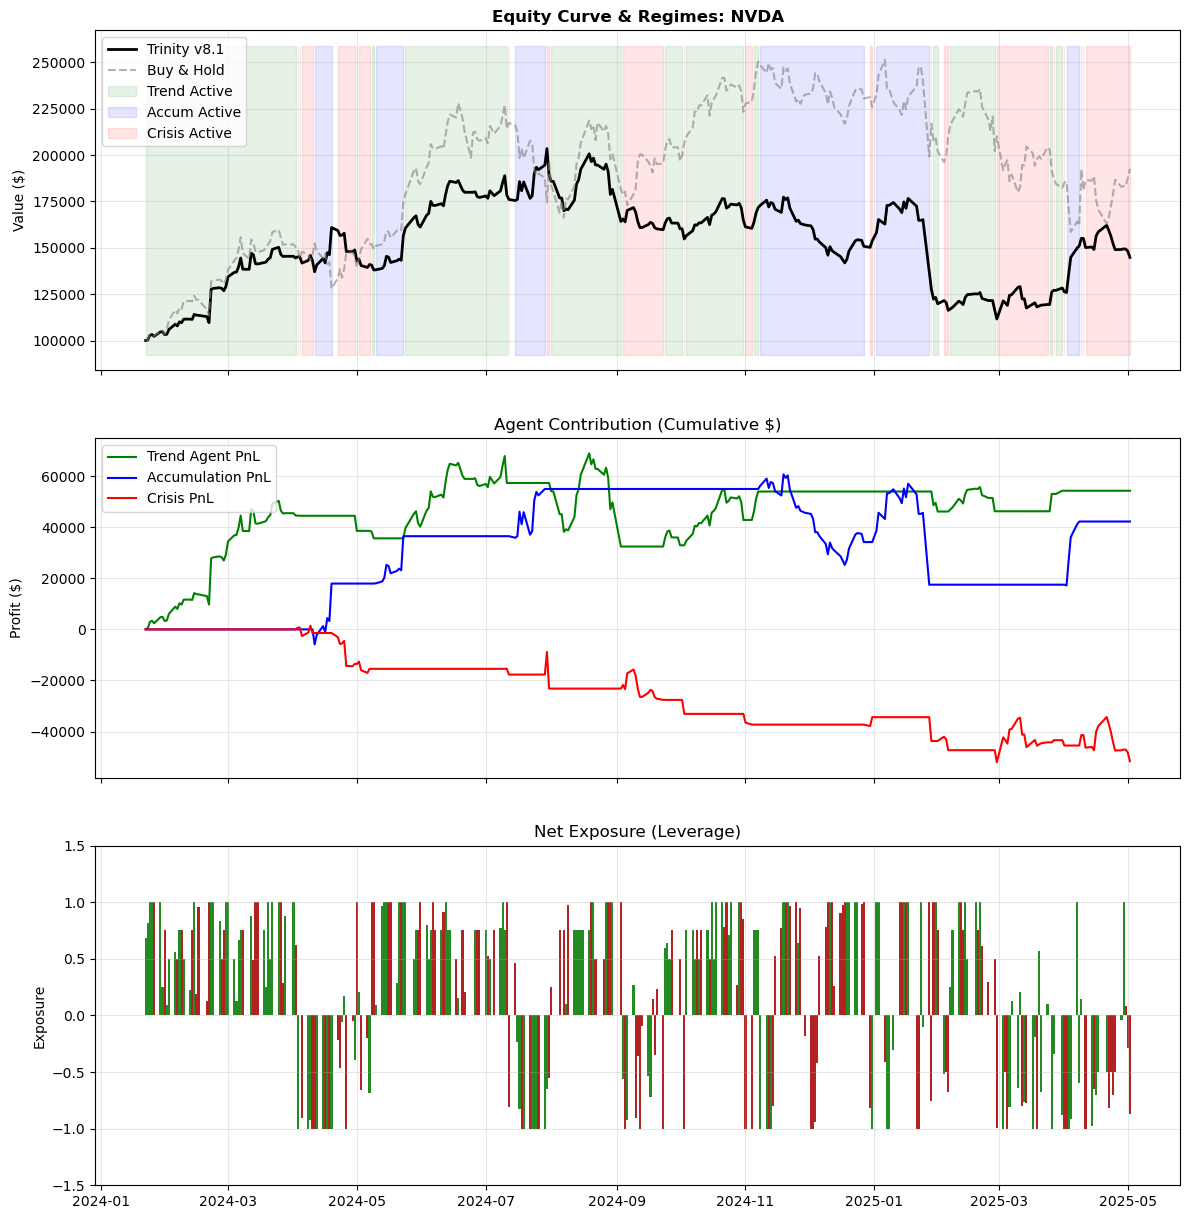

In [42]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings
import random
import torch

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v8.1) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31", 
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), 
        ("2020-01-01", "2020-05-01"), 
        ("2022-01-01", "2022-12-31"), 
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 80000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002,
    "SEED": 42, 
    
    # Execution Logic
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False
}

# --- DATA PROCESSOR (v8.1) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        
        # --- BASE FEATURES ---
        df['returns'] = df[target].pct_change()
        df['log_ret'] = np.log(df[target] / df[target].shift(1))
        
        # --- TREND FEATURES ---
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # --- OSCILLATOR FEATURES ---
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        sma20 = df[target].rolling(20).mean()
        std20 = df[target].rolling(20).std()
        df['pct_b'] = (df[target] - (sma20 - 2*std20)) / (4*std20 + 1e-9)
        df['bb_width'] = (4 * std20) / (sma20 + 1e-9)
        
        df['dpo'] = df[target] - df[target].shift(int(20/2 + 1)).rolling(20).mean()
        
        # --- CRISIS FEATURES ---
        df['l_stat'] = self.calculate_lee_mykland(df[target], window=20)
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        dist_mean = df['dist_sma200'].rolling(252).mean()
        dist_std = df['dist_sma200'].rolling(252).std()
        df['z_score_sma'] = (df['dist_sma200'] - dist_mean) / (dist_std + 1e-9)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v8.1 - Fixed Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.data_vals = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        
        if self.mode == 'accumulation':
            self.obs_cols = ['rsi', 'pct_b', 'bb_width', 'dpo', 'realized_vol_20d']
        else:
            self.obs_cols = ['returns', 'dist_sma200', 'adx', 'l_stat', 'realized_vol_20d']
            
        self.obs_indices = [self.cols.index(c) for c in self.obs_cols]
        self.n_features = len(self.obs_cols)
        
        self.idx_ret = self.cols.index('returns')
        self.idx_sma = self.cols.index('dist_sma200')
        self.idx_rsi = self.cols.index('rsi')
        self.idx_adx = self.cols.index('adx')
        self.idx_pct_b = self.cols.index('pct_b')
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        return self._get_obs(), {}
    
    def _get_obs(self):
        obs_window = self.data_vals[self.current_step-self.window : self.current_step, self.obs_indices]
        return obs_window.flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data_vals[self.current_step, self.idx_ret] 
        rsi = self.data_vals[self.current_step, self.idx_rsi]
        sma_dist = self.data_vals[self.current_step, self.idx_sma]
        adx = self.data_vals[self.current_step, self.idx_adx]
        pct_b = self.data_vals[self.current_step, self.idx_pct_b]
        
        reward = 0
        
        if self.mode == 'trend':
            reward = act * ret * 100
            # Conviction Bonus
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            # Whipsaw Protection
            if act > 0.5 and rsi > 85 and adx < 0.25: reward -= 0.5 
            if act < -0.5 and rsi < 15 and adx < 0.25: reward -= 0.5
                
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            
            # Pure Oscillator Logic
            if rsi < 30 or pct_b < 0: 
                reward += act * 1.0 
            if rsi > 70 or pct_b > 1: 
                reward -= act * 1.0 
            
            reward -= 0.01 * abs(act) 

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 5.0)
            
            if sma_dist < 0 and act > 0: reward -= 0.1 * act
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v8.1 Seeded & Fixes) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
        # Set Global Seeds
        seed = config.get('SEED', 42)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    def train_specialists(self, verbose=True):
        if verbose: print(f"\n=== TRAINING SPECIALIST AGENTS (Win={self.config['WINDOW_SIZE']}) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO("MlpPolicy", env, verbose=0, learning_rate=self.config['LEARNING_RATE'], batch_size=self.config['BATCH_SIZE'], seed=self.config['SEED'])
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return -999.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return -999.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        cols = full_data.columns.tolist()
        idx_ret = cols.index('returns')
        idx_vol = cols.index('realized_vol_20d')
        idx_rsi = cols.index('rsi')
        
        idx_l_stat = cols.index('l_stat')
        idx_vol_pct = cols.index('vol_percentile')
        idx_adx = cols.index('adx')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_sma = cols.index('dist_sma200')
        idx_z_score = cols.index('z_score_sma')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        # Tracking for plotting
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            current_slice = data_vals[t-window : t]
            
            # Gating Inputs (Available at t-1)
            l_stat = data_vals[t-1, idx_l_stat]
            vol_pct = data_vals[t-1, idx_vol_pct]
            adx = data_vals[t-1, idx_adx]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            sma_dist = data_vals[t-1, idx_sma]
            z_score = data_vals[t-1, idx_z_score]
            prev_ret = data_vals[t-1, idx_ret] # For Override logic
            
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist > 0: regime, active_agent_name = "MANIA_MODE", "trend"
                else:
                    if z_score < -1.5: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                    else: regime, active_agent_name = "BEAR_VOLATILITY", "crisis"
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
            
            temp_env = self.envs[active_agent_name].venv.envs[0]
            indices = temp_env.obs_indices
            obs_raw = current_slice[:, indices].flatten()
            
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = self.agents[active_agent_name].predict(obs_norm, deterministic=True)
            raw_action = action[0]
            
            regime_scaler = 1.0
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.3: regime_scaler = 1.5 
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 2.0 
            
            rsi = data_vals[t-1, idx_rsi]
            if regime == 'CRISIS_PANIC':
                if rsi < 30: raw_action = 0.0 
                elif raw_action > -0.5: raw_action = -0.5 
            
            # --- FIX: Removed Look-Ahead Bias ---
            # Used prev_ret (t-1) instead of mkt_ret (t)
            if regime == 'JUMP_BULL': raw_action = 1.0
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0 and prev_ret > -0.02: raw_action = 0.5 
            
            raw_vol = data_vals[t-1, idx_vol]
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            target_action = raw_action * regime_scaler * vol_scaler
            
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: target_action = np.clip(target_action, -10, 0)
                elif sma_dist > 0: target_action = np.clip(target_action, 0, 10)
            
            position_size = np.clip(target_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # Execution at T using Close T return (Backtest assumption)
            mkt_ret = data_vals[t, idx_ret] 
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats (Daily Alpha Calculation)
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Raw Act': raw_action,
                'Trend_PnL': agent_pnls['trend'],
                'Accumulation_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret

    def plot_dashboard(self, res):
        fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)
        plt.subplots_adjust(hspace=0.2)
        
        # 1. Equity Curve
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v8.1', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        
        # Active Agent Highlights
        y_min, y_max = ax0.get_ylim()
        is_trend = res['Agent'] == 'trend'
        is_accum = res['Agent'] == 'accumulation'
        is_crisis = res['Agent'] == 'crisis'
        
        ax0.fill_between(res.index, y_min, y_max, where=is_trend, color='green', alpha=0.1, label='Trend Active')
        ax0.fill_between(res.index, y_min, y_max, where=is_accum, color='blue', alpha=0.1, label='Accum Active')
        ax0.fill_between(res.index, y_min, y_max, where=is_crisis, color='red', alpha=0.1, label='Crisis Active')
        
        ax0.set_title(f"Equity Curve & Regimes: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Value ($)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        # 2. Agent Cumulative PnL
        ax1 = axes[1]
        ax1.plot(res.index, res['Trend_PnL'], label='Trend Agent PnL', color='green')
        ax1.plot(res.index, res['Accumulation_PnL'], label='Accumulation PnL', color='blue')
        ax1.plot(res.index, res['Crisis_PnL'], label='Crisis PnL', color='red')
        ax1.set_title("Agent Contribution (Cumulative $)")
        ax1.set_ylabel("Profit ($)")
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc='upper left')

        # 3. Exposure
        ax2 = axes[2]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax2.bar(res.index, res['Scale Act'], color=colors, width=1.0)
        ax2.set_title("Net Exposure (Leverage)")
        ax2.set_ylabel("Exposure")
        ax2.set_ylim(-1.5, 1.5)
        ax2.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end 
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | {params}")
                
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V8.1 (FINAL) <<<")
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["NVDA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "NVDA"
    START = "2024-01-22"
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR TSLA <<<
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 11.40% | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 21.32% | {'ADX_THRESHOLD': 25, 'JUMP_THRESHOLD': 3.5}

>>> INITIALIZING TRINITY V8.1 (FINAL) <<<

=== TRAINING SPECIALIST AGENTS (Win=60) ===
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['TSLA', 'SHY', '^VIX', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['TSL

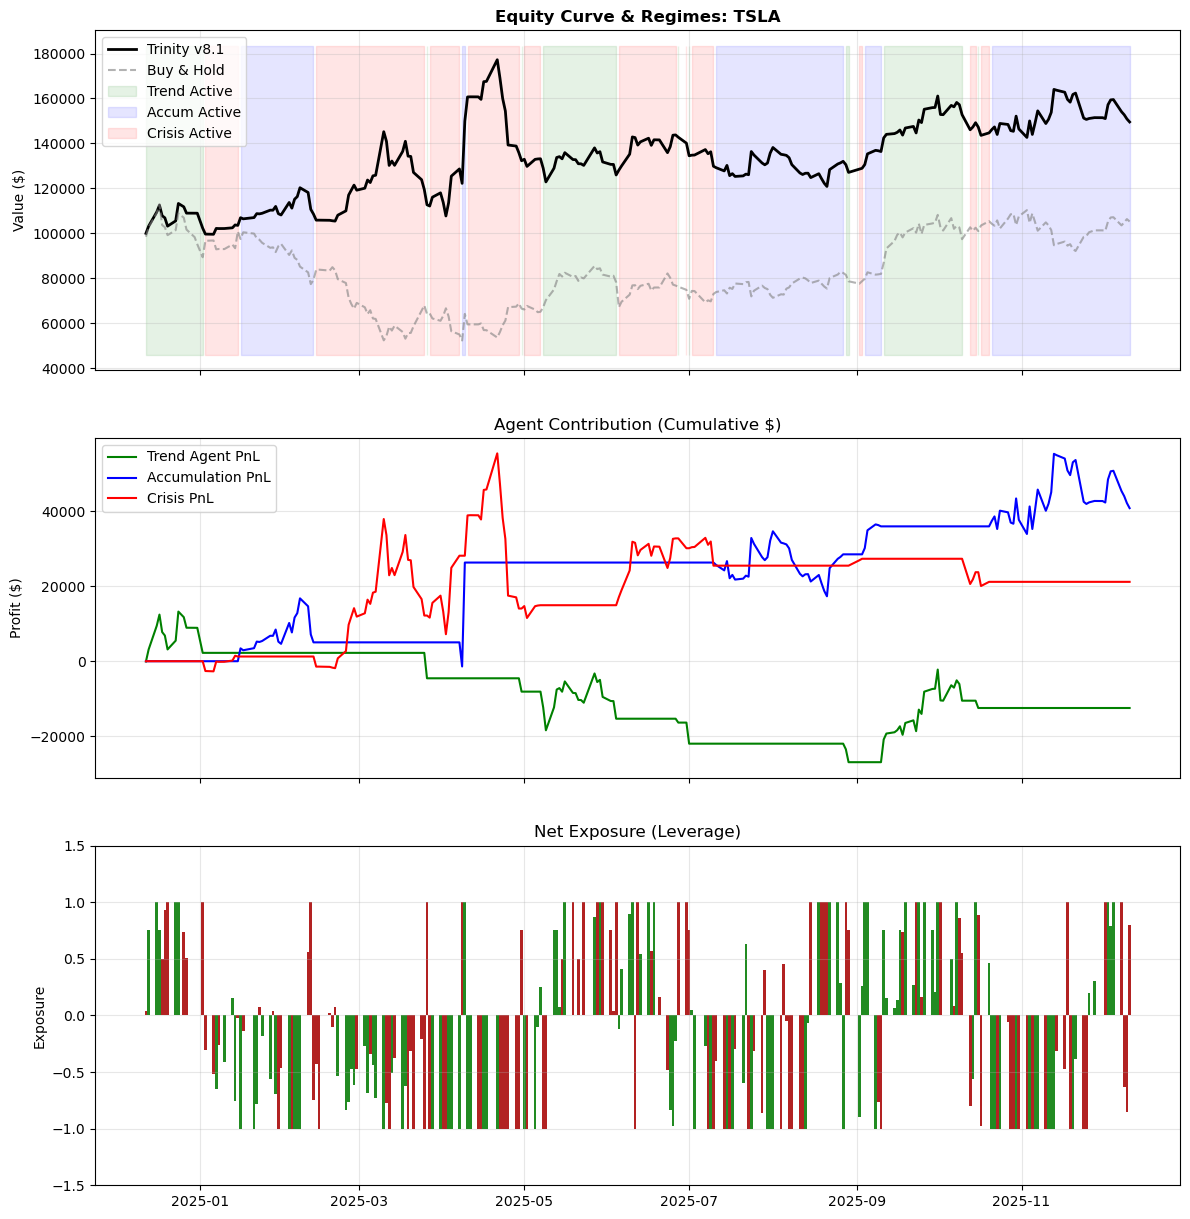

In [43]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings
import random
import torch

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v8.1) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31", 
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), 
        ("2020-01-01", "2020-05-01"), 
        ("2022-01-01", "2022-12-31"), 
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 80000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002,
    "SEED": 42, 
    
    # Execution Logic
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False
}

# --- DATA PROCESSOR (v8.1) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        
        # --- BASE FEATURES ---
        df['returns'] = df[target].pct_change()
        df['log_ret'] = np.log(df[target] / df[target].shift(1))
        
        # --- TREND FEATURES ---
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # --- OSCILLATOR FEATURES ---
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        sma20 = df[target].rolling(20).mean()
        std20 = df[target].rolling(20).std()
        df['pct_b'] = (df[target] - (sma20 - 2*std20)) / (4*std20 + 1e-9)
        df['bb_width'] = (4 * std20) / (sma20 + 1e-9)
        
        df['dpo'] = df[target] - df[target].shift(int(20/2 + 1)).rolling(20).mean()
        
        # --- CRISIS FEATURES ---
        df['l_stat'] = self.calculate_lee_mykland(df[target], window=20)
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        dist_mean = df['dist_sma200'].rolling(252).mean()
        dist_std = df['dist_sma200'].rolling(252).std()
        df['z_score_sma'] = (df['dist_sma200'] - dist_mean) / (dist_std + 1e-9)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v8.1 - Fixed Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.data_vals = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        
        if self.mode == 'accumulation':
            self.obs_cols = ['rsi', 'pct_b', 'bb_width', 'dpo', 'realized_vol_20d']
        else:
            self.obs_cols = ['returns', 'dist_sma200', 'adx', 'l_stat', 'realized_vol_20d']
            
        self.obs_indices = [self.cols.index(c) for c in self.obs_cols]
        self.n_features = len(self.obs_cols)
        
        self.idx_ret = self.cols.index('returns')
        self.idx_sma = self.cols.index('dist_sma200')
        self.idx_rsi = self.cols.index('rsi')
        self.idx_adx = self.cols.index('adx')
        self.idx_pct_b = self.cols.index('pct_b')
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        return self._get_obs(), {}
    
    def _get_obs(self):
        obs_window = self.data_vals[self.current_step-self.window : self.current_step, self.obs_indices]
        return obs_window.flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data_vals[self.current_step, self.idx_ret] 
        rsi = self.data_vals[self.current_step, self.idx_rsi]
        sma_dist = self.data_vals[self.current_step, self.idx_sma]
        adx = self.data_vals[self.current_step, self.idx_adx]
        pct_b = self.data_vals[self.current_step, self.idx_pct_b]
        
        reward = 0
        
        if self.mode == 'trend':
            reward = act * ret * 100
            # Conviction Bonus
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            # Whipsaw Protection
            if act > 0.5 and rsi > 85 and adx < 0.25: reward -= 0.5 
            if act < -0.5 and rsi < 15 and adx < 0.25: reward -= 0.5
                
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            
            # Pure Oscillator Logic
            if rsi < 30 or pct_b < 0: 
                reward += act * 1.0 
            if rsi > 70 or pct_b > 1: 
                reward -= act * 1.0 
            
            reward -= 0.01 * abs(act) 

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 5.0)
            
            if sma_dist < 0 and act > 0: reward -= 0.1 * act
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v8.1 Seeded & Fixes) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
        # Set Global Seeds
        seed = config.get('SEED', 42)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    def train_specialists(self, verbose=True):
        if verbose: print(f"\n=== TRAINING SPECIALIST AGENTS (Win={self.config['WINDOW_SIZE']}) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO("MlpPolicy", env, verbose=0, learning_rate=self.config['LEARNING_RATE'], batch_size=self.config['BATCH_SIZE'], seed=self.config['SEED'])
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return -999.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return -999.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        cols = full_data.columns.tolist()
        idx_ret = cols.index('returns')
        idx_vol = cols.index('realized_vol_20d')
        idx_rsi = cols.index('rsi')
        
        idx_l_stat = cols.index('l_stat')
        idx_vol_pct = cols.index('vol_percentile')
        idx_adx = cols.index('adx')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_sma = cols.index('dist_sma200')
        idx_z_score = cols.index('z_score_sma')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        # Tracking for plotting
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            current_slice = data_vals[t-window : t]
            
            # Gating Inputs (Available at t-1)
            l_stat = data_vals[t-1, idx_l_stat]
            vol_pct = data_vals[t-1, idx_vol_pct]
            adx = data_vals[t-1, idx_adx]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            sma_dist = data_vals[t-1, idx_sma]
            z_score = data_vals[t-1, idx_z_score]
            prev_ret = data_vals[t-1, idx_ret] # For Override logic
            
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist > 0: regime, active_agent_name = "MANIA_MODE", "trend"
                else:
                    if z_score < -1.5: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                    else: regime, active_agent_name = "BEAR_VOLATILITY", "crisis"
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
            
            temp_env = self.envs[active_agent_name].venv.envs[0]
            indices = temp_env.obs_indices
            obs_raw = current_slice[:, indices].flatten()
            
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = self.agents[active_agent_name].predict(obs_norm, deterministic=True)
            raw_action = action[0]
            
            regime_scaler = 1.0
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.3: regime_scaler = 1.5 
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 2.0 
            
            rsi = data_vals[t-1, idx_rsi]
            if regime == 'CRISIS_PANIC':
                if rsi < 30: raw_action = 0.0 
                elif raw_action > -0.5: raw_action = -0.5 
            
            # --- FIX: Removed Look-Ahead Bias ---
            # Used prev_ret (t-1) instead of mkt_ret (t)
            if regime == 'JUMP_BULL': raw_action = 1.0
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0 and prev_ret > -0.02: raw_action = 0.5 
            
            raw_vol = data_vals[t-1, idx_vol]
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            target_action = raw_action * regime_scaler * vol_scaler
            
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: target_action = np.clip(target_action, -10, 0)
                elif sma_dist > 0: target_action = np.clip(target_action, 0, 10)
            
            position_size = np.clip(target_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # Execution at T using Close T return (Backtest assumption)
            mkt_ret = data_vals[t, idx_ret] 
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats (Daily Alpha Calculation)
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Raw Act': raw_action,
                'Trend_PnL': agent_pnls['trend'],
                'Accumulation_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret

    def plot_dashboard(self, res):
        fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)
        plt.subplots_adjust(hspace=0.2)
        
        # 1. Equity Curve
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v8.1', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        
        # Active Agent Highlights
        y_min, y_max = ax0.get_ylim()
        is_trend = res['Agent'] == 'trend'
        is_accum = res['Agent'] == 'accumulation'
        is_crisis = res['Agent'] == 'crisis'
        
        ax0.fill_between(res.index, y_min, y_max, where=is_trend, color='green', alpha=0.1, label='Trend Active')
        ax0.fill_between(res.index, y_min, y_max, where=is_accum, color='blue', alpha=0.1, label='Accum Active')
        ax0.fill_between(res.index, y_min, y_max, where=is_crisis, color='red', alpha=0.1, label='Crisis Active')
        
        ax0.set_title(f"Equity Curve & Regimes: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Value ($)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        # 2. Agent Cumulative PnL
        ax1 = axes[1]
        ax1.plot(res.index, res['Trend_PnL'], label='Trend Agent PnL', color='green')
        ax1.plot(res.index, res['Accumulation_PnL'], label='Accumulation PnL', color='blue')
        ax1.plot(res.index, res['Crisis_PnL'], label='Crisis PnL', color='red')
        ax1.set_title("Agent Contribution (Cumulative $)")
        ax1.set_ylabel("Profit ($)")
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc='upper left')

        # 3. Exposure
        ax2 = axes[2]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax2.bar(res.index, res['Scale Act'], color=colors, width=1.0)
        ax2.set_title("Net Exposure (Leverage)")
        ax2.set_ylabel("Exposure")
        ax2.set_ylim(-1.5, 1.5)
        ax2.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end 
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | {params}")
                
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V8.1 (FINAL) <<<")
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["TSLA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "TSLA"
    START = "2024-12-12"
    END = "2025-12-12"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR NVDA <<<
Fetching data for: ['^VIX', 'SHY', 'NVDA', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['^VIX', 'SHY', 'NVDA', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['^VIX', 'SHY', 'NVDA', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['^VIX', 'SHY', 'NVDA', 'QQQ'] (2022-01-01 to 2022-12-31)
Fetching data for: ['^VIX', 'SHY', 'NVDA', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: -21.52% | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['^VIX', 'SHY', 'NVDA', 'QQQ'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: -17.02% | {'ADX_THRESHOLD': 25, 'JUMP_THRESHOLD': 3.5}

>>> INITIALIZING TRINITY V8.1 (FINAL) <<<

=== TRAINING SPECIALIST AGENTS (Win=60) ===
Fetching data for: ['^VIX', 'SHY', 'NVDA', 'QQQ'] (2015-01-01 to 2023-12-31)
Fetching data for: ['^VIX', 'SHY', 'NVDA', 'QQQ'] (2018-10-01 to 2019-01-01)
Fetching data for: ['^VIX', 'SHY', 'NVDA', 'QQQ'] (2020-01-01 to 2020-05-01)
Fetching data for: ['^

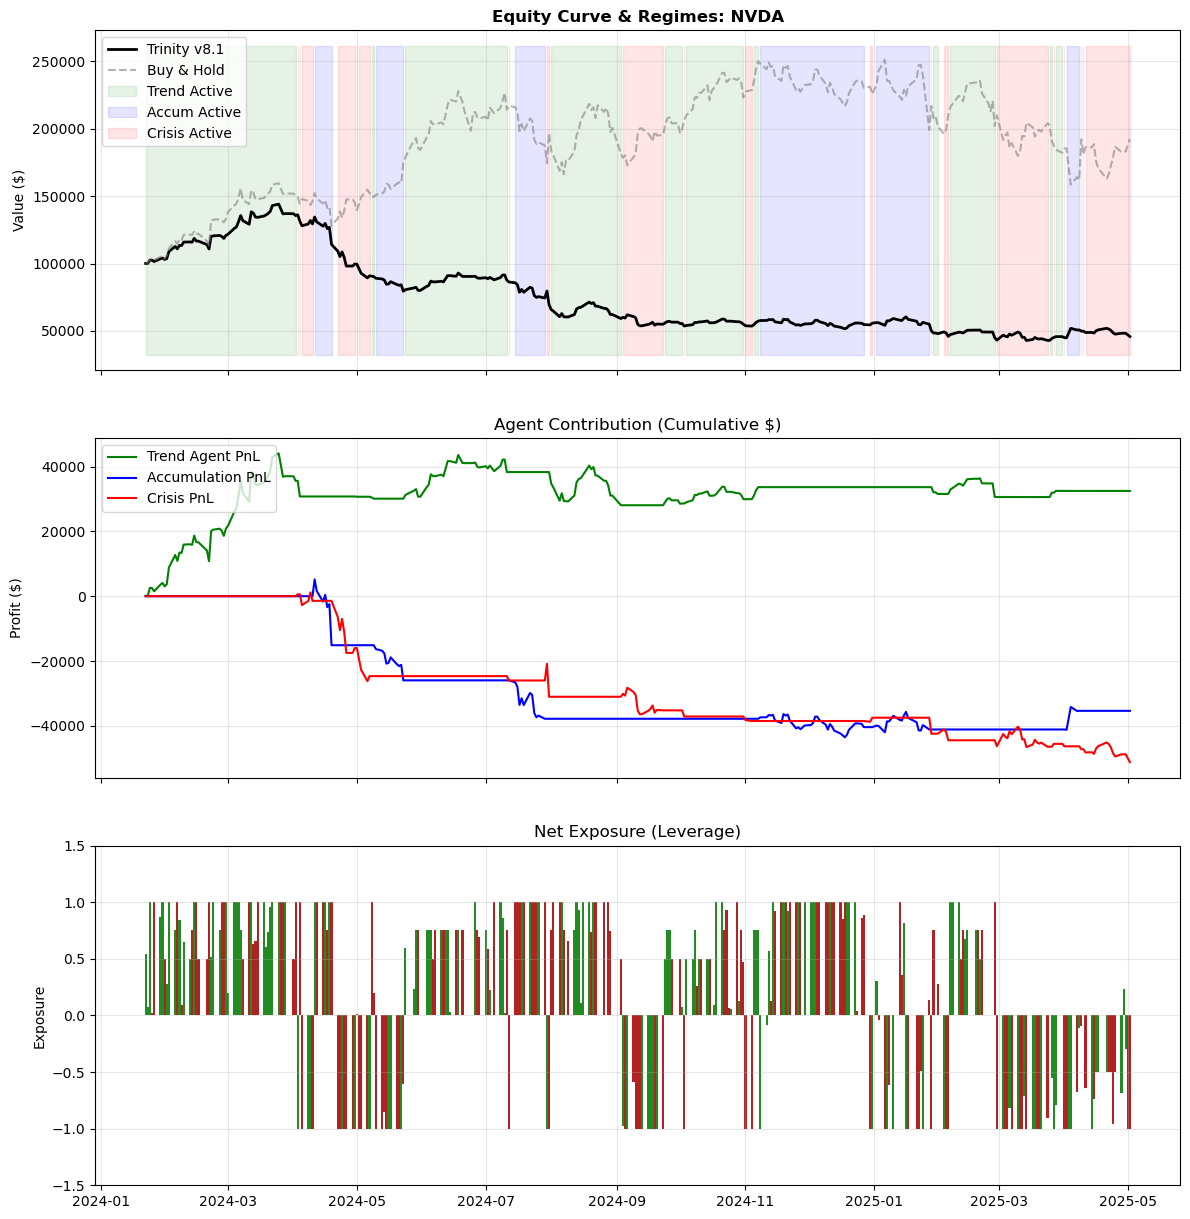

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings
import random
import torch

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v8.1) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31", 
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), 
        ("2020-01-01", "2020-05-01"), 
        ("2022-01-01", "2022-12-31"), 
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 80000, 
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002,
    "SEED": 142, 
    
    # Execution Logic
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False
}

# --- DATA PROCESSOR (v8.1) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        
        # --- BASE FEATURES ---
        df['returns'] = df[target].pct_change()
        df['log_ret'] = np.log(df[target] / df[target].shift(1))
        
        # --- TREND FEATURES ---
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # --- OSCILLATOR FEATURES ---
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        sma20 = df[target].rolling(20).mean()
        std20 = df[target].rolling(20).std()
        df['pct_b'] = (df[target] - (sma20 - 2*std20)) / (4*std20 + 1e-9)
        df['bb_width'] = (4 * std20) / (sma20 + 1e-9)
        
        df['dpo'] = df[target] - df[target].shift(int(20/2 + 1)).rolling(20).mean()
        
        # --- CRISIS FEATURES ---
        df['l_stat'] = self.calculate_lee_mykland(df[target], window=20)
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        dist_mean = df['dist_sma200'].rolling(252).mean()
        dist_std = df['dist_sma200'].rolling(252).std()
        df['z_score_sma'] = (df['dist_sma200'] - dist_mean) / (dist_std + 1e-9)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v8.1 - Fixed Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.data_vals = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        
        if self.mode == 'accumulation':
            self.obs_cols = ['rsi', 'pct_b', 'bb_width', 'dpo', 'realized_vol_20d']
        else:
            self.obs_cols = ['returns', 'dist_sma200', 'adx', 'l_stat', 'realized_vol_20d']
            
        self.obs_indices = [self.cols.index(c) for c in self.obs_cols]
        self.n_features = len(self.obs_cols)
        
        self.idx_ret = self.cols.index('returns')
        self.idx_sma = self.cols.index('dist_sma200')
        self.idx_rsi = self.cols.index('rsi')
        self.idx_adx = self.cols.index('adx')
        self.idx_pct_b = self.cols.index('pct_b')
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        return self._get_obs(), {}
    
    def _get_obs(self):
        obs_window = self.data_vals[self.current_step-self.window : self.current_step, self.obs_indices]
        return obs_window.flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data_vals[self.current_step, self.idx_ret] 
        rsi = self.data_vals[self.current_step, self.idx_rsi]
        sma_dist = self.data_vals[self.current_step, self.idx_sma]
        adx = self.data_vals[self.current_step, self.idx_adx]
        pct_b = self.data_vals[self.current_step, self.idx_pct_b]
        
        reward = 0
        
        if self.mode == 'trend':
            reward = act * ret * 100
            # Conviction Bonus
            if sma_dist > 0 and act > 0.1: reward += 0.05 * act 
            elif sma_dist < 0 and act < -0.1: reward += 0.05 * abs(act)
            
            # Whipsaw Protection
            if act > 0.5 and rsi > 85 and adx < 0.25: reward -= 0.5 
            if act < -0.5 and rsi < 15 and adx < 0.25: reward -= 0.5
                
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            
            # Pure Oscillator Logic
            if rsi < 30 or pct_b < 0: 
                reward += act * 1.0 
            if rsi > 70 or pct_b > 1: 
                reward -= act * 1.0 
            
            reward -= 0.01 * abs(act) 

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 5.0)
            
            if sma_dist < 0 and act > 0: reward -= 0.1 * act
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v8.1 Seeded & Fixes) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        self.agents = {}
        self.envs = {}
        
        # Set Global Seeds
        seed = config.get('SEED', 42)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    def train_specialists(self, verbose=True):
        if verbose: print(f"\n=== TRAINING SPECIALIST AGENTS (Win={self.config['WINDOW_SIZE']}) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
            env = VecNormalize(env, norm_obs=True, norm_reward=False)
            
            model = PPO("MlpPolicy", env, verbose=0, learning_rate=self.config['LEARNING_RATE'], batch_size=self.config['BATCH_SIZE'], seed=self.config['SEED'])
            model.learn(total_timesteps=self.config['TRAINING_STEPS'])
            
            self.agents[mode] = model
            self.envs[mode] = env
            
    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return -999.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return -999.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        cols = full_data.columns.tolist()
        idx_ret = cols.index('returns')
        idx_vol = cols.index('realized_vol_20d')
        idx_rsi = cols.index('rsi')
        
        idx_l_stat = cols.index('l_stat')
        idx_vol_pct = cols.index('vol_percentile')
        idx_adx = cols.index('adx')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_sma = cols.index('dist_sma200')
        idx_z_score = cols.index('z_score_sma')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        # Tracking for plotting
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            current_slice = data_vals[t-window : t]
            
            # Gating Inputs (Available at t-1)
            l_stat = data_vals[t-1, idx_l_stat]
            vol_pct = data_vals[t-1, idx_vol_pct]
            adx = data_vals[t-1, idx_adx]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            sma_dist = data_vals[t-1, idx_sma]
            z_score = data_vals[t-1, idx_z_score]
            prev_ret = data_vals[t-1, idx_ret] # For Override logic
            
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist > 0: regime, active_agent_name = "MANIA_MODE", "trend"
                else:
                    if z_score < -1.5: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                    else: regime, active_agent_name = "BEAR_VOLATILITY", "crisis"
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
            
            temp_env = self.envs[active_agent_name].venv.envs[0]
            indices = temp_env.obs_indices
            obs_raw = current_slice[:, indices].flatten()
            
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            action, _ = self.agents[active_agent_name].predict(obs_norm, deterministic=True)
            raw_action = action[0]
            
            regime_scaler = 1.0
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.3: regime_scaler = 1.5 
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 2.0 
            
            rsi = data_vals[t-1, idx_rsi]
            if regime == 'CRISIS_PANIC':
                if rsi < 30: raw_action = 0.0 
                elif raw_action > -0.5: raw_action = -0.5 
            
            # --- FIX: Removed Look-Ahead Bias ---
            # Used prev_ret (t-1) instead of mkt_ret (t)
            if regime == 'JUMP_BULL': raw_action = 1.0
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0 and prev_ret > -0.02: raw_action = 0.5 
            
            raw_vol = data_vals[t-1, idx_vol]
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            target_action = raw_action * regime_scaler * vol_scaler
            
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: target_action = np.clip(target_action, -10, 0)
                elif sma_dist > 0: target_action = np.clip(target_action, 0, 10)
            
            position_size = np.clip(target_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            # Execution at T using Close T return (Backtest assumption)
            mkt_ret = data_vals[t, idx_ret] 
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            
            # Stats (Daily Alpha Calculation)
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Raw Act': raw_action,
                'Trend_PnL': agent_pnls['trend'],
                'Accumulation_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret

    def plot_dashboard(self, res):
        fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)
        plt.subplots_adjust(hspace=0.2)
        
        # 1. Equity Curve
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v8.1', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        
        # Active Agent Highlights
        y_min, y_max = ax0.get_ylim()
        is_trend = res['Agent'] == 'trend'
        is_accum = res['Agent'] == 'accumulation'
        is_crisis = res['Agent'] == 'crisis'
        
        ax0.fill_between(res.index, y_min, y_max, where=is_trend, color='green', alpha=0.1, label='Trend Active')
        ax0.fill_between(res.index, y_min, y_max, where=is_accum, color='blue', alpha=0.1, label='Accum Active')
        ax0.fill_between(res.index, y_min, y_max, where=is_crisis, color='red', alpha=0.1, label='Crisis Active')
        
        ax0.set_title(f"Equity Curve & Regimes: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.set_ylabel("Value ($)")
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        # 2. Agent Cumulative PnL
        ax1 = axes[1]
        ax1.plot(res.index, res['Trend_PnL'], label='Trend Agent PnL', color='green')
        ax1.plot(res.index, res['Accumulation_PnL'], label='Accumulation PnL', color='blue')
        ax1.plot(res.index, res['Crisis_PnL'], label='Crisis PnL', color='red')
        ax1.set_title("Agent Contribution (Cumulative $)")
        ax1.set_ylabel("Profit ($)")
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc='upper left')

        # 3. Exposure
        ax2 = axes[2]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax2.bar(res.index, res['Scale Act'], color=colors, width=1.0)
        ax2.set_title("Net Exposure (Leverage)")
        ax2.set_ylabel("Exposure")
        ax2.set_ylim(-1.5, 1.5)
        ax2.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end 
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | {params}")
                
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V8.1 (FINAL) <<<")
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["NVDA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "NVDA"
    START = "2024-01-22"
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)

## v8.2 Seed


>>> STARTING HYPERPARAMETER OPTIMIZATION FOR NVDA <<<
Fetching data for: ['SHY', 'QQQ', '^VIX', 'NVDA'] (2015-01-01 to 2023-12-31)
Fetching data for: ['SHY', 'QQQ', '^VIX', 'NVDA'] (2018-10-01 to 2019-01-01)
Fetching data for: ['SHY', 'QQQ', '^VIX', 'NVDA'] (2020-01-01 to 2020-05-01)
Fetching data for: ['SHY', 'QQQ', '^VIX', 'NVDA'] (2022-01-01 to 2022-12-31)
Fetching data for: ['SHY', 'QQQ', '^VIX', 'NVDA'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 7.59% | {'ADX_THRESHOLD': 20, 'JUMP_THRESHOLD': 3.5}
Fetching data for: ['SHY', 'QQQ', '^VIX', 'NVDA'] (2023-01-02 to 2025-05-05)
  >>> NEW BEST: 10.05% | {'ADX_THRESHOLD': 25, 'JUMP_THRESHOLD': 3.5}

>>> INITIALIZING TRINITY V8.2 (FINAL) <<<

=== TRAINING SPECIALIST COMMITTEE (N=3) ===
Fetching data for: ['SHY', 'QQQ', '^VIX', 'NVDA'] (2015-01-01 to 2023-12-31)
  > Training TREND Agent 1...
  > Training TREND Agent 2...
  > Training TREND Agent 3...
  > Training ACCUMULATION Agent 1...
  > Training ACCUMULATION Agent 2...
  > Training AC

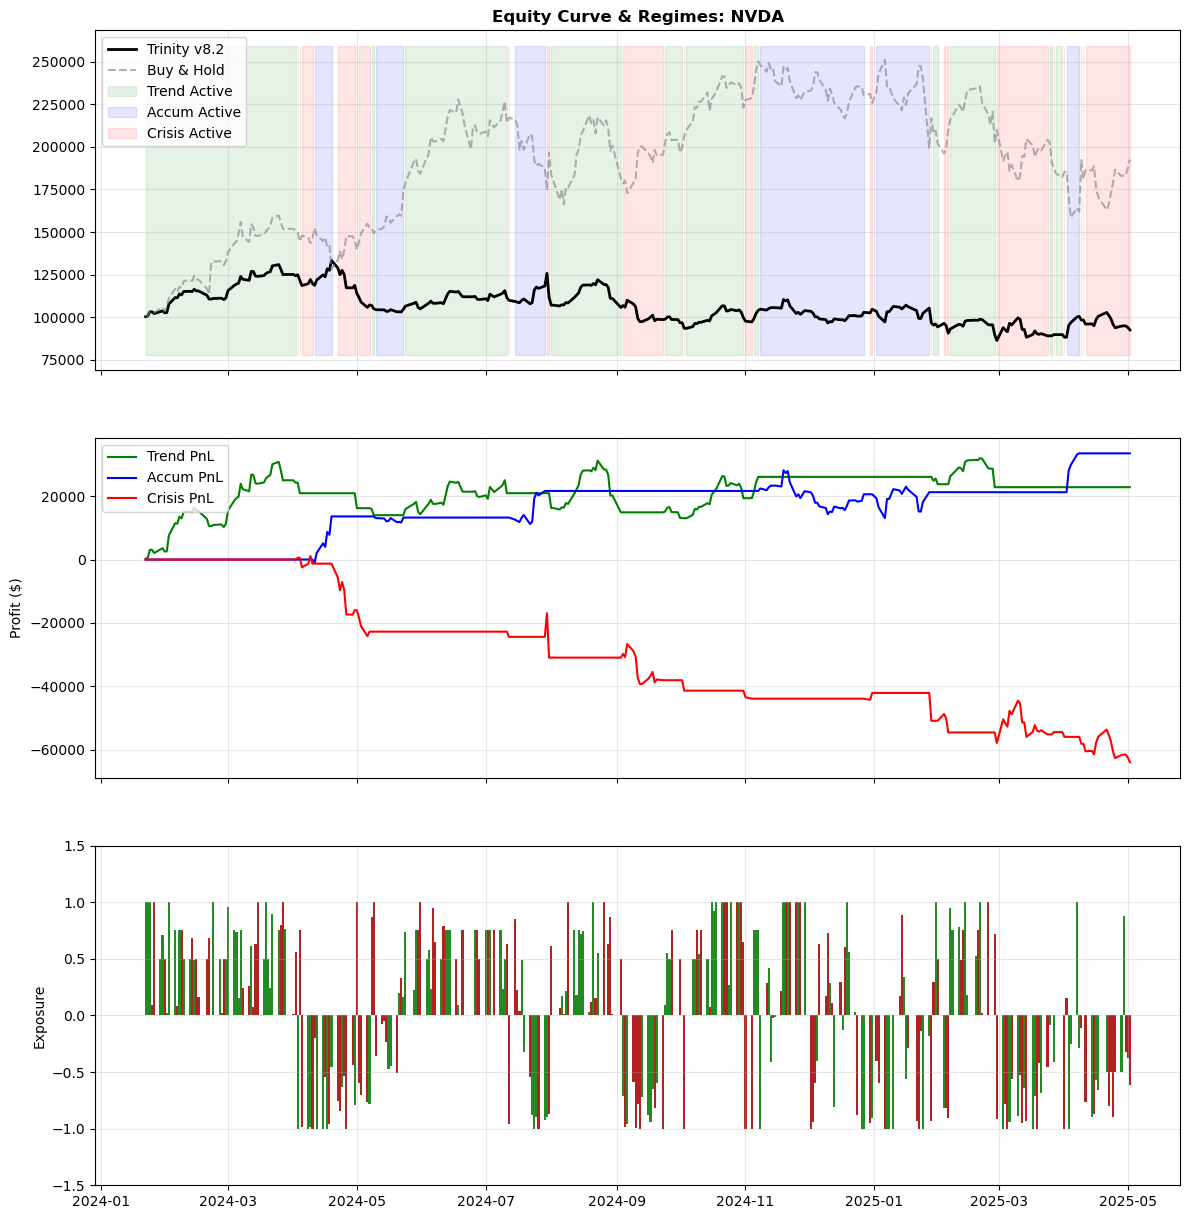

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt
import itertools
import warnings
import random
import torch

warnings.filterwarnings('ignore')

# --- CONFIGURATION (v8.2) ---
DEFAULT_CONFIG = {
    # Assets
    "TICKERS": ["SPY", "IWM", "^VIX", "SHY", "QQQ"], 
    "TARGET_ASSET": "SPY",
    
    # Dates
    "TRAIN_START": "2015-01-01",
    "TRAIN_END": "2023-12-31", 
    "TEST_START": "2024-01-02",
    "TEST_END": "2025-05-05",
    
    # Crisis Training Periods
    "CRISIS_PERIODS": [
        ("2018-10-01", "2019-01-01"), 
        ("2020-01-01", "2020-05-01"), 
        ("2022-01-01", "2022-12-31"), 
    ],
    
    # Hyperparameters
    "WINDOW_SIZE": 60, 
    "ADX_THRESHOLD": 25,
    "JUMP_THRESHOLD": 3.5, 
    "TARGET_VOL": 0.40,
    
    # RL Params
    "LEARNING_RATE": 3e-4,
    "BATCH_SIZE": 128,
    "TRAINING_STEPS": 60000, # Reduced slightly per model since we train N of them
    "N_VOTING_AGENTS": 3,     # v8.2: The Committee Size
    "ENTROPY_COEF": 0.01,     # v8.2: Force exploration
    "INITIAL_BALANCE": 100000,
    "FEES": 0.0005,
    "BORROW_RATE": 0.0002,
    "SEED": 42, 
    
    # Execution Logic
    "MAX_LEVERAGE": 1.0, 
    "USE_VOL_TARGETING": True,
    "SMA_TREND_FILTER": True,
    "LONG_ONLY": False
}

# --- DATA PROCESSOR (v8.2) ---
class DataProcessor:
    def __init__(self, tickers, config):
        self.tickers = list(set(tickers))
        self.config = config
        
    def download(self, start, end):
        try:
            if self.config['TARGET_ASSET'] not in self.tickers:
                self.tickers.append(self.config['TARGET_ASSET'])
                
            print(f"Fetching data for: {self.tickers} ({start} to {end})")
            data = yf.download(self.tickers, start=start, end=end, progress=False)
            
            if isinstance(data.columns, pd.MultiIndex):
                if 'Close' in data.columns.levels[0]: data = data.xs('Close', level=0, axis=1)
                elif 'Adj Close' in data.columns.levels[0]: data = data.xs('Adj Close', level=0, axis=1)
                elif 'Close' in data.columns.levels[1]: data = data.xs('Close', level=1, axis=1)
            
            if isinstance(data, pd.Series): 
                data = data.to_frame()
                if self.config['TARGET_ASSET'] not in data.columns:
                    data.columns = [self.config['TARGET_ASSET']]
            
            ohlc = yf.download(self.config['TARGET_ASSET'], start=start, end=end, progress=False)
            return data, ohlc
        except Exception as e:
            print(f"Data Download Error: {e}")
            return pd.DataFrame(), pd.DataFrame()

    def calculate_lee_mykland(self, df, window=20):
        log_ret = np.log(df / df.shift(1))
        abs_ret = np.abs(log_ret)
        bv_terms = abs_ret * abs_ret.shift(1)
        local_vol = np.sqrt((np.pi / 2) * bv_terms.rolling(window=window).mean())
        l_stat = log_ret / (local_vol + 1e-9)
        return l_stat.fillna(0)

    def add_features(self, df, ohlc):
        target = self.config['TARGET_ASSET']
        if df.empty or target not in df.columns: return pd.DataFrame()
        
        df = df.copy()
        
        # --- BASE FEATURES ---
        df['returns'] = df[target].pct_change()
        df['log_ret'] = np.log(df[target] / df[target].shift(1))
        
        # --- TREND FEATURES ---
        high = ohlc['High']
        low = ohlc['Low']
        close = ohlc['Close']
        df['tr'] = np.maximum(high - low, np.maximum(abs(high - close.shift(1)), abs(low - close.shift(1))))
        window = 14
        df['tr_s'] = df['tr'].rolling(window).mean()
        df['dm_plus'] = np.where((high - high.shift(1)) > (low.shift(1) - low), np.maximum(high - high.shift(1), 0), 0)
        df['dm_minus'] = np.where((low.shift(1) - low) > (high - high.shift(1)), np.maximum(low.shift(1) - low, 0), 0)
        df['dp_s'] = df['dm_plus'].rolling(window).mean()
        df['dm_s'] = df['dm_minus'].rolling(window).mean()
        df['di_plus'] = 100 * (df['dp_s'] / (df['tr_s'] + 1e-9))
        df['di_minus'] = 100 * (df['dm_s'] / (df['tr_s'] + 1e-9))
        df['dx'] = 100 * abs(df['di_plus'] - df['di_minus']) / (df['di_plus'] + df['di_minus'] + 1e-9)
        df['adx'] = df['dx'].rolling(window).mean()
        
        sma200 = df[target].rolling(200).mean()
        df['dist_sma200'] = (df[target] - sma200) / sma200
        
        # --- OSCILLATOR FEATURES ---
        delta = df[target].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / (loss + 1e-9)
        df['rsi'] = 100 - (100 / (1 + rs))
        
        sma20 = df[target].rolling(20).mean()
        std20 = df[target].rolling(20).std()
        df['pct_b'] = (df[target] - (sma20 - 2*std20)) / (4*std20 + 1e-9)
        df['bb_width'] = (4 * std20) / (sma20 + 1e-9)
        
        df['dpo'] = df[target] - df[target].shift(int(20/2 + 1)).rolling(20).mean()
        
        # --- CRISIS FEATURES ---
        df['l_stat'] = self.calculate_lee_mykland(df[target], window=20)
        df['realized_vol_20d'] = df['returns'].rolling(20).std() * np.sqrt(252)
        df['vol_percentile'] = df['realized_vol_20d'].rolling(252).rank(pct=True)
        
        dist_mean = df['dist_sma200'].rolling(252).mean()
        dist_std = df['dist_sma200'].rolling(252).std()
        df['z_score_sma'] = (df['dist_sma200'] - dist_mean) / (dist_std + 1e-9)
        
        return df.fillna(0)

    def get_data(self, start, end):
        df, ohlc = self.download(start, end)
        return self.add_features(df, ohlc)

    def get_crisis_data(self):
        dfs = []
        for s, e in self.config['CRISIS_PERIODS']:
            d, o = self.download(s, e)
            dfs.append(self.add_features(d, o))
        return pd.concat(dfs).reset_index(drop=True).fillna(0)

# --- ENVIRONMENT (v8.2 - Simplified Robust Rewards) ---
class TradingEnv(gym.Env):
    def __init__(self, df, config, mode='trend'):
        super(TradingEnv, self).__init__()
        self.df = df
        self.config = config
        self.mode = mode 
        self.window = config['WINDOW_SIZE']
        self.current_step = self.window
        
        self.data_vals = df.values.astype(np.float32)
        self.cols = df.columns.tolist()
        
        if self.mode == 'accumulation':
            self.obs_cols = ['rsi', 'pct_b', 'bb_width', 'dpo', 'realized_vol_20d']
        else:
            # Trend/Crisis see Macro structure
            self.obs_cols = ['returns', 'dist_sma200', 'adx', 'l_stat', 'realized_vol_20d']
            
        self.obs_indices = [self.cols.index(c) for c in self.obs_cols]
        self.n_features = len(self.obs_cols)
        
        self.idx_ret = self.cols.index('returns')
        self.idx_sma = self.cols.index('dist_sma200')
        self.idx_rsi = self.cols.index('rsi')
        self.idx_adx = self.cols.index('adx')
        self.idx_pct_b = self.cols.index('pct_b')
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.window * self.n_features,), dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        self.current_step = self.window
        if len(self.df) > 1000:
             self.current_step = np.random.randint(self.window, len(self.df) - 500)
        return self._get_obs(), {}
    
    def _get_obs(self):
        obs_window = self.data_vals[self.current_step-self.window : self.current_step, self.obs_indices]
        return obs_window.flatten()

    def step(self, action):
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}
            
        act = np.clip(action[0], -1, 1)
        ret = self.data_vals[self.current_step, self.idx_ret] 
        rsi = self.data_vals[self.current_step, self.idx_rsi]
        sma_dist = self.data_vals[self.current_step, self.idx_sma]
        adx = self.data_vals[self.current_step, self.idx_adx]
        pct_b = self.data_vals[self.current_step, self.idx_pct_b]
        
        reward = 0
        
        if self.mode == 'trend':
            # v8.2: Removed Whipsaw Protection (It confused the agent).
            # Pure Trend Logic: Be Long if Above SMA, Short if Below.
            reward = act * ret * 100
            
            # DIRECTIONAL ALIGNMENT PENALTY
            # If Bull Trend (SMA Dist > 0) AND Shorting (act < 0): Penalize
            # This prevents the "Policy Collapse" into Permabear
            if sma_dist > 0 and act < -0.1: 
                reward -= 0.2 * abs(act) # Punishment for fighting trend
            elif sma_dist < 0 and act > 0.1:
                reward -= 0.2 * abs(act)
                
        elif self.mode == 'accumulation': 
            reward = act * ret * 100
            # Oscillator Logic
            if rsi < 30 or pct_b < 0: reward += act * 1.0 
            if rsi > 70 or pct_b > 1: reward -= act * 1.0 
            reward -= 0.01 * abs(act) 

        elif self.mode == 'crisis':
            reward = (act * ret * 100)
            if ret < -0.01:
                if act < -0.1: reward *= 3.0 
                elif act > 0.1: reward -= (act * 5.0)
            
            # Penalize Longs in Bear Market
            if sma_dist < 0 and act > 0: reward -= 0.1 * act
            
        self.current_step += 1
        return self._get_obs(), reward, False, False, {}

# --- MANAGER (v8.2 Voting Ensemble) ---
class EnsembleManager:
    def __init__(self, config):
        self.config = config
        self.dp = DataProcessor(config['TICKERS'], config)
        # Store lists of agents instead of single agents
        self.agents = {'trend': [], 'accumulation': [], 'crisis': []}
        self.envs = {} 
        
        # Set Global Seeds (Base)
        seed = config.get('SEED', 42)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    def train_specialists(self, verbose=True):
        if verbose: print(f"\n=== TRAINING SPECIALIST COMMITTEE (N={self.config['N_VOTING_AGENTS']}) ===")
        trend_data = self.dp.get_data(self.config['TRAIN_START'], self.config['TRAIN_END'])
        
        modes = ['trend', 'accumulation', 'crisis']
        for mode in modes:
            data_source = self.dp.get_crisis_data() if mode == 'crisis' else trend_data
            
            # Train N agents per mode
            for i in range(self.config['N_VOTING_AGENTS']):
                if verbose: print(f"  > Training {mode.upper()} Agent {i+1}...")
                
                # Each agent gets a slightly different seed to diversify
                current_seed = self.config['SEED'] + i 
                
                env = DummyVecEnv([lambda: TradingEnv(data_source, self.config, mode=mode)])
                env = VecNormalize(env, norm_obs=True, norm_reward=False)
                
                model = PPO(
                    "MlpPolicy", 
                    env, 
                    verbose=0, 
                    learning_rate=self.config['LEARNING_RATE'], 
                    batch_size=self.config['BATCH_SIZE'], 
                    seed=current_seed,
                    ent_coef=self.config['ENTROPY_COEF']
                )
                model.learn(total_timesteps=self.config['TRAINING_STEPS'])
                
                self.agents[mode].append(model)
                # Keep one env wrapper for normalization stats (shared approx)
                if i == 0: self.envs[mode] = env
            
    def run_backtest(self, start_date=None, end_date=None, plot_results=True):
        s_date = start_date if start_date else self.config['TEST_START']
        e_date = end_date if end_date else self.config['TEST_END']
        
        warmup_dt = pd.Timestamp(s_date) - pd.Timedelta(days=365)
        full_data = self.dp.get_data(warmup_dt.strftime('%Y-%m-%d'), e_date)
        if full_data.empty: return -999.0
        
        test_indices = np.where((full_data.index >= s_date) & (full_data.index <= e_date))[0]
        if len(test_indices) == 0: return -999.0

        portfolio = self.config['INITIAL_BALANCE']
        benchmark_equity = self.config['INITIAL_BALANCE'] 
        holdings = 0
        history = []
        
        cols = full_data.columns.tolist()
        idx_ret = cols.index('returns')
        idx_vol = cols.index('realized_vol_20d')
        idx_rsi = cols.index('rsi')
        
        idx_l_stat = cols.index('l_stat')
        idx_vol_pct = cols.index('vol_percentile')
        idx_adx = cols.index('adx')
        idx_di_plus = cols.index('di_plus')
        idx_di_minus = cols.index('di_minus')
        idx_sma = cols.index('dist_sma200')
        idx_z_score = cols.index('z_score_sma')
        
        data_vals = full_data.values
        dates = full_data.index
        window = self.config['WINDOW_SIZE']
        
        agent_pnls = {k: 0.0 for k in ['trend', 'accumulation', 'crisis']}
        
        if plot_results:
            print(f"{'Date':<12} | {'Regime':<12} | {'Active Agent':<12} | {'Raw Act':<8} | {'Scale Act':<10} | {'Portfolio':<10} | {'Bench':<10} | {'Daily Alpha':<11}")
            print("-" * 120)
        
        for t in test_indices:
            current_slice = data_vals[t-window : t]
            
            l_stat = data_vals[t-1, idx_l_stat]
            vol_pct = data_vals[t-1, idx_vol_pct]
            adx = data_vals[t-1, idx_adx]
            di_plus = data_vals[t-1, idx_di_plus]
            di_minus = data_vals[t-1, idx_di_minus]
            sma_dist = data_vals[t-1, idx_sma]
            z_score = data_vals[t-1, idx_z_score]
            prev_ret = data_vals[t-1, idx_ret]
            
            is_bullish_jump = (l_stat > self.config['JUMP_THRESHOLD'])
            is_bearish_jump = (l_stat < -self.config['JUMP_THRESHOLD'])
            is_extreme_vol = (vol_pct > 0.90)
            is_bull_trend = (adx > self.config['ADX_THRESHOLD']) and (di_plus > di_minus)
            is_bear_trend = (adx > self.config['ADX_THRESHOLD']) and (di_minus > di_plus)
            
            if is_bearish_jump: regime, active_agent_name = "JUMP_BEAR", "crisis"
            elif is_bullish_jump: regime, active_agent_name = "JUMP_BULL", "trend"
            elif is_extreme_vol:
                if sma_dist > 0: regime, active_agent_name = "MANIA_MODE", "trend"
                else:
                    if z_score < -1.5: regime, active_agent_name = "CRISIS_PANIC", "crisis"
                    else: regime, active_agent_name = "BEAR_VOLATILITY", "crisis"
            elif is_bear_trend: regime, active_agent_name = "BEAR_TREND", "crisis"
            elif is_bull_trend: regime, active_agent_name = "TREND", "trend"
            else: regime, active_agent_name = "ACCUMULATION", "accumulation"
            
            # --- VOTING ENSEMBLE PREDICTION ---
            temp_env = self.envs[active_agent_name].venv.envs[0]
            indices = temp_env.obs_indices
            obs_raw = current_slice[:, indices].flatten()
            norm_env = self.envs[active_agent_name]
            obs_norm = norm_env.normalize_obs(obs_raw)
            
            # Poll all agents in the committee
            votes = []
            for agent in self.agents[active_agent_name]:
                action, _ = agent.predict(obs_norm, deterministic=True)
                votes.append(action[0])
            
            # Average the votes (Consensus)
            raw_action = np.mean(votes)
            
            regime_scaler = 1.0
            if regime in ['TREND', 'MANIA_MODE', 'JUMP_BULL']:
                if abs(raw_action) > 0.3: regime_scaler = 1.5 
            elif regime in ['ACCUMULATION', 'CHOP']:
                regime_scaler = 2.0 
            
            rsi = data_vals[t-1, idx_rsi]
            if regime == 'CRISIS_PANIC':
                if rsi < 30: raw_action = 0.0 
                elif raw_action > -0.5: raw_action = -0.5 
            
            if regime == 'JUMP_BULL': raw_action = 1.0
            if active_agent_name == 'trend':
                if sma_dist > 0 and raw_action < 0 and prev_ret > -0.02: raw_action = 0.5 
            
            raw_vol = data_vals[t-1, idx_vol]
            vol_scaler = 1.0
            if self.config['USE_VOL_TARGETING'] and raw_vol > 0.01:
                vol_scaler = self.config['TARGET_VOL'] / raw_vol
            vol_scaler = np.clip(vol_scaler, 0.0, 1.5)
            
            target_action = raw_action * regime_scaler * vol_scaler
            
            if self.config['SMA_TREND_FILTER'] and active_agent_name == 'trend':
                if sma_dist < 0: target_action = np.clip(target_action, -10, 0)
                elif sma_dist > 0: target_action = np.clip(target_action, 0, 10)
            
            position_size = np.clip(target_action, -self.config['MAX_LEVERAGE'], self.config['MAX_LEVERAGE'])
            
            mkt_ret = data_vals[t, idx_ret] 
            cost = abs(position_size - holdings) * self.config['FEES']
            lev_cost = max(0, abs(position_size)-1) * self.config['BORROW_RATE']
            step_pnl_pct = (position_size * mkt_ret) - cost - lev_cost
            step_pnl_dollars = portfolio * step_pnl_pct
            
            portfolio *= (1 + step_pnl_pct)
            benchmark_equity *= (1 + mkt_ret)
            holdings = position_size
            
            agent_pnls[active_agent_name] += step_pnl_dollars
            alpha_bps = (step_pnl_pct - mkt_ret) * 10000
            
            if plot_results and t % 20 == 0: 
                print(f"{str(dates[t].date()):<12} | {regime:<12} | {active_agent_name:<12} | {raw_action:<8.2f} | {position_size:<10.2f} | {portfolio:<10.0f} | {benchmark_equity:<10.0f} | {alpha_bps:>8.0f} bps")
                
            history.append({
                'Date': dates[t],
                'Portfolio': portfolio,
                'Regime': regime,
                'Agent': active_agent_name,
                'Return': step_pnl_pct,
                'Benchmark': mkt_ret,
                'Scale Act': position_size,
                'Raw Act': raw_action,
                'Trend_PnL': agent_pnls['trend'],
                'Accumulation_PnL': agent_pnls['accumulation'],
                'Crisis_PnL': agent_pnls['crisis']
            })
            
        res = pd.DataFrame(history).set_index('Date')
        total_ret = (portfolio / self.config['INITIAL_BALANCE']) - 1
        
        if plot_results:
            bench_ret = (benchmark_equity / self.config['INITIAL_BALANCE']) - 1
            print(f"\n=== FINAL REPORT: {total_ret:.2%} (Bench: {bench_ret:.2%}) ===")
            self.plot_dashboard(res)
            
        return total_ret

    def plot_dashboard(self, res):
        fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)
        plt.subplots_adjust(hspace=0.2)
        
        res['Bench_Equity'] = (1 + res['Benchmark']).cumprod() * self.config['INITIAL_BALANCE']
        ax0 = axes[0]
        ax0.plot(res.index, res['Portfolio'], label='Trinity v8.2', color='black', linewidth=2)
        ax0.plot(res.index, res['Bench_Equity'], label='Buy & Hold', color='gray', linestyle='--', alpha=0.6)
        
        y_min, y_max = ax0.get_ylim()
        is_trend = res['Agent'] == 'trend'
        is_accum = res['Agent'] == 'accumulation'
        is_crisis = res['Agent'] == 'crisis'
        
        ax0.fill_between(res.index, y_min, y_max, where=is_trend, color='green', alpha=0.1, label='Trend Active')
        ax0.fill_between(res.index, y_min, y_max, where=is_accum, color='blue', alpha=0.1, label='Accum Active')
        ax0.fill_between(res.index, y_min, y_max, where=is_crisis, color='red', alpha=0.1, label='Crisis Active')
        
        ax0.set_title(f"Equity Curve & Regimes: {self.config['TARGET_ASSET']}", fontweight='bold')
        ax0.grid(True, alpha=0.3)
        ax0.legend(loc='upper left')

        ax1 = axes[1]
        ax1.plot(res.index, res['Trend_PnL'], label='Trend PnL', color='green')
        ax1.plot(res.index, res['Accumulation_PnL'], label='Accum PnL', color='blue')
        ax1.plot(res.index, res['Crisis_PnL'], label='Crisis PnL', color='red')
        ax1.set_ylabel("Profit ($)")
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc='upper left')

        ax2 = axes[2]
        colors = ['forestgreen' if r > 0 else 'firebrick' for r in res['Return']]
        ax2.bar(res.index, res['Scale Act'], color=colors, width=1.0)
        ax2.set_ylabel("Exposure")
        ax2.set_ylim(-1.5, 1.5)
        ax2.grid(True, alpha=0.3)
        
        plt.show()

# --- HYPERPARAMETER OPTIMIZER ---
class HyperparameterOptimizer:
    def __init__(self, tickers, target):
        self.tickers = tickers
        self.target = target
        
    def optimize(self, train_start, train_end):
        print(f"\n>>> STARTING HYPERPARAMETER OPTIMIZATION FOR {self.target} <<<")
        training_grid = { "WINDOW_SIZE": [60] }
        inference_grid = { "ADX_THRESHOLD": [20, 25], "JUMP_THRESHOLD": [3.5] }
        
        best_ret = -np.inf
        best_config = {} 
        
        for window in training_grid["WINDOW_SIZE"]:
            base_config = DEFAULT_CONFIG.copy()
            base_config['WINDOW_SIZE'] = window
            base_config['TICKERS'] = self.tickers
            base_config['TARGET_ASSET'] = self.target
            base_config['TRAIN_START'] = train_start
            base_config['TRAIN_END'] = train_end 
            base_config['TRAINING_STEPS'] = 10000 
            
            mgr = EnsembleManager(base_config.copy())
            mgr.train_specialists(verbose=False)
            
            keys, values = zip(*inference_grid.items())
            combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
            
            for i, params in enumerate(combinations):
                mgr.config.update(params)
                mgr.config['TEST_START'] = "2024-01-02"
                mgr.config['TEST_END'] = "2025-05-05"
                
                ret = mgr.run_backtest(plot_results=False)
                if ret > best_ret:
                    best_ret = ret
                    best_config = { "WINDOW_SIZE": window, **params }
                    print(f"  >>> NEW BEST: {ret:.2%} | {params}")
                
        return best_config

def run_system(tickers, target, start, end, optimize=True):
    config = DEFAULT_CONFIG.copy()
    config['TICKERS'] = tickers
    config['TARGET_ASSET'] = target
    config['TEST_START'] = start
    config['TEST_END'] = end
    
    if target != "SPY":
        config['LONG_ONLY'] = True
        config['MAX_LEVERAGE'] = 1.0
        config['TRAINING_STEPS'] = 50000 
        config['USE_VOL_TARGETING'] = False 

    if optimize:
        opt = HyperparameterOptimizer(tickers, target)
        best_params = opt.optimize("2015-01-01", "2023-12-31") 
        config.update(best_params)
    
    print("\n>>> INITIALIZING TRINITY V8.2 (FINAL) <<<")
    mgr = EnsembleManager(config)
    mgr.train_specialists()
    mgr.run_backtest()

if __name__ == "__main__":
    MY_TICKERS = ["NVDA", "^VIX", "SHY", "QQQ"]
    MY_TARGET = "NVDA"
    START = "2024-01-22"
    END = "2025-05-05"

    run_system(MY_TICKERS, MY_TARGET, START, END, optimize=True)